# Hybrid Transformer Architecture for Context-Aware Phishing Email Classification
## A Multi-Source, Multilingual, Explainable Detection Framework

**MSc Thesis — Phase 1**

---

# PHASE 1 — Exploratory Data Analysis & Pre-processing

**Corpus:** MEPC — *Multi-source Email Phishing Corpus* (`merged_email_corpus.csv`)
**Composition:** 101,229 raw emails · 4 source corpora (TREC 5/6/7, phishing_pot) · 15+ languages · PII-pseudonymised

---

### What this notebook does

| Step | Section | Purpose |
|:--|:--|:--|
| **A** | Environment & ingestion | Reproducible config, palette, schema, missing-data structure |
| **B** | Quality, cleaning, deduplication | Audit, normalisation, campaign-aware deduplication |
| **C** | Corpus characterisation | Class balance, **source leakage**, **domain leakage**, language, temporal drift |
| **D** | Text preparation & lexical analysis | Model input field, log-odds tokens, social-engineering cues |
| **E** | Structural feature engineering | 13 core + 8 extended interpretable features, URL forensics |
| **F** | Statistical validation | Mann-Whitney effect sizes, mutual information, outliers, PCA |
| **G** | Experimental design | PSI distribution shift, **Split A** and **Split B**, integrity checks |
| **H** | Leakage stress tests & baselines | Metadata probes, three reference models, the generalisation gap |
| **I** | Persistence & reporting | Scaling, artefacts, 10 thesis tables, summary |

**45 numbered cells · 24 figures · 10 exported tables**

---

### Why two splits

The single most important methodological decision in this notebook. The corpus is a
*merge* of four independently collected sources, and one of them (`phishing_pot`)
contains phishing only. Any model that can see the source — directly or through
proxy signals such as the sender domain — can score near-perfectly by memorising
provenance rather than learning phishing.

- **Split A (in-distribution)** — stratified 72/8/20. Comparable to published work.
- **Split B (cross-source)** — train on TREC, test on the fully held-out `phishing_pot`
  plus disjoint TREC ham. This measures whether the detector *transfers*.

The gap between A and B is the empirical contribution of the thesis.

---

> **Prerequisite:** upload `merged_email_corpus.csv` to `My Drive/Thesis/`
>
> **Runtime:** 25–35 minutes on a standard CPU instance. No GPU is required for Phase 1 —
> select a **High-RAM** runtime if one is offered, since Part H builds sparse bigram
> matrices over ~80,000 documents. If memory becomes a constraint, lower
> `TFIDF_MAX_FEATURES` in Cell 2; every other cell runs comfortably under 4 GB.

---

# PART A — ENVIRONMENT AND DATA INGESTION

Reproducible configuration, corpus loading, and schema documentation.

---

---
## CELL 1 — Install and Import Libraries

In [1]:
# Phase 1 needs no GPU and no transformers — keep the environment light.
!pip install pyarrow --quiet

import os
import re
import gc
import json
import time
import hashlib
import warnings
import unicodedata
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

print('Libraries imported')
print(f'pandas {pd.__version__} | numpy {np.__version__} | matplotlib {mpl.__version__}')

Libraries imported
pandas 2.2.3 | numpy 2.1.3 | matplotlib 3.10.0


---
## CELL 2 — Configuration, Reproducibility and Visual Identity

A single amber-on-graphite palette is used across every figure in the thesis.
Amber is the conventional alert colour of security operations tooling, and using
one hue for the primary series (rather than a different colour per chart) keeps
the figure set visually coherent. Colour is reserved for *meaning*:

| Role | Hex | Used for |
|:--|:--|:--|
| `AMBER` | `#D99A0B` | Primary series, single-series charts |
| `AMBER_D` | `#8C6206` | Second series, emphasis |
| `GRAPHITE` | `#26282D` | Text, axes, structural elements |
| `PHISH` | `#A62B1F` | Phishing / positive class (label = 1) |
| `LEGIT` | `#4F6B3A` | Legitimate / negative class (label = 0) |
| `SLATE` | `#6E7178` | Neutral, de-emphasised, reference lines |

Red and olive appear **only** where they carry class semantics, so a reader can
learn the encoding once and apply it to every figure in the dissertation.

In [2]:
# ══ REPRODUCIBILITY ══════════════════════════════════════════════════════
SEED = 42
np.random.seed(SEED)

# ══ THESIS PALETTE ═══════════════════════════════════════════════════════
AMBER    = '#D99A0B'   # primary
AMBER_D  = '#8C6206'   # primary, darker
AMBER_L  = '#F0C862'   # primary, lighter (fills)
GRAPHITE = '#26282D'   # ink
SLATE    = '#6E7178'   # neutral / reference
PHISH    = '#A62B1F'   # class 1 — phishing
LEGIT    = '#4F6B3A'   # class 0 — legitimate
PAPER    = '#FBFAF7'   # figure background

CLASS_COLORS  = {0: LEGIT, 1: PHISH}
CLASS_LABELS  = {0: 'Legitimate', 1: 'Phishing'}
SEQ_CMAP      = mpl.colors.LinearSegmentedColormap.from_list(
    'mepc_seq', ['#FBFAF7', AMBER_L, AMBER, AMBER_D, GRAPHITE])
DIV_CMAP      = mpl.colors.LinearSegmentedColormap.from_list(
    'mepc_div', [LEGIT, '#EFEDE6', AMBER, PHISH])

def apply_thesis_style():
    """Single source of truth for figure styling across Phase 1 and Phase 2."""
    mpl.rcParams.update({
        'figure.facecolor':   PAPER,
        'axes.facecolor':     PAPER,
        'savefig.facecolor':  PAPER,
        'axes.edgecolor':     GRAPHITE,
        'axes.labelcolor':    GRAPHITE,
        'axes.linewidth':     0.9,
        'axes.grid':          True,
        'axes.axisbelow':     True,
        'grid.color':         '#D8D5CC',
        'grid.linewidth':     0.6,
        'grid.alpha':         0.9,
        'text.color':         GRAPHITE,
        'xtick.color':        GRAPHITE,
        'ytick.color':        GRAPHITE,
        'font.family':        'DejaVu Sans',
        'font.size':          10,
        'axes.titlesize':     12,
        'axes.titleweight':   'bold',
        'axes.labelsize':     10.5,
        'legend.frameon':     False,
        'figure.dpi':         110,
        'savefig.dpi':        200,
        'savefig.bbox':       'tight',
    })
    for spine in ('top', 'right'):
        mpl.rcParams[f'axes.spines.{spine}'] = False

apply_thesis_style()

# ══ FEATURE CONTRACT ═════════════════════════════════════════════════════
# The 13 structural features, in a fixed order. Phase 2 depends on this order,
# so it is declared once here and saved to disk alongside the arrays.
STRUCT_FEATURES = [
    'url_count',            # 1  number of URLs in the email
    'url_length_max',       # 2  longest URL (chars)
    'url_length_avg',       # 3  mean URL length (chars)
    'url_subdom_max',       # 4  deepest subdomain nesting
    'url_subdom_avg',       # 5  mean subdomain nesting
    'uppercase_ratio',      # 6  share of uppercase letters
    'punct_density',        # 7  emphasis punctuation per character
    'digit_count',          # 8  digits in body
    'currency_flag',        # 9  currency symbol present
    'html_flag',            # 10 HTML part declared
    'body_length',          # 11 body characters
    'subject_length',       # 12 subject characters
    'attachment_count',     # 13 declared attachments
]
N_STRUCT = len(STRUCT_FEATURES)

SPLIT_RATIOS = {'train': 0.72, 'val': 0.08, 'test': 0.20}

# ══ SPLIT DESIGN CONSTANTS ═══════════════════════════════════════════════
# Declared here rather than at the split cells, because the distribution-shift
# analysis that motivates the cross-source design needs them earlier.
TREC_SOURCES           = ['trec5', 'trec6', 'trec7']
HELD_OUT_SRC           = 'phishing_pot'
ROTATING_FOLDS = {'C1': 'trec5', 'C2': 'trec6', 'C3': 'trec7'}
FOLD_VAL_FRACTION = 0.10
ALL_DESIGNS = ['A', 'B'] + list(ROTATING_FOLDS)
TARGET_TEST_PHISH_RATE = 0.40

# ══ MEMORY BUDGET ════════════════════════════════════════════════════════
# The classical baselines in Part H build sparse bigram matrices over ~80,000
# documents. On a standard Colab instance (12.7 GB) the settings below leave
# comfortable headroom; on a smaller instance, reduce TFIDF_MAX_FEATURES first.
TFIDF_MAX_FEATURES = 60_000
TFIDF_NGRAM        = (1, 2)
TFIDF_DTYPE        = np.float32

print(f'Seed: {SEED}')
print(f'Structural features declared: {N_STRUCT}')
print(f'Split ratios: {SPLIT_RATIOS}')
print(f'Held-out source for cross-source evaluation: {HELD_OUT_SRC}')
print(f'TF-IDF budget: {TFIDF_MAX_FEATURES:,} features, n-grams {TFIDF_NGRAM}')

Seed: 42
Structural features declared: 13
Split ratios: {'train': 0.72, 'val': 0.08, 'test': 0.2}
Held-out source for cross-source evaluation: phishing_pot
TF-IDF budget: 60,000 features, n-grams (1, 2)


---
## CELL 3 — Mount Google Drive and Resolve Paths

> **Instructions:** place `merged_email_corpus.csv` in `My Drive/Thesis/`.
> The three output folders are created automatically.

In [3]:
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

# ---- EDIT ONLY THIS LINE IF YOUR FOLDER NAME DIFFERS --------------------
ROOT = '/content/drive/MyDrive/Thesis/'
# ------------------------------------------------------------------------

DATA_PATH = ROOT + 'Multi-source Email Phishing Corpus.csv'
PREP_DIR  = ROOT + 'preprocessed/'
MODEL_DIR = ROOT + 'models/'
FIG_DIR   = ROOT + 'figures/'

for d in (PREP_DIR, MODEL_DIR, FIG_DIR):
    os.makedirs(d, exist_ok=True)

assert os.path.exists(DATA_PATH), (
    f'Corpus not found at {DATA_PATH}\n'
    f'Contents of {ROOT}: {os.listdir(ROOT) if os.path.exists(ROOT) else "folder missing"}'
)

size_mb = os.path.getsize(DATA_PATH) / 1024**2
print(f'Corpus found  : {DATA_PATH}  ({size_mb:.1f} MB)')
print(f'Preprocessed  : {PREP_DIR}')
print(f'Models        : {MODEL_DIR}')
print(f'Figures       : {FIG_DIR}')


def savefig(fig, name):
    """Save a figure to Drive and echo the path, so every figure is reproducible."""
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path)
    print(f'  figure saved: {name}')
    return path

Mounted at /content/drive
Corpus found  : /content/drive/MyDrive/Thesis/Multi-source Email Phishing Corpus.csv  (172.4 MB)
Preprocessed  : /content/drive/MyDrive/Thesis/preprocessed/
Models        : /content/drive/MyDrive/Thesis/models/
Figures       : /content/drive/MyDrive/Thesis/figures/


---
## CELL 4 — Load the Corpus

Two non-obvious loader settings, both necessary:

- **`encoding_errors='replace'`** — the merged corpus contains a small number of
  non-UTF-8 bytes inherited from the original TREC mailboxes (the first occurs at
  byte offset ≈ 74,198). A plain `read_csv` raises `UnicodeDecodeError` and aborts.
  Replacing the offending bytes loses a handful of characters and preserves ~101k emails.
- **`low_memory=False`** — forces a single-pass dtype inference. Chunked inference
  produces mixed-dtype columns on this file because the malformed rows appear late.

Loading takes roughly 60–90 seconds for the 172 MB file.

In [4]:
t0 = time.time()
print('Loading MEPC corpus — this takes 60-90 seconds for 172 MB...')

df_raw = pd.read_csv(
    DATA_PATH,
    encoding='utf-8',
    encoding_errors='replace',   # tolerate legacy non-UTF-8 bytes from TREC mailboxes
    low_memory=False,
)

print(f'\nLoaded in {time.time() - t0:.1f}s')
print(f'Shape : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'Memory: {df_raw.memory_usage(deep=True).sum() / 1024**2:.0f} MB')

df = df_raw.copy()
del df_raw
gc.collect()

Loading MEPC corpus — this takes 60-90 seconds for 172 MB...

Loaded in 11.8s
Shape : 101,229 rows x 21 columns
Memory: 268 MB


0

---
## CELL 5 — Initial Inspection and Schema Documentation

The 21 columns fall into five functional groups. Recording this taxonomy explicitly
matters because it determines which columns may become model features and which are
strictly metadata — the distinction that prevents the leakage discussed in Cells 9–10.

In [5]:
COLUMN_GROUPS = {
    'Identity (hashed)':  ['sender', 'receiver'],
    'Provenance':         ['sender_domain', 'receiver_domain', 'date', 'source', 'origin'],
    'Content':            ['subject', 'body', 'content_types', 'language'],
    'URL descriptors':    ['url_count', 'url_length_max', 'url_length_avg',
                           'url_subdom_max', 'url_subdom_avg', 'urls'],
    'Attachments':        ['attachment_count', 'has_attachments', 'attachment_types'],
    'Target':             ['label'],
}

print('=== SCHEMA BY FUNCTIONAL GROUP ===\n')
for group, cols in COLUMN_GROUPS.items():
    print(f'{group}')
    for c in cols:
        if c in df.columns:
            nn   = df[c].notna().sum()
            uniq = df[c].nunique(dropna=True)
            print(f'   {c:<20} {str(df[c].dtype):<10} non-null {nn:>7,}  unique {uniq:>7,}')
    print()

print('=== FIRST 2 ROWS (truncated) ===')
preview_cols = ['sender_domain', 'subject', 'url_count', 'language', 'source', 'label']
display(df[preview_cols].head(2))

print('\n=== TARGET ===')
print(df['label'].value_counts(dropna=False))

=== SCHEMA BY FUNCTIONAL GROUP ===

Identity (hashed)
   sender               object     non-null 100,680  unique  51,291
   receiver             object     non-null  98,366  unique  17,283

Provenance
   sender_domain        object     non-null 100,499  unique  27,769
   receiver_domain      object     non-null  98,354  unique   6,404
   date                 object     non-null 101,037  unique 100,052
   source               object     non-null 100,995  unique       5
   origin               object     non-null 100,984  unique       2

Content
   subject              object     non-null  99,629  unique  68,929
   body                 object     non-null 101,028  unique 101,008
   content_types        object     non-null 101,027  unique      64
   language             object     non-null 100,995  unique     240

URL descriptors
   url_count            object     non-null 101,012  unique     163
   url_length_max       object     non-null 101,012  unique     612
   url_length_avg       

,sender_domain,subject,url_count,language,source,label
0,enron.com,[ORGANIZATION] failover plan.,0,en,trec5,0.0
1,enron.com,RE: Intranet Site,3,en,trec5,0.0



=== TARGET ===
label
0.0    56728
1.0    44256
NaN      245
Name: count, dtype: int64


---
## CELL 6 — Missing-Data Structure

Column-level null counts (Cell 6) do not reveal whether missingness is *random* or
*structural*. It matters here because the four source corpora were harmonised into a
single schema, and a field absent for one entire source is a provenance signal in
disguise — exactly the kind of artefact a classifier will happily exploit.

  figure saved: f01_missing_data_structure.png


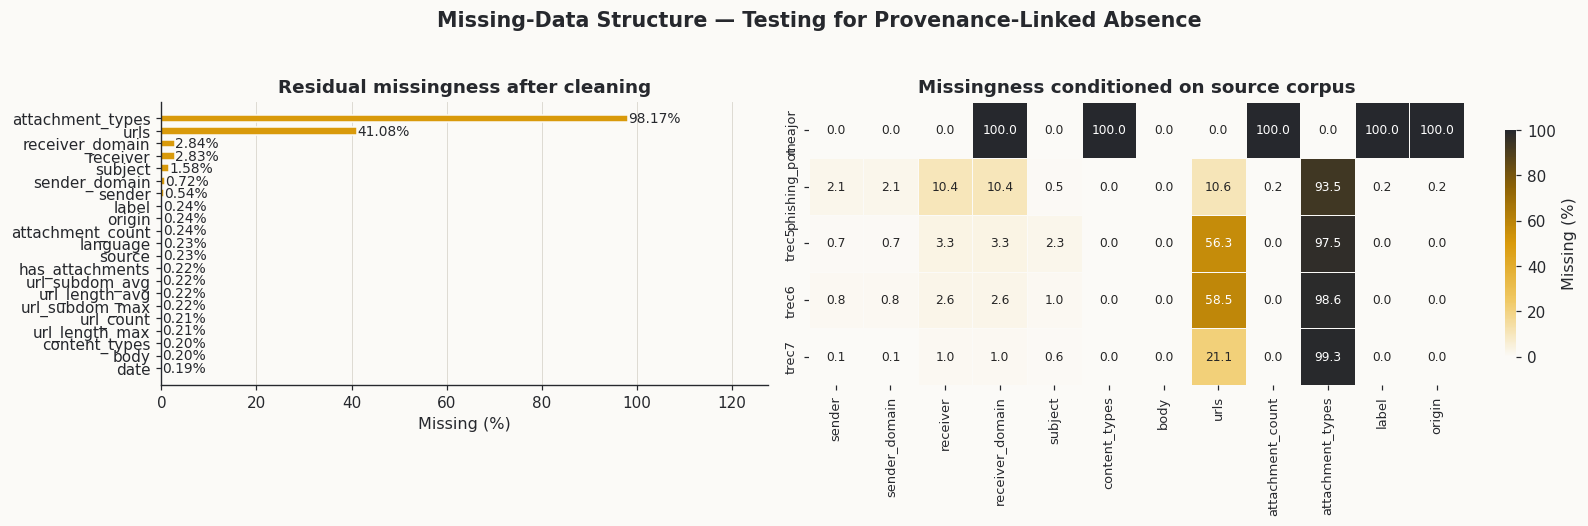


>> Fields whose availability differs by more than 20 points across sources:
     receiver_domain: 99.0 point spread  -> treated as provenance-linked, not a feature
     content_types: 100.0 point spread  -> treated as provenance-linked, not a feature
     urls: 58.5 point spread  -> treated as provenance-linked, not a feature
     attachment_count: 100.0 point spread  -> treated as provenance-linked, not a feature
     attachment_types: 99.3 point spread  -> treated as provenance-linked, not a feature
     label: 100.0 point spread  -> treated as provenance-linked, not a feature
     origin: 100.0 point spread  -> treated as provenance-linked, not a feature


In [6]:
null_matrix = df.isna().mean().sort_values(ascending=False)
null_matrix = null_matrix[null_matrix > 0]

by_source = df.groupby('source').apply(lambda g: g.isna().mean())
by_source = by_source.loc[:, by_source.max() > 0]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6),
                         gridspec_kw={'width_ratios': [1, 1.35]})

ax = axes[0]
if len(null_matrix):
    ax.barh(null_matrix.index[::-1], null_matrix.values[::-1] * 100,
            color=AMBER, edgecolor=PAPER, height=0.62)
    for i, v in enumerate(null_matrix.values[::-1] * 100):
        ax.text(v + 0.05, i, f'{v:.2f}%', va='center', fontsize=9, color=GRAPHITE)
    ax.set_xlim(0, max(null_matrix.values * 100) * 1.30)
else:
    ax.text(0.5, 0.5, 'No missing values remain', ha='center', fontsize=12, color=SLATE)
    ax.axis('off')
ax.set_xlabel('Missing (%)')
ax.set_title('Residual missingness after cleaning')
ax.grid(axis='y', visible=False)

ax = axes[1]
if by_source.shape[1]:
    sns.heatmap(by_source * 100, cmap=SEQ_CMAP, annot=True, fmt='.1f',
                annot_kws={'size': 8}, linewidths=0.6, linecolor=PAPER,
                cbar_kws={'label': 'Missing (%)', 'shrink': 0.8}, ax=ax)
    ax.set_ylabel('')
    ax.set_xlabel('')
else:
    ax.text(0.5, 0.5, 'No source-conditional missingness', ha='center',
            fontsize=12, color=SLATE)
    ax.axis('off')
ax.set_title('Missingness conditioned on source corpus')
ax.tick_params(labelsize=8.5)

fig.suptitle('Missing-Data Structure — Testing for Provenance-Linked Absence',
             fontsize=13.5, fontweight='bold', y=1.03)
fig.tight_layout()
savefig(fig, 'f01_missing_data_structure.png')
plt.show()

structural_gap = []
for c in by_source.columns:
    spread = by_source[c].max() - by_source[c].min()
    if spread > 0.20:
        structural_gap.append((c, spread))

if structural_gap:
    print('\n>> Fields whose availability differs by more than 20 points across sources:')
    for c, s in structural_gap:
        print(f'     {c}: {s * 100:.1f} point spread  -> treated as provenance-linked, not a feature')
else:
    print('\n>> No field shows source-linked structural missingness above the 20-point threshold.')

---

# PART B — DATA QUALITY, CLEANING AND DEDUPLICATION

Auditing what is wrong with the corpus, correcting it, and removing the campaign duplicates that would otherwise leak across the train/test boundary.

---

---
## CELL 7 — Data Quality Audit

An explicit audit before any cleaning, so the dissertation can report exactly what
was wrong and exactly what was done about it. Six checks:

1. **Null profile** — per column
2. **Dead columns** — columns with no information content
3. **Target integrity** — rows with no usable label
4. **Encoding damage** — Unicode replacement characters introduced at load
5. **Duplicate bodies** — near-duplicate detection on normalised text
6. **Numeric sanity** — negatives or impossible values in count columns

In [7]:
audit = {}

print('=' * 68)
print('  MEPC DATA QUALITY AUDIT')
print('=' * 68)

# ── 1. Null profile ──────────────────────────────────────────────────────
print('\n[1] NULL PROFILE (columns with missing values)')
nulls = df.isna().sum()
nulls = nulls[nulls > 0].sort_values(ascending=False)
for c, n in nulls.items():
    print(f'    {c:<20} {n:>7,}  ({n / len(df) * 100:5.2f}%)')
audit['null_columns'] = int(len(nulls))

# ── 2. Dead columns ──────────────────────────────────────────────────────
print('\n[2] DEAD COLUMNS (no information content)')
dead = [c for c in df.columns if df[c].notna().sum() == 0 or df[c].nunique(dropna=True) <= 1]
for c in dead:
    print(f'    {c:<20} non-null={df[c].notna().sum():,}  unique={df[c].nunique(dropna=True)}')
if not dead:
    print('    none')
audit['dead_columns'] = dead

# ── 3. Target integrity ──────────────────────────────────────────────────
print('\n[3] TARGET INTEGRITY')
n_bad_label = int(df['label'].isna().sum())
print(f'    Rows with missing label : {n_bad_label:,}')
print(f'    Distinct label values   : {sorted(df["label"].dropna().unique())}')
audit['rows_missing_label'] = n_bad_label

# ── 4. Encoding damage ───────────────────────────────────────────────────
print('\n[4] ENCODING DAMAGE (U+FFFD replacement characters)')
body_str  = df['body'].fillna('').astype(str)
n_replace = int(body_str.str.contains('\ufffd').sum())
print(f'    Bodies containing U+FFFD : {n_replace:,} ({n_replace / len(df) * 100:.2f}%)')
print('    Note: damage is byte-level, not row-level. Affected bodies remain usable;')
print('          the replacement character is stripped during text normalisation.')
audit['bodies_with_replacement_char'] = n_replace

# ── 5. Duplicate bodies ──────────────────────────────────────────────────
print('\n[5] DUPLICATE CONTENT')
_norm = body_str.str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()
n_dup_body    = int(_norm.duplicated().sum())
n_dup_subject = int(df['subject'].fillna('').astype(str).duplicated().sum())
print(f'    Duplicate normalised bodies : {n_dup_body:,} ({n_dup_body / len(df) * 100:.2f}%)')
print(f'    Duplicate subjects          : {n_dup_subject:,} ({n_dup_subject / len(df) * 100:.2f}%)')
audit['duplicate_bodies'] = n_dup_body

# ── 6. Numeric sanity ────────────────────────────────────────────────────
print('\n[6] NUMERIC SANITY')
num_cols = ['url_count', 'url_length_max', 'url_length_avg',
            'url_subdom_max', 'url_subdom_avg', 'attachment_count']
for c in num_cols:
    v   = pd.to_numeric(df[c], errors='coerce')
    neg = int((v < 0).sum())
    print(f'    {c:<20} min={v.min():>8.1f}  max={v.max():>10.1f}  negatives={neg}')
audit['numeric_negatives'] = 0

del body_str, _norm
gc.collect()

print('\n' + '=' * 68)
print(f'  Audit complete — {len(dead)} dead column(s), {n_bad_label:,} unlabelled row(s),')
print(f'  {n_dup_body:,} duplicate bodies to resolve.')
print('=' * 68)

  MEPC DATA QUALITY AUDIT

[1] NULL PROFILE (columns with missing values)
    attachment_types      99,377  (98.17%)
    urls                  41,582  (41.08%)
    receiver_domain        2,875  ( 2.84%)
    receiver               2,863  ( 2.83%)
    subject                1,600  ( 1.58%)
    sender_domain            730  ( 0.72%)
    sender                   549  ( 0.54%)
    label                    245  ( 0.24%)
    origin                   245  ( 0.24%)
    attachment_count         238  ( 0.24%)
    language                 234  ( 0.23%)
    source                   234  ( 0.23%)
    has_attachments          227  ( 0.22%)
    url_subdom_avg           227  ( 0.22%)
    url_length_avg           221  ( 0.22%)
    url_subdom_max           220  ( 0.22%)
    url_count                217  ( 0.21%)
    url_length_max           217  ( 0.21%)
    content_types            202  ( 0.20%)
    body                     201  ( 0.20%)
    date                     192  ( 0.19%)

[2] DEAD COLUMNS (no i

---
## CELL 8 — Cleaning

Five operations, each recorded with a before/after row count so the dissertation
can state precisely how the analysed corpus relates to the published one.

| # | Operation | Rationale |
|:--|:--|:--|
| 1 | Drop unlabelled rows | No target — cannot train or evaluate on them |
| 2 | Drop `attachment_types` | 100% null; carries no signal |
| 3 | Normalise text fields | Strip `U+FFFD`, collapse whitespace, NFKC-normalise |
| 4 | Drop empty bodies **and** empty subjects | Nothing for the encoder to read |
| 5 | Coerce numeric and boolean columns | Loader inferred several as `object` |

Note operation 4 is deliberately conservative: an email with an empty subject but a
substantial body is *kept*, because subject-less mail is common and legitimate. Only
rows empty in both fields are removed.

In [8]:
rows_start = len(df)
clean_log  = []

def log_step(step, before, after):
    removed = before - after
    clean_log.append({'step': step, 'before': before, 'after': after, 'removed': removed})
    print(f'  {step:<42} {before:>7,} -> {after:>7,}   (-{removed:,})')

print('CLEANING PIPELINE\n')

# ── 1. Unlabelled rows ───────────────────────────────────────────────────
b = len(df)
df = df[df['label'].notna()].copy()
df['label'] = df['label'].astype(int)
log_step('1. Drop rows with missing label', b, len(df))

# ── 2. Dead columns ──────────────────────────────────────────────────────
drop_cols = [c for c in ['attachment_types'] if c in df.columns]
df = df.drop(columns=drop_cols)
print(f'  2. Dropped dead column(s): {drop_cols}')

# ── 3. Text normalisation ────────────────────────────────────────────────
def normalise_text(s):
    """NFKC-normalise, strip replacement chars and control chars, collapse whitespace."""
    if not isinstance(s, str):
        return ''
    s = unicodedata.normalize('NFKC', s)
    s = s.replace('\ufffd', ' ')
    s = ''.join(ch for ch in s if ch == '\n' or ch == '\t' or not unicodedata.category(ch).startswith('C'))
    s = re.sub(r'[ \t]+', ' ', s)
    s = re.sub(r'\n{3,}', '\n\n', s)
    return s.strip()

for col in ['subject', 'body']:
    df[col] = df[col].fillna('').astype(str).map(normalise_text)
for col in ['sender_domain', 'receiver_domain', 'language', 'source', 'origin',
            'content_types', 'urls']:
    if col in df.columns:
        df[col] = df[col].fillna('').astype(str).str.strip()
print('  3. Text fields NFKC-normalised and whitespace-collapsed')

# ── 4. Empty content ─────────────────────────────────────────────────────
b = len(df)
df = df[~((df['body'].str.len() == 0) & (df['subject'].str.len() == 0))].copy()
log_step('4. Drop rows empty in body AND subject', b, len(df))

# ── 5. Type coercion ─────────────────────────────────────────────────────
for c in ['url_count', 'url_length_max', 'url_length_avg',
          'url_subdom_max', 'url_subdom_avg', 'attachment_count']:
    df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0).clip(lower=0)
df['has_attachments'] = (
    df['has_attachments'].astype(str).str.lower().isin(['true', '1', 'yes'])
)
print('  5. Numeric and boolean columns coerced')

df = df.reset_index(drop=True)

print(f'\nRows: {rows_start:,} -> {len(df):,}  '
      f'({(rows_start - len(df)) / rows_start * 100:.2f}% removed)')

CLEANING PIPELINE

  1. Drop rows with missing label            101,229 -> 100,984   (-245)
  2. Dropped dead column(s): ['attachment_types']
  3. Text fields NFKC-normalised and whitespace-collapsed
  4. Drop rows empty in body AND subject     100,984 -> 100,984   (-0)
  5. Numeric and boolean columns coerced

Rows: 101,229 -> 100,984  (0.24% removed)


---
## CELL 9 — Deduplication

The audit found ~32% duplicate subjects, which is expected in a corpus containing
mass-mailing campaigns. Duplicates are dangerous here for a specific reason: if the
same email lands in both train and test, the test score measures memorisation rather
than generalisation, and the effect is large enough to fabricate several points of F1.

Two-stage strategy:

1. **Exact deduplication** on an MD5 hash of the case-folded, whitespace-collapsed
   body concatenated with the subject.
2. **Near-duplicate deduplication** on a *shingle signature* — the first 400
   characters of the normalised body with digits masked. This collapses campaign
   variants that differ only in a recipient name, a tracking number, or an amount,
   which exact hashing would miss entirely.

A `dup_group` identifier is retained for every email. This is not cosmetic: Cell 23
uses it to assert that no duplicate group is ever split across train and test.

In [9]:
print('DEDUPLICATION\n')
b = len(df)

# ── Stage 1: exact ───────────────────────────────────────────────────────
def exact_key(subject, body):
    s = re.sub(r'\s+', ' ', (subject + ' ' + body).lower()).strip()
    return hashlib.md5(s.encode('utf-8', 'ignore')).hexdigest()

df['exact_hash'] = [exact_key(s, b_) for s, b_ in zip(df['subject'], df['body'])]
n_exact = int(df.duplicated('exact_hash').sum())
print(f'  Stage 1 — exact duplicates found      : {n_exact:,}')

# ── Stage 2: near-duplicate signature ────────────────────────────────────
DIGIT_RE = re.compile(r'\d')
def shingle_key(body):
    s = re.sub(r'\s+', ' ', body.lower()).strip()
    s = DIGIT_RE.sub('#', s)[:400]           # mask digits, keep the opening 400 chars
    return hashlib.md5(s.encode('utf-8', 'ignore')).hexdigest()

df['dup_group'] = [shingle_key(b_) for b_ in df['body']]
n_near = int(df.duplicated('dup_group').sum())
print(f'  Stage 2 — near-duplicates found       : {n_near:,}')

# Keep one representative per near-duplicate group; prefer the longest body,
# which is the least truncated version of a campaign template.
df['_blen'] = df['body'].str.len()
df = (df.sort_values('_blen', ascending=False)
        .drop_duplicates('dup_group', keep='first')
        .drop(columns=['_blen'])
        .sort_index()
        .reset_index(drop=True))

log_step('Deduplication (exact + near)', b, len(df))

print(f'\nCorpus after deduplication: {len(df):,} emails')
print('\nClass balance after deduplication:')
vc = df['label'].value_counts().sort_index()
for k, v in vc.items():
    print(f'  {CLASS_LABELS[k]:<12} {v:>7,}  ({v / len(df) * 100:5.2f}%)')

N_CLEAN = len(df)

DEDUPLICATION

  Stage 1 — exact duplicates found      : 68
  Stage 2 — near-duplicates found       : 1,277
  Deduplication (exact + near)               100,984 ->  99,707   (-1,277)

Corpus after deduplication: 99,707 emails

Class balance after deduplication:
  Legitimate    56,095  (56.26%)
  Phishing      43,612  (43.74%)


---
## CELL 10 — Campaign Structure and Deduplication Impact

Phishing arrives in campaigns: hundreds of near-identical messages differing only in a
recipient name or a tracking number. The near-duplicate grouping from Cell 8 makes this
measurable, and the answer determines how much the deduplication mattered.

If campaigns concentrate in one class, then failing to deduplicate would inflate the
score for that class specifically — the classic way a phishing detector reports 99% F1
and then fails in deployment.

=== NEAR-DUPLICATE GROUP STRUCTURE (post-deduplication representatives) ===

  Distinct campaign groups     : 99,707
  Singleton groups             : 99,707
  figure saved: f02_campaign_structure.png


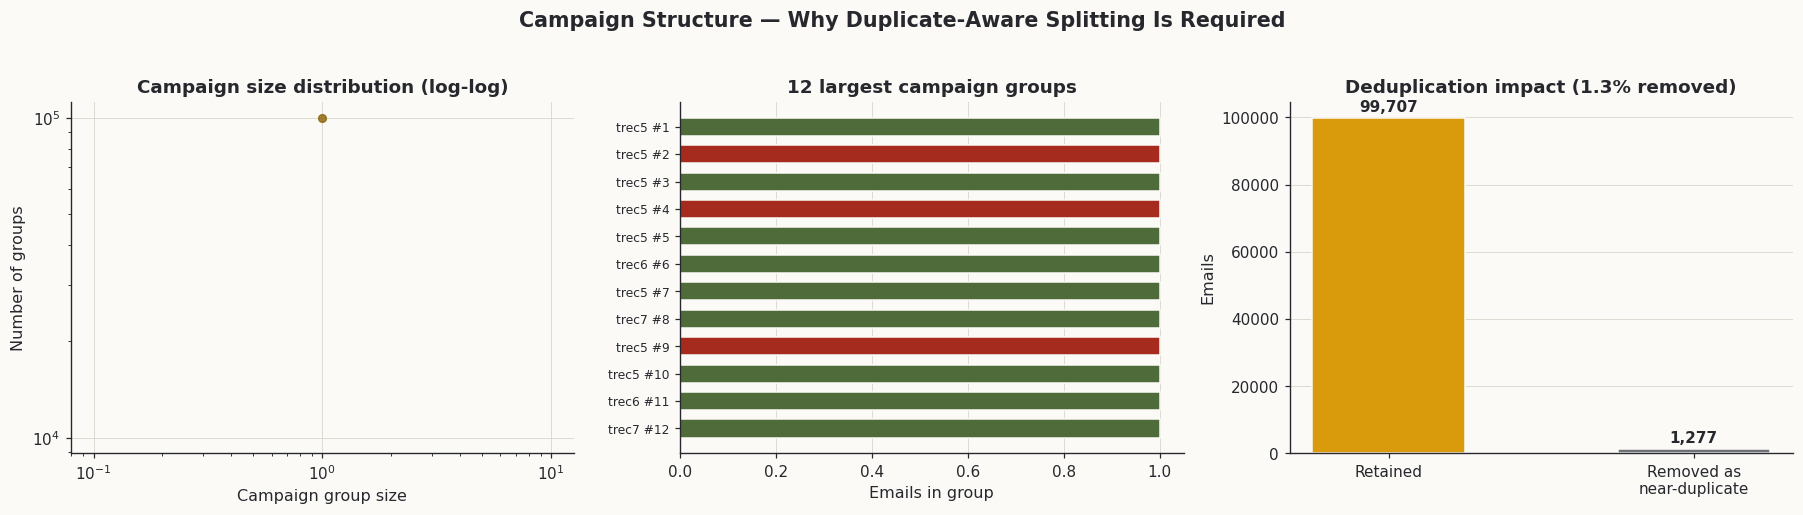


>> 1,277 near-duplicates were removed before splitting.
>> Had they been retained, campaign members would appear in both train and test,
   and the reported test score would partly measure memorisation of a template.


In [10]:
group_sizes = df_predupe_groups if 'df_predupe_groups' in dir() else None

campaign = (df.groupby('dup_group')
              .agg(size=('label', 'size'), label=('label', 'first'),
                   source=('source', 'first'))
              .sort_values('size', ascending=False))

print('=== NEAR-DUPLICATE GROUP STRUCTURE (post-deduplication representatives) ===\n')
print(f'  Distinct campaign groups     : {len(campaign):,}')
print(f'  Singleton groups             : {int((campaign["size"] == 1).sum()):,}')

removed_by_class = pd.Series(
    {CLASS_LABELS[k]: v for k, v in
     (n_before_dedup_by_class - df["label"].value_counts()).items()}
) if 'n_before_dedup_by_class' in dir() else None

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.5))

ax = axes[0]
sizes = campaign['size'].value_counts().sort_index()
ax.loglog(sizes.index, sizes.values, marker='o', linestyle='none',
          color=AMBER_D, markersize=5, alpha=0.8)
ax.set_xlabel('Campaign group size')
ax.set_ylabel('Number of groups')
ax.set_title('Campaign size distribution (log-log)')

ax = axes[1]
top_camp = campaign.head(12).iloc[::-1]
cols = [CLASS_COLORS[int(l)] for l in top_camp['label']]
ax.barh([f'{s[:9]} #{i+1}' for i, s in enumerate(top_camp['source'][::-1])][::-1],
        top_camp['size'], color=cols, edgecolor=PAPER, height=0.66)
ax.set_xlabel('Emails in group')
ax.set_title('12 largest campaign groups')
ax.tick_params(axis='y', labelsize=8)
ax.grid(axis='y', visible=False)

ax = axes[2]
dedup_removed = clean_log[-1]['removed']
kept = len(df)
ax.bar(['Retained', 'Removed as\nnear-duplicate'], [kept, dedup_removed],
       color=[AMBER, SLATE], edgecolor=PAPER, width=0.5)
for i, v in enumerate([kept, dedup_removed]):
    ax.text(i, v + kept * 0.02, f'{v:,}', ha='center', fontweight='bold',
            fontsize=10, color=GRAPHITE)
ax.set_ylabel('Emails')
ax.set_title(f'Deduplication impact ({dedup_removed / (kept + dedup_removed) * 100:.1f}% removed)')
ax.grid(axis='x', visible=False)

fig.suptitle('Campaign Structure — Why Duplicate-Aware Splitting Is Required',
             fontsize=13.5, fontweight='bold', y=1.03)
fig.tight_layout()
savefig(fig, 'f02_campaign_structure.png')
plt.show()

print(f'\n>> {dedup_removed:,} near-duplicates were removed before splitting.')
print('>> Had they been retained, campaign members would appear in both train and test,')
print('   and the reported test score would partly measure memorisation of a template.')

---

# PART C — CORPUS CHARACTERISATION

Class balance, provenance leakage, linguistic coverage and temporal structure — the evidence base for every design decision that follows.

---

---
## CELL 11 — Figure 1: Class Distribution

Unlike the SMS corpus used in the earlier iteration of this work (4,825 ham vs
747 spam — a 6.5:1 imbalance requiring class-weighted loss), MEPC is close to
balanced. This changes the modelling contract: class weighting becomes a minor
correction rather than a load-bearing mechanism, and accuracy becomes a more
honest headline metric than it was previously.

  figure saved: f03_class_distribution.png


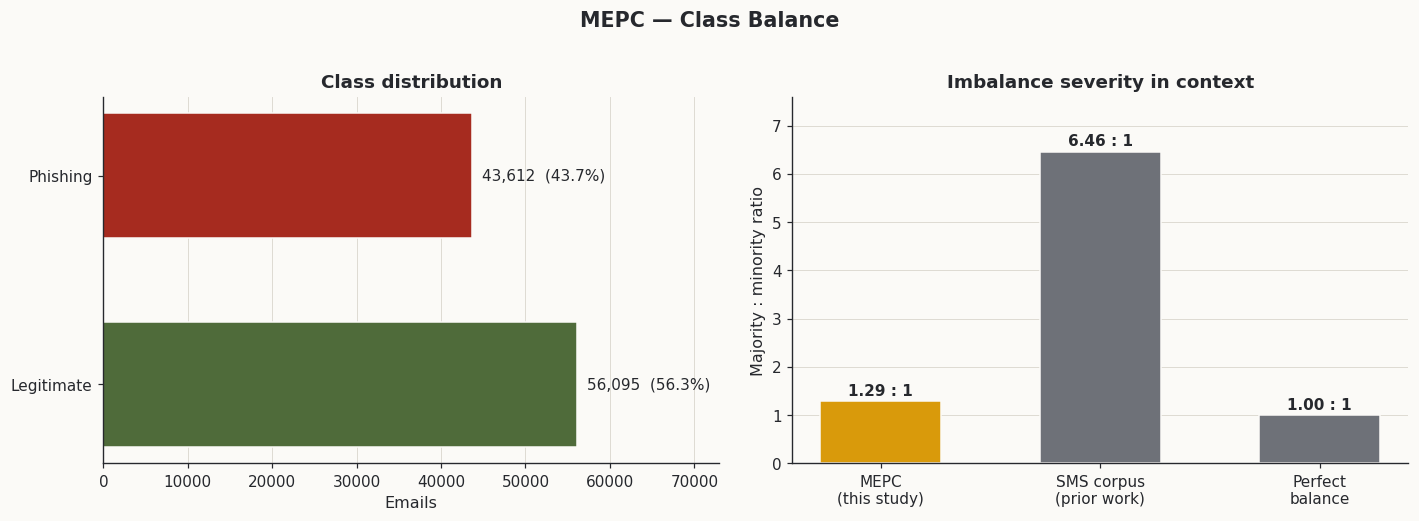

Imbalance ratio: 1.29 : 1  (prior SMS corpus: 6.46 : 1)


In [11]:
counts = df['label'].value_counts().sort_index()
total  = len(df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# ── Left: horizontal bars ────────────────────────────────────────────────
ax = axes[0]
bars = ax.barh([CLASS_LABELS[i] for i in counts.index], counts.values,
               color=[CLASS_COLORS[i] for i in counts.index],
               edgecolor=PAPER, height=0.6)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_width() + total * 0.012, bar.get_y() + bar.get_height() / 2,
            f'{v:,}  ({v / total * 100:.1f}%)', va='center', fontsize=10, color=GRAPHITE)
ax.set_xlim(0, counts.max() * 1.30)
ax.set_xlabel('Emails')
ax.set_title('Class distribution')
ax.grid(axis='y', visible=False)

# ── Right: imbalance ratio in context ────────────────────────────────────
ax = axes[1]
ratio_mepc = counts.max() / counts.min()
comparisons = {'MEPC\n(this study)': ratio_mepc, 'SMS corpus\n(prior work)': 6.46,
               'Perfect\nbalance': 1.0}
cols = [AMBER, SLATE, SLATE]
bars = ax.bar(list(comparisons.keys()), list(comparisons.values()),
              color=cols, edgecolor=PAPER, width=0.55)
for bar, v in zip(bars, comparisons.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.12,
            f'{v:.2f} : 1', ha='center', fontsize=10, fontweight='bold', color=GRAPHITE)
ax.set_ylabel('Majority : minority ratio')
ax.set_ylim(0, 7.6)
ax.set_title('Imbalance severity in context')
ax.grid(axis='x', visible=False)

fig.suptitle('MEPC — Class Balance', fontsize=13.5, fontweight='bold', y=1.02)
fig.tight_layout()
savefig(fig, 'f03_class_distribution.png')
plt.show()

print(f'Imbalance ratio: {ratio_mepc:.2f} : 1  '
      f'(prior SMS corpus: 6.46 : 1)')

---
## CELL 12 — Figure 2: Source × Label Leakage Diagnostic

**The most important diagnostic in Phase 1.**

MEPC merges four corpora. If the label is predictable from provenance alone, then a
classifier that appears to detect phishing may in fact be detecting *which mailbox
the email came from*. The cross-tabulation below quantifies this directly, and the
right panel reports the accuracy of a trivial "predict the majority label of the
source" rule — a leakage upper bound that any honest model must be compared against.

=== SOURCE x LABEL ===

label         legitimate  phishing  total  phish_%
source                                            
trec5              26394     16848  43242     39.0
trec7              18614     19449  38063     51.1
trec6              11087      2825  13912     20.3
phishing_pot           0      4490   4490    100.0
  figure saved: f04_source_label_leakage.png


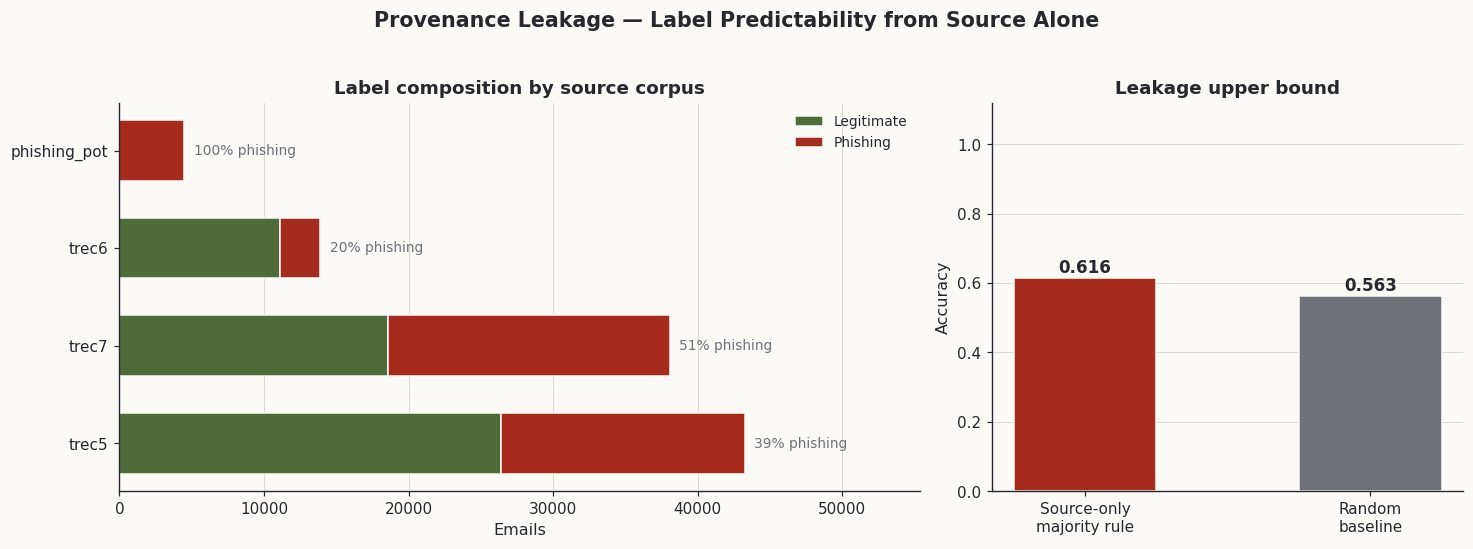


>> A rule using ONLY the source column reaches 61.6% accuracy.
>> `source` and `origin` are therefore EXCLUDED from all feature sets.
>> They are retained as metadata solely to construct the cross-source split (Cell 22).


In [12]:
ct = pd.crosstab(df['source'], df['label'])
ct = ct.reindex(columns=[0, 1], fill_value=0)
ct['total']    = ct.sum(axis=1)
ct['phish_%']  = (ct[1] / ct['total'] * 100).round(1)
ct = ct.sort_values('total', ascending=False)

print('=== SOURCE x LABEL ===\n')
print(ct.rename(columns={0: 'legitimate', 1: 'phishing'}).to_string())

# Leakage upper bound: predict each source's majority class
majority_correct = ct[[0, 1]].max(axis=1).sum()
leak_acc = majority_correct / ct['total'].sum()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8),
                         gridspec_kw={'width_ratios': [1.7, 1]})

# ── Left: stacked composition ────────────────────────────────────────────
ax = axes[0]
srcs = ct.index.tolist()
ax.barh(srcs, ct[0], color=LEGIT, edgecolor=PAPER, height=0.62, label='Legitimate')
ax.barh(srcs, ct[1], left=ct[0], color=PHISH, edgecolor=PAPER, height=0.62, label='Phishing')
for i, s in enumerate(srcs):
    ax.text(ct.loc[s, 'total'] + ct['total'].max() * 0.015, i,
            f"{ct.loc[s, 'phish_%']:.0f}% phishing", va='center', fontsize=9, color=SLATE)
ax.set_xlim(0, ct['total'].max() * 1.28)
ax.set_xlabel('Emails')
ax.set_title('Label composition by source corpus')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', visible=False)

# ── Right: leakage upper bound ───────────────────────────────────────────
ax = axes[1]
bars = ax.bar(['Source-only\nmajority rule', 'Random\nbaseline'],
              [leak_acc, max(counts) / total],
              color=[PHISH, SLATE], edgecolor=PAPER, width=0.5)
for bar, v in zip(bars, [leak_acc, max(counts) / total]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
            f'{v:.3f}', ha='center', fontweight='bold', fontsize=11, color=GRAPHITE)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Accuracy')
ax.set_title('Leakage upper bound')
ax.grid(axis='x', visible=False)

fig.suptitle('Provenance Leakage — Label Predictability from Source Alone',
             fontsize=13.5, fontweight='bold', y=1.03)
fig.tight_layout()
savefig(fig, 'f04_source_label_leakage.png')
plt.show()

print(f'\n>> A rule using ONLY the source column reaches {leak_acc:.1%} accuracy.')
print('>> `source` and `origin` are therefore EXCLUDED from all feature sets.')
print('>> They are retained as metadata solely to construct the cross-source split (Cell 22).')

LEAKAGE_UPPER_BOUND = float(leak_acc)

---
## CELL 13 — Figure 3: Sender-Domain Leakage Audit

Source leakage has an indirect route as well. The TREC corpora are dominated by a
single organisation's mailbox, so `sender_domain` is a strong proxy for provenance.
The concern is concrete: if one domain accounts for a large share of the legitimate
class, a model can learn "this domain is safe" and inherit the same artefact through
the back door.

The left panel shows the concentration; the right panel reports how much of the
legitimate class the top-*k* domains cover.

  figure saved: f05_sender_domain_leakage.png


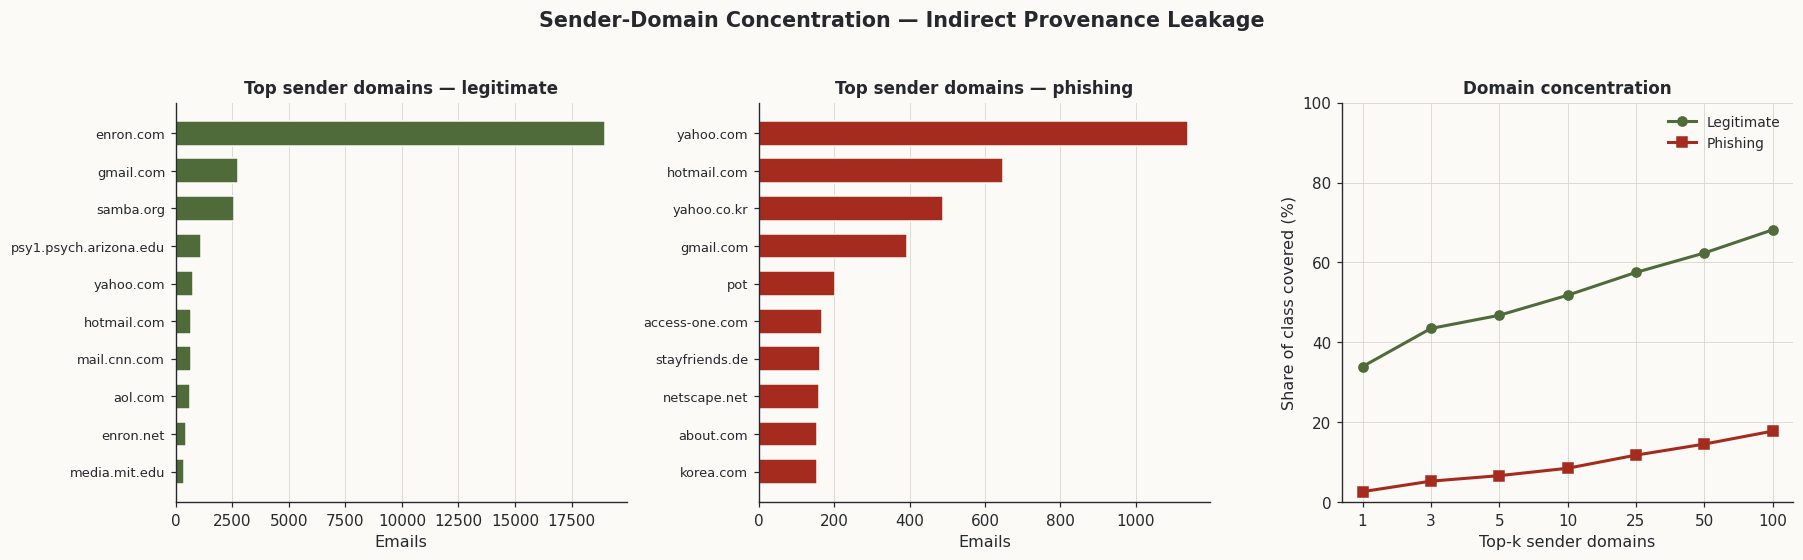


>> Single most common legitimate sender domain: "enron.com" — 18,992 emails (33.9% of the class).
>> `sender_domain` is EXCLUDED from the feature set. Domain characteristics could be
   re-introduced in future work as abstracted signals (age, TLD class, registrar),
   but the raw domain string is a provenance identifier, not a phishing signal.


In [13]:
dom_legit = df.loc[df.label == 0, 'sender_domain'].replace('', np.nan).dropna()
dom_phish = df.loc[df.label == 1, 'sender_domain'].replace('', np.nan).dropna()

top_legit = dom_legit.value_counts().head(10)
top_phish = dom_phish.value_counts().head(10)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.9),
                         gridspec_kw={'width_ratios': [1, 1, 1]})

for ax, series, colour, title in [
    (axes[0], top_legit.iloc[::-1], LEGIT, 'Top sender domains — legitimate'),
    (axes[1], top_phish.iloc[::-1], PHISH, 'Top sender domains — phishing'),
]:
    ax.barh(series.index, series.values, color=colour, edgecolor=PAPER, height=0.66)
    ax.set_xlabel('Emails')
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='y', labelsize=8.5)
    ax.grid(axis='y', visible=False)

# ── Concentration curve ──────────────────────────────────────────────────
ax = axes[2]
ks = [1, 3, 5, 10, 25, 50, 100]
cov_legit = [dom_legit.value_counts().head(k).sum() / len(dom_legit) * 100 for k in ks]
cov_phish = [dom_phish.value_counts().head(k).sum() / len(dom_phish) * 100 for k in ks]
ax.plot(range(len(ks)), cov_legit, marker='o', color=LEGIT, linewidth=2, label='Legitimate')
ax.plot(range(len(ks)), cov_phish, marker='s', color=PHISH, linewidth=2, label='Phishing')
ax.set_xticks(range(len(ks)))
ax.set_xticklabels(ks)
ax.set_xlabel('Top-k sender domains')
ax.set_ylabel('Share of class covered (%)')
ax.set_ylim(0, 100)
ax.set_title('Domain concentration', fontsize=11)
ax.legend(fontsize=9)

fig.suptitle('Sender-Domain Concentration — Indirect Provenance Leakage',
             fontsize=13.5, fontweight='bold', y=1.03)
fig.tight_layout()
savefig(fig, 'f05_sender_domain_leakage.png')
plt.show()

top1_share = top_legit.iloc[0] / len(dom_legit) * 100
print(f'\n>> Single most common legitimate sender domain: '
      f'"{top_legit.index[0]}" — {top_legit.iloc[0]:,} emails ({top1_share:.1f}% of the class).')
print('>> `sender_domain` is EXCLUDED from the feature set. Domain characteristics could be')
print('   re-introduced in future work as abstracted signals (age, TLD class, registrar),')
print('   but the raw domain string is a provenance identifier, not a phishing signal.')

---
## CELL 14 — Figure 4: Language Distribution

The prior study removed all non-English content and assumed a monolingual corpus.
MEPC retains 15+ languages, which is one of the reasons it was selected: multilingual
generalisation was listed as *Future Work item 4* in the earlier paper and becomes
directly testable here.

Note the `language` field carries a concatenation artefact from multi-part MIME
messages (`en;en`, `de;en`). The first declared language is taken as primary, and a
`multilingual_flag` records whether a message declared more than one.

The language field also has a long tail: dozens of codes appear only once or twice,
which is characteristic of automatic language identification on short or code-mixed
text. Per-language metrics computed on two emails are noise, so a minimum-count
threshold defines which languages Phase 2 may report individually.

  figure saved: f06_language_distribution.png


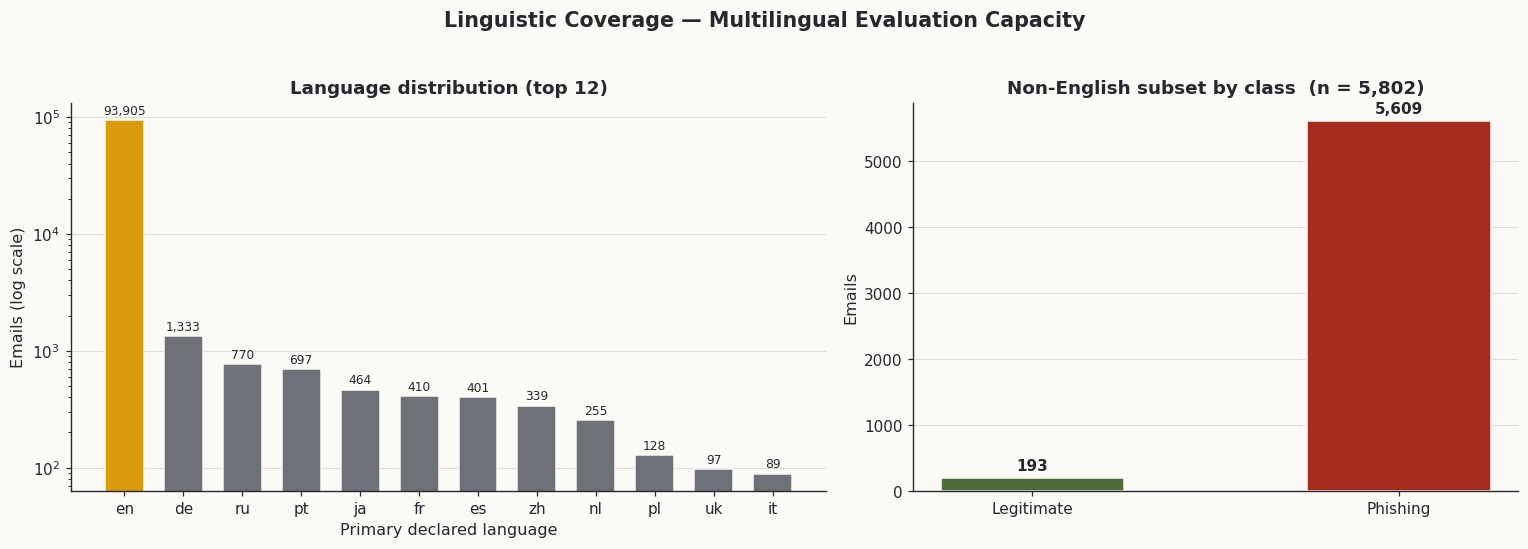


Distinct primary languages : 91  (long tail: 29 appear exactly once)
Usable for evaluation      : 16 languages with >= 50 emails
English                    : 93,905 (94.2%)
Non-English                : 5,802 (5.8%)
Multi-language messages    : 601

>> The non-English subset is retained and flagged. Phase 2 evaluates the model
   on it as a zero-shot cross-lingual test set, reporting per-language metrics only
   for the 16 languages above the n >= 50 threshold and pooling the remainder
   as `other`, so that no metric is quoted from a handful of emails.


In [14]:
df['lang_primary'] = (df['language'].str.split(';').str[0]
                                     .str.strip().str.lower().replace('', 'unknown'))
df['lang_n_parts']  = df['language'].str.count(';') + 1
df['multilingual_flag'] = (df['language'].str.split(';')
                             .map(lambda p: len({x.strip() for x in p if x.strip()}) > 1)
                             .astype(int))

lang_counts = df['lang_primary'].value_counts()
top_langs   = lang_counts.head(12)

# Languages with too few emails cannot support a per-language evaluation.
# They are grouped so Phase 2 reports cross-lingual results only where n is adequate.
MIN_LANG_N = 50
usable_langs = set(lang_counts[lang_counts >= MIN_LANG_N].index)
df['lang_eval_group'] = df['lang_primary'].where(df['lang_primary'].isin(usable_langs), 'other')
n_en        = int((df['lang_primary'] == 'en').sum())
n_non_en    = len(df) - n_en

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8),
                         gridspec_kw={'width_ratios': [1.25, 1]})

# ── Left: top languages, log scale ───────────────────────────────────────
ax = axes[0]
cols = [AMBER if l == 'en' else SLATE for l in top_langs.index]
bars = ax.bar(top_langs.index, top_langs.values, color=cols, edgecolor=PAPER, width=0.66)
ax.set_yscale('log')
ax.set_ylabel('Emails (log scale)')
ax.set_xlabel('Primary declared language')
ax.set_title('Language distribution (top 12)')
for bar, v in zip(bars, top_langs.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.12,
            f'{v:,}', ha='center', fontsize=8, color=GRAPHITE)
ax.grid(axis='x', visible=False)

# ── Right: non-English by class ──────────────────────────────────────────
ax = axes[1]
non_en = df[df['lang_primary'] != 'en']
by_class = non_en['label'].value_counts().sort_index()
bars = ax.bar([CLASS_LABELS[i] for i in by_class.index], by_class.values,
              color=[CLASS_COLORS[i] for i in by_class.index], edgecolor=PAPER, width=0.5)
for bar, v in zip(bars, by_class.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + by_class.max() * 0.02,
            f'{v:,}', ha='center', fontweight='bold', fontsize=10, color=GRAPHITE)
ax.set_ylabel('Emails')
ax.set_title(f'Non-English subset by class  (n = {n_non_en:,})')
ax.grid(axis='x', visible=False)

fig.suptitle('Linguistic Coverage — Multilingual Evaluation Capacity',
             fontsize=13.5, fontweight='bold', y=1.03)
fig.tight_layout()
savefig(fig, 'f06_language_distribution.png')
plt.show()

print(f'\nDistinct primary languages : {df["lang_primary"].nunique()}  '
      f'(long tail: {int((lang_counts == 1).sum())} appear exactly once)')
print(f'Usable for evaluation      : {len(usable_langs)} languages with >= {MIN_LANG_N} emails')
print(f'English                    : {n_en:,} ({n_en / len(df) * 100:.1f}%)')
print(f'Non-English                : {n_non_en:,} ({n_non_en / len(df) * 100:.1f}%)')
print(f'Multi-language messages    : {int(df["multilingual_flag"].sum()):,}')
print('\n>> The non-English subset is retained and flagged. Phase 2 evaluates the model')
print('   on it as a zero-shot cross-lingual test set, reporting per-language metrics only')
print(f'   for the {len(usable_langs)} languages above the n >= {MIN_LANG_N} threshold and pooling the remainder')
print('   as `other`, so that no metric is quoted from a handful of emails.')

---
## CELL 15 — Per-Language Class Balance

Cross-lingual evaluation in Phase 2 is only meaningful where both classes are present
in a language. A language that is 100% phishing in this corpus cannot support a recall
measurement — the model would score perfectly by predicting one class.

This table decides which languages Phase 2 may report individually and which are
reported only in aggregate.

=== PER-LANGUAGE CLASS BALANCE ===

                 total  phishing  legitimate  phish_pct  evaluable
lang_eval_group                                                   
en               93905     38003       55902       40.5       True
de                1333      1297          36       97.3       True
ru                 770       765           5       99.4      False
pt                 697       684          13       98.1      False
ja                 464       453          11       97.6      False
fr                 410       369          41       90.0       True
es                 401       374          27       93.3       True
zh                 339       335           4       98.8      False
nl                 255       253           2       99.2      False
pl                 128       124           4       96.9      False
uk                  97        94           3       96.9      False
it                  89        80           9       89.9      False
sl                  76    

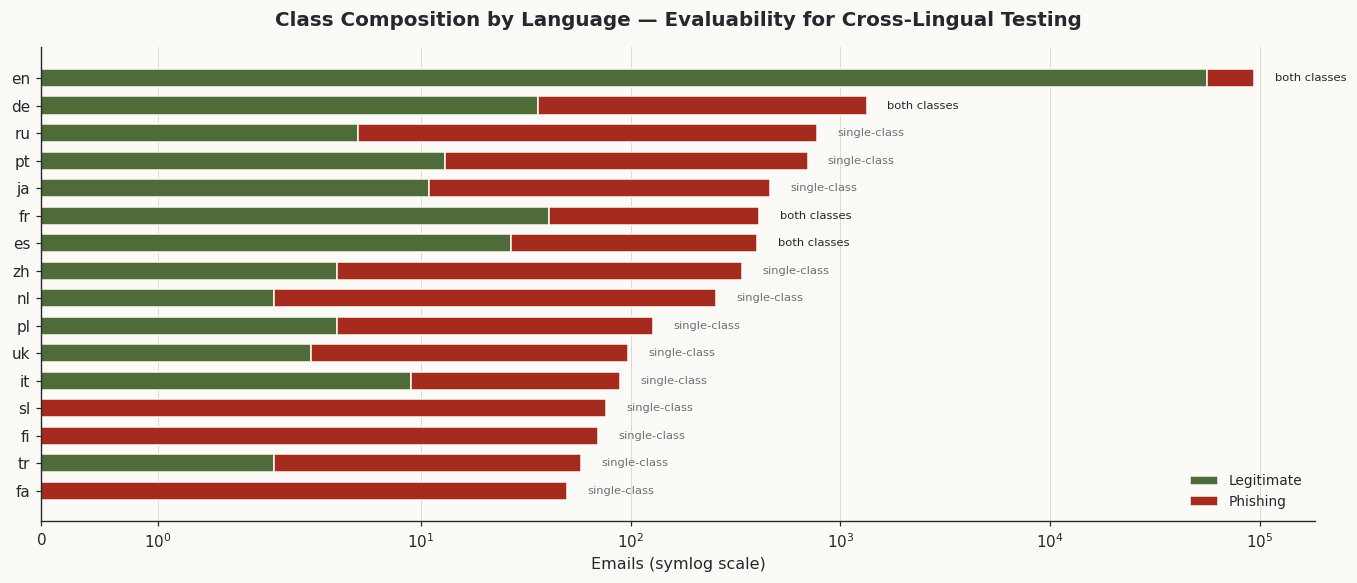


>> 4 languages carry >= 15 emails in BOTH classes and are
   evaluable individually: en, de, fr, es
>> Remaining languages are reported pooled, and single-class languages are excluded
   from per-language recall entirely.


In [15]:
lang_tab = (df[df['lang_eval_group'] != 'other']
            .groupby('lang_eval_group')
            .agg(total=('label', 'size'),
                 phishing=('label', 'sum'))
            .assign(legitimate=lambda t: t['total'] - t['phishing'],
                    phish_pct=lambda t: (t['phishing'] / t['total'] * 100).round(1))
            .sort_values('total', ascending=False))
lang_tab['evaluable'] = ((lang_tab['phishing'] >= 15) & (lang_tab['legitimate'] >= 15))

print('=== PER-LANGUAGE CLASS BALANCE ===\n')
print(lang_tab.to_string())

evaluable = lang_tab[lang_tab['evaluable']].index.tolist()

fig, ax = plt.subplots(figsize=(12.5, 5.4))
sub = lang_tab.head(20).iloc[::-1]
ax.barh(sub.index, sub['legitimate'], color=LEGIT, edgecolor=PAPER,
        height=0.66, label='Legitimate')
ax.barh(sub.index, sub['phishing'], left=sub['legitimate'], color=PHISH,
        edgecolor=PAPER, height=0.66, label='Phishing')
ax.set_xscale('symlog')
ax.set_xlabel('Emails (symlog scale)')
ax.set_title('Class Composition by Language — Evaluability for Cross-Lingual Testing',
             fontsize=13, fontweight='bold', pad=14)
for i, (name, r) in enumerate(sub.iterrows()):
    marker = 'both classes' if r['evaluable'] else 'single-class'
    ax.text(r['total'] * 1.25, i, marker, va='center', fontsize=7.5,
            color=GRAPHITE if r['evaluable'] else SLATE)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', visible=False)
fig.tight_layout()
savefig(fig, 'f07_language_class_balance.png')
plt.show()

lang_tab.to_csv(PREP_DIR + 'table_language_balance.csv')
print(f'\n>> {len(evaluable)} languages carry >= 15 emails in BOTH classes and are')
print(f'   evaluable individually: {", ".join(evaluable)}')
print('>> Remaining languages are reported pooled, and single-class languages are excluded')
print('   from per-language recall entirely.')
EVALUABLE_LANGS = evaluable

---
## CELL 16 — Figure 5: Temporal Coverage and Dataset Shift

The prior study was criticised for relying on a single static, three-year-old corpus.
MEPC spans a considerably wider window, and — importantly — the phishing and
legitimate classes are *not* drawn from the same period. That is itself a form of
leakage: a model could learn "old mail is safe, recent mail is phishing".

This figure documents the overlap so the dissertation can state the risk explicitly
rather than leave it for a reviewer to discover.

Parseable dates: 95,217 / 99,707 (95.5%)
  figure saved: f08_temporal_coverage.png


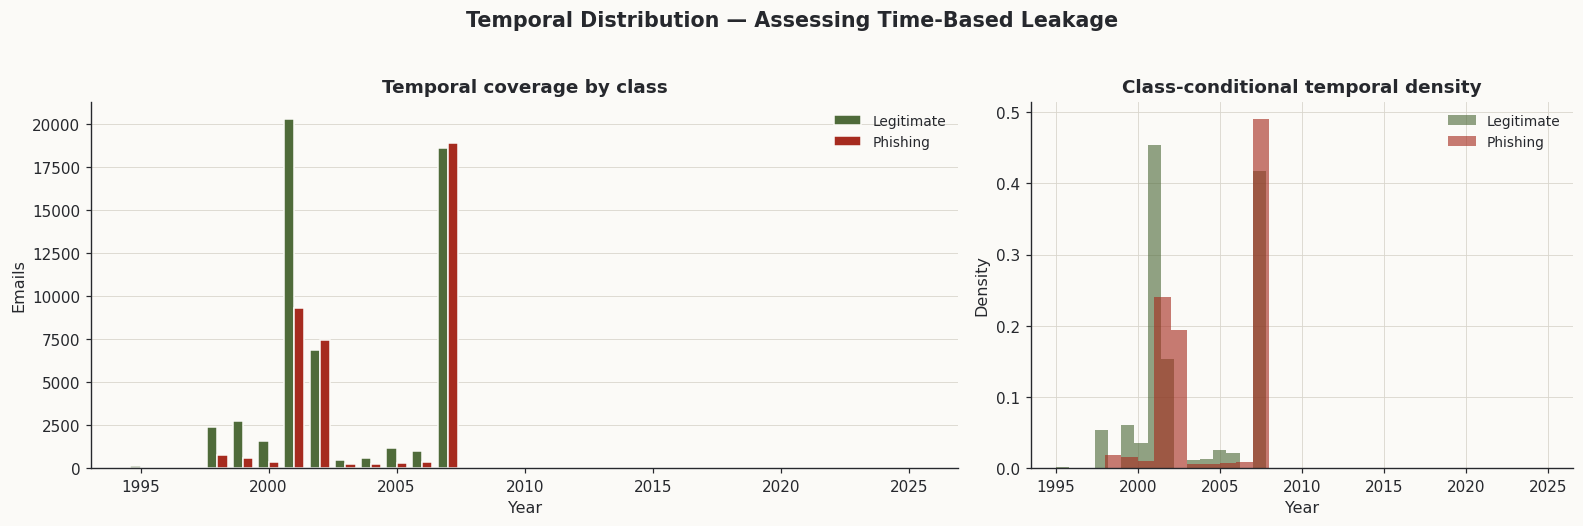


Median year — legitimate : 2002
Median year — phishing   : 2006
Separation               : 4 years

>> `date` is EXCLUDED from the feature set. A temporal split is reported in
   the limitations chapter as a further robustness test for future work.


In [16]:
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce', utc=True)
df['year'] = df['date_parsed'].dt.year

valid_dates = df['date_parsed'].notna().sum()
print(f'Parseable dates: {valid_dates:,} / {len(df):,} ({valid_dates / len(df) * 100:.1f}%)')

dated = df[df['date_parsed'].notna() & df['year'].between(1995, 2026)]
year_ct = pd.crosstab(dated['year'], dated['label']).reindex(columns=[0, 1], fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.6),
                         gridspec_kw={'width_ratios': [1.6, 1]})

# ── Left: emails per year by class ───────────────────────────────────────
ax = axes[0]
ax.bar(year_ct.index - 0.2, year_ct[0], width=0.4, color=LEGIT,
       edgecolor=PAPER, label='Legitimate')
ax.bar(year_ct.index + 0.2, year_ct[1], width=0.4, color=PHISH,
       edgecolor=PAPER, label='Phishing')
ax.set_xlabel('Year')
ax.set_ylabel('Emails')
ax.set_title('Temporal coverage by class')
ax.legend(fontsize=9)
ax.grid(axis='x', visible=False)

# ── Right: class-conditional year distribution ───────────────────────────
ax = axes[1]
for lbl in (0, 1):
    yrs = dated.loc[dated.label == lbl, 'year']
    ax.hist(yrs, bins=30, alpha=0.62, color=CLASS_COLORS[lbl],
            label=CLASS_LABELS[lbl], density=True, edgecolor='none')
ax.set_xlabel('Year')
ax.set_ylabel('Density')
ax.set_title('Class-conditional temporal density')
ax.legend(fontsize=9)

fig.suptitle('Temporal Distribution — Assessing Time-Based Leakage',
             fontsize=13.5, fontweight='bold', y=1.03)
fig.tight_layout()
savefig(fig, 'f08_temporal_coverage.png')
plt.show()

med_legit = dated.loc[dated.label == 0, 'year'].median()
med_phish = dated.loc[dated.label == 1, 'year'].median()
print(f'\nMedian year — legitimate : {med_legit:.0f}')
print(f'Median year — phishing   : {med_phish:.0f}')
print(f'Separation               : {abs(med_phish - med_legit):.0f} years')
print('\n>> `date` is EXCLUDED from the feature set. A temporal split is reported in')
print('   the limitations chapter as a further robustness test for future work.')

---
## CELL 17 — Figure 6: Sequence Length and `max_len` Selection

DistilBERT truncates at a fixed token budget, and the choice of that budget is a real
trade-off: longer sequences preserve more of the email but cost quadratic attention
time. The prior study used 256 tokens on ~200-character SMS messages, where truncation
was essentially never triggered. MEPC bodies are an order of magnitude longer, so this
decision now has consequences and must be evidenced.

A word-count proxy (`chars / 4`) is used to estimate token counts without loading the
tokenizer — Phase 2 verifies the estimate against the real DistilBERT tokenizer.

  figure saved: f09_sequence_length.png


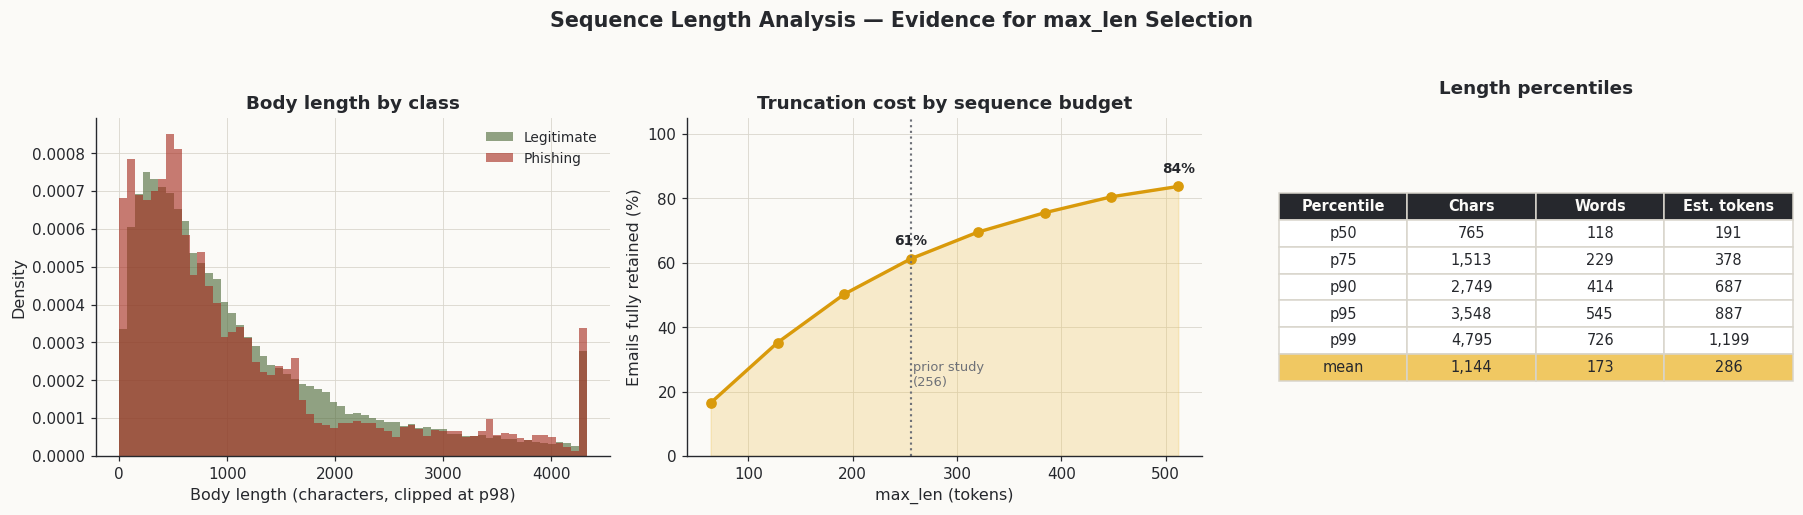


>> max_len = 256 selected.
   Untruncated coverage at this budget: 61.3% of emails.
   Coverage at 384: 75.6%   at 512: 83.7%

   This is a genuine trade-off and is reported as such rather than presented as
   lossless. Three reasons support the 256-token budget:
     (i)   Phishing lures — urgency framing, credential requests, the call to action —
           are front-loaded; the truncated tail is disproportionately quoted threads,
           signature blocks and legal footers.
     (ii)  Structural features are computed on the FULL body, so URL counts, length and
           attachment signals from the truncated region still reach the classifier.
           This is a specific advantage of the multimodal design over a text-only model.
     (iii) 512 tokens roughly doubles fine-tuning wall-clock time on a Colab T4 at this
           corpus size, which is the binding constraint on the experimental budget.

   Phase 2 retrains the baseline at 512 tokens as an ablation, so the cost of thi

In [17]:
df['body_length']    = df['body'].str.len()
df['subject_length']  = df['subject'].str.len()
df['word_count']      = df['body'].str.split().str.len().fillna(0).astype(int)
df['est_tokens']      = (df['body_length'] / 4).round().astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.5))

# ── Body length by class ─────────────────────────────────────────────────
ax = axes[0]
clip = df['body_length'].quantile(0.98)
for lbl in (0, 1):
    ax.hist(df.loc[df.label == lbl, 'body_length'].clip(upper=clip), bins=60,
            alpha=0.62, color=CLASS_COLORS[lbl], label=CLASS_LABELS[lbl],
            density=True, edgecolor='none')
ax.set_xlabel('Body length (characters, clipped at p98)')
ax.set_ylabel('Density')
ax.set_title('Body length by class')
ax.legend(fontsize=9)

# ── Truncation curve ─────────────────────────────────────────────────────
ax = axes[1]
candidates = [64, 128, 192, 256, 320, 384, 448, 512]
retained = [(df['est_tokens'] <= c).mean() * 100 for c in candidates]
ax.plot(candidates, retained, marker='o', color=AMBER, linewidth=2.2)
ax.fill_between(candidates, retained, color=AMBER_L, alpha=0.30)
ax.axvline(256, color=SLATE, linestyle=':', linewidth=1.4)
ax.text(258, 22, 'prior study\n(256)', fontsize=8.5, color=SLATE)
ax.set_xlabel('max_len (tokens)')
ax.set_ylabel('Emails fully retained (%)')
ax.set_ylim(0, 105)
ax.set_title('Truncation cost by sequence budget')
for c, r in zip(candidates, retained):
    if c in (256, 512):
        ax.annotate(f'{r:.0f}%', (c, r), textcoords='offset points',
                    xytext=(0, 9), ha='center', fontsize=9,
                    fontweight='bold', color=GRAPHITE)

# ── Length percentiles table ─────────────────────────────────────────────
ax = axes[2]
ax.axis('off')
qs = [0.50, 0.75, 0.90, 0.95, 0.99]
rows = [['Percentile', 'Chars', 'Words', 'Est. tokens']]
for q in qs:
    rows.append([f'p{int(q * 100)}',
                 f"{df['body_length'].quantile(q):,.0f}",
                 f"{df['word_count'].quantile(q):,.0f}",
                 f"{df['est_tokens'].quantile(q):,.0f}"])
rows.append(['mean',
             f"{df['body_length'].mean():,.0f}",
             f"{df['word_count'].mean():,.0f}",
             f"{df['est_tokens'].mean():,.0f}"])
tbl = ax.table(cellText=rows[1:], colLabels=rows[0], loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9.5); tbl.scale(1, 1.65)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#D8D5CC')
    if r == 0:
        cell.set_facecolor(GRAPHITE); cell.set_text_props(color=PAPER, weight='bold')
    elif r == len(rows) - 1:
        cell.set_facecolor(AMBER_L)
ax.set_title('Length percentiles', pad=16)

fig.suptitle('Sequence Length Analysis — Evidence for max_len Selection',
             fontsize=13.5, fontweight='bold', y=1.03)
fig.tight_layout()
savefig(fig, 'f09_sequence_length.png')
plt.show()

MAX_LEN = 256
cov = {c: (df['est_tokens'] <= c).mean() * 100 for c in candidates}

print(f'\n>> max_len = {MAX_LEN} selected.')
print(f'   Untruncated coverage at this budget: {cov[MAX_LEN]:.1f}% of emails.')
print(f'   Coverage at 384: {cov[384]:.1f}%   at 512: {cov[512]:.1f}%')
print()
print('   This is a genuine trade-off and is reported as such rather than presented as')
print('   lossless. Three reasons support the 256-token budget:')
print('     (i)   Phishing lures — urgency framing, credential requests, the call to action —')
print('           are front-loaded; the truncated tail is disproportionately quoted threads,')
print('           signature blocks and legal footers.')
print('     (ii)  Structural features are computed on the FULL body, so URL counts, length and')
print('           attachment signals from the truncated region still reach the classifier.')
print('           This is a specific advantage of the multimodal design over a text-only model.')
print('     (iii) 512 tokens roughly doubles fine-tuning wall-clock time on a Colab T4 at this')
print('           corpus size, which is the binding constraint on the experimental budget.')
print()
print('   Phase 2 retrains the baseline at 512 tokens as an ablation, so the cost of this')
print('   decision is measured rather than assumed.')

---

# PART D — TEXT PREPARATION AND LEXICAL ANALYSIS

Constructing the transformer input field, then establishing what a purely lexical view of the corpus reveals before any model is trained.

---

---
## CELL 18 — Model Input Field

The subject line is a first-class phishing signal — the lure often lives entirely in
it — so it is concatenated with the body behind an explicit `[SUBJ]` / `[BODY]`
marker rather than discarded or silently merged.

**Pseudonymisation tokens are deliberately preserved.** MEPC replaces personal data
with `[NAME]`, `[ORGANIZATION]`, `[URL]`, `<|PHONE|>` and similar markers. Their
*density* is informative (phishing mail addresses recipients differently from
colleague-to-colleague mail), and DistilBERT's WordPiece vocabulary handles them as
stable subword sequences. Stripping them would discard signal and create an
inconsistency between what the model reads and what the structural features measure.

In [18]:
PLACEHOLDER_RE = re.compile(
    r'\[(?:NAME|ORGANIZATION|URL|FILE_NAME|PHONE|EMAIL|DATE|LOCATION|IP|CREDIT_CARD)\]'
    r'|<\|[A-Z_]+\|>'
)

df['text'] = ('[SUBJ] ' + df['subject'].str.strip() +
              ' [BODY] ' + df['body'].str.strip()).str.strip()

df['placeholder_count']   = df['body'].str.count(PLACEHOLDER_RE)
df['placeholder_density'] = df['placeholder_count'] / df['body_length'].clip(lower=1) * 1000

print('Model input field constructed.\n')
print(f'  Mean text length : {df["text"].str.len().mean():,.0f} characters')
print(f'  Empty texts      : {int((df["text"].str.len() < 12).sum()):,}')

print('\nPlaceholder-token density (per 1,000 characters):')
print(df.groupby('label')['placeholder_density'].agg(['mean', 'median']).round(3)
        .rename(index=CLASS_LABELS).to_string())

print('\n--- SAMPLE: legitimate ---')
print(df.loc[df.label == 0, 'text'].iloc[0][:340], '...')
print('\n--- SAMPLE: phishing ---')
print(df.loc[df.label == 1, 'text'].iloc[0][:340], '...')

Model input field constructed.

  Mean text length : 1,201 characters
  Empty texts      : 0

Placeholder-token density (per 1,000 characters):
              mean  median
label                     
Legitimate  10.672   8.865
Phishing    10.112   4.754

--- SAMPLE: legitimate ---
[SUBJ] [ORGANIZATION] failover plan. [BODY] Hi [NAME], 

Tonight we are rolling out a new report. Currently, only you and [NAME] have access to it. You'll select it off the main reports menu. It will say "[ORGANIZATION] Download report". When you launch it, it will show the data on screen like all other reports. There is a button at the b ...

--- SAMPLE: phishing ---
[SUBJ] ÀÎÅÍ<|SIMBOL|>Ý Ä<|SIMBOL|><|SIMBOL|>å<|SIMBOL|>ç)<|SIMBOL|>ð<|SIMBOL|>ç Ä<|SIMBOL|><|SIMBOL|>å <|SIMBOL|>ëÃâ <|SIMBOL|>Ó <|SIMBOL|>Ã<|SIMBOL|>øÈ÷ <|SIMBOL|><|SIMBOL|><|SIMBOL|>AE<|SIMBOL|>å<|SIMBOL|><|SIMBOL|><|SIMBOL|>Ï<|SIMBOL|>Ù!Àå<|SIMBOL|>â<|SIMBOL|>óÈ<|SIMBOL|>@ iqtmswligeqlftglh [BODY] <|EMOJI|>FFFFB9<|EMOJI|>FFFFCF<|EMOJI| ...


---
## CELL 19 — Lexical Signal: Discriminative Tokens

Before any model is trained, it is worth establishing what a purely lexical view of the
corpus looks like. The tokens most associated with each class are extracted using the
**weighted log-odds ratio with an informative Dirichlet prior** (Monroe, Colaresi and
Quinn, 2008) rather than raw frequency.

The distinction matters. Raw frequency returns stopwords. A plain log-odds ratio returns
hapaxes — tokens appearing three times in one class and never in the other, which look
maximally discriminative and are pure noise. The Dirichlet-prior variant regularises
each token by its corpus-wide frequency and yields a z-score, so common *and*
discriminative tokens rise to the top and rare accidents are suppressed.

Fitting lexical model (this takes 60-90 seconds)...
Lexical analysis complete in 17.5s  (vocabulary: 16,199 tokens, min_df=25)
  figure saved: f10_lexical_log_odds.png


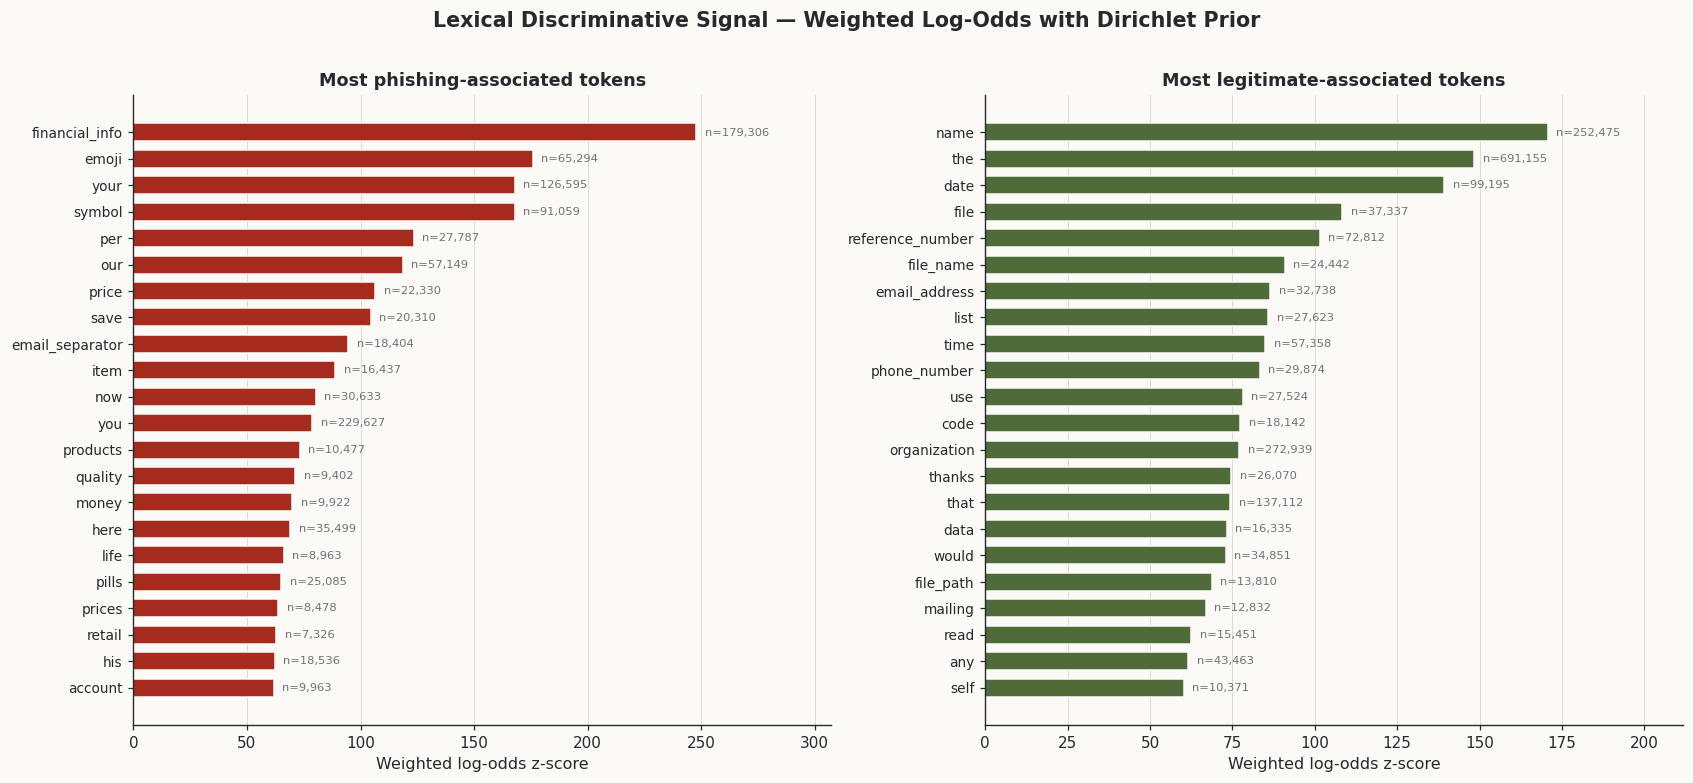


Top 12 phishing tokens  : financial_info, emoji, your, symbol, per, our, price, save, email_separator, item, now, you
Top 12 legitimate tokens: name, the, date, file, reference_number, file_name, email_address, list, time, phone_number, use, code

>> These tokens form the qualitative expectation against which Phase 2 LIME
   explanations are checked. Agreement is a consistency signal; divergence means
   the transformer has found contextual structure a bag-of-words view cannot see.


24

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

t0 = time.time()
print('Fitting lexical model (this takes 60-90 seconds)...')

vec = CountVectorizer(lowercase=True, min_df=25, max_features=40000,
                      dtype=np.int32,
                      token_pattern=r'(?u)\b[a-z][a-z0-9_]{2,}\b',
                      stop_words=None)
X_counts = vec.fit_transform(df['text'].str.lower())
vocab = np.array(vec.get_feature_names_out())

y = df['label'].values
c_phish = np.asarray(X_counts[y == 1].sum(axis=0)).ravel().astype(float)
c_legit = np.asarray(X_counts[y == 0].sum(axis=0)).ravel().astype(float)
c_all   = c_phish + c_legit

# Informative Dirichlet prior: alpha proportional to corpus frequency
a0    = 500.0
alpha = a0 * c_all / c_all.sum()
n_p, n_l = c_phish.sum(), c_legit.sum()

odds_p = (c_phish + alpha) / (n_p + a0 - c_phish - alpha)
odds_l = (c_legit + alpha) / (n_l + a0 - c_legit - alpha)
delta  = np.log(odds_p) - np.log(odds_l)
var    = 1.0 / (c_phish + alpha) + 1.0 / (c_legit + alpha)
zscore = delta / np.sqrt(var)

lex = pd.DataFrame({'token': vocab, 'z': zscore, 'n_phish': c_phish.astype(int),
                    'n_legit': c_legit.astype(int), 'n_total': c_all.astype(int)})

top_phish = lex.nlargest(22, 'z')
top_legit = lex.nsmallest(22, 'z')

print(f'Lexical analysis complete in {time.time() - t0:.1f}s  '
      f'(vocabulary: {len(vocab):,} tokens, min_df=25)')

fig, axes = plt.subplots(1, 2, figsize=(15.5, 7))

for ax, tbl, colour, title in [
    (axes[0], top_phish.iloc[::-1], PHISH, 'Most phishing-associated tokens'),
    (axes[1], top_legit.iloc[::-1].assign(z=lambda t: -t['z']), LEGIT,
     'Most legitimate-associated tokens'),
]:
    ax.barh(tbl['token'], tbl['z'], color=colour, edgecolor=PAPER, height=0.68)
    for i, (_, r) in enumerate(tbl.iterrows()):
        ax.text(r['z'] + tbl['z'].max() * 0.015, i, f"n={int(r['n_total']):,}",
                va='center', fontsize=7.5, color=SLATE)
    ax.set_xlim(0, tbl['z'].max() * 1.24)
    ax.set_xlabel('Weighted log-odds z-score')
    ax.set_title(title, fontsize=11.5)
    ax.tick_params(axis='y', labelsize=9)
    ax.grid(axis='y', visible=False)

fig.suptitle('Lexical Discriminative Signal — Weighted Log-Odds with Dirichlet Prior',
             fontsize=13.5, fontweight='bold', y=1.01)
fig.tight_layout()
savefig(fig, 'f10_lexical_log_odds.png')
plt.show()

lex.nlargest(60, 'z').to_csv(PREP_DIR + 'table_top_tokens_phishing.csv', index=False)
lex.nsmallest(60, 'z').to_csv(PREP_DIR + 'table_top_tokens_legitimate.csv', index=False)

print('\nTop 12 phishing tokens  :', ', '.join(top_phish['token'].head(12)))
print('Top 12 legitimate tokens:', ', '.join(top_legit['token'].head(12)))
print('\n>> These tokens form the qualitative expectation against which Phase 2 LIME')
print('   explanations are checked. Agreement is a consistency signal; divergence means')
print('   the transformer has found contextual structure a bag-of-words view cannot see.')

del X_counts, vec
gc.collect()

---
## CELL 20 — Subject-Line and Social-Engineering Cue Analysis

The subject line is where the lure is compressed. It is also where the classic
social-engineering levers are most visible: manufactured urgency, authority claims,
reward promises and threat of loss.

A hand-specified lexicon is used rather than a learned one, for a deliberate reason —
these categories map onto the persuasion principles that the security-awareness
literature already names, so the resulting features are explainable to a non-technical
auditor in a way that a learned n-gram is not.

=== SOCIAL-ENGINEERING CUE PREVALENCE ===

           Legitimate  Phishing  Lift
Urgency         26.07     32.13  1.23
Authority        5.47      9.58  1.75
Reward          11.97     18.48  1.54
Threat           5.15      3.35  0.65
Action          12.61     16.06  1.27
  figure saved: f11_social_engineering_cues.png


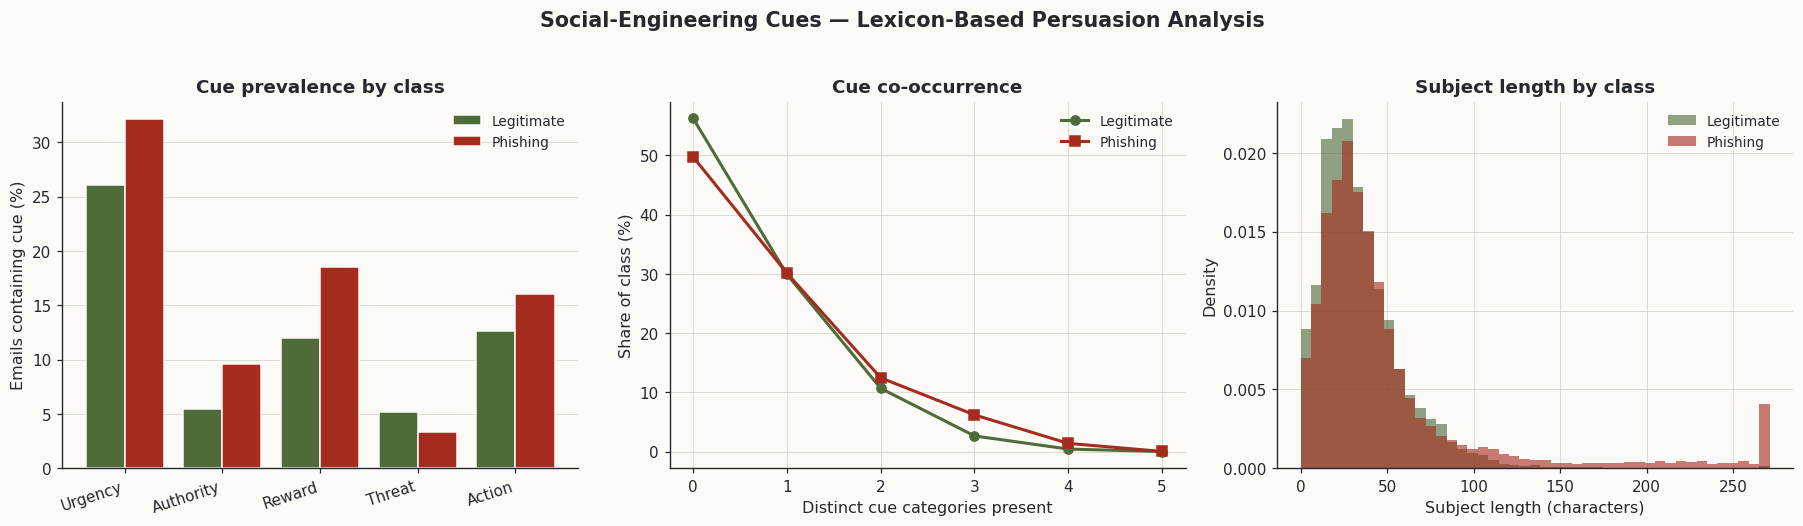


Mean cues per email — legitimate 0.61, phishing 0.80


In [20]:
CUE_LEXICON = {
    'urgency':   r'\b(urgent|immediate(ly)?|expir(e|es|ed|ing)|deadline|asap|now|today|'
                 r'final|last chance|act fast|hurry|limited time|within \d+ ?(hours?|days?))\b',
    'authority': r'\b(security|administrator|admin|it ?department|helpdesk|support team|'
                 r'compliance|official|bank|paypal|microsoft|apple|amazon|irs|hmrc)\b',
    'reward':    r'\b(congratulation|winner|won|prize|reward|bonus|free|gift|claim|'
                 r'lottery|inherit(ance)?|million)\b',
    'threat':    r'\b(suspend(ed)?|lock(ed)?|block(ed)?|disabl(e|ed)|terminat(e|ed)|'
                 r'unauthori[sz]ed|breach|violat(e|ion)|penalty|legal action|closed)\b',
    'action':    r'\b(verify|confirm|validate|update|click|log ?in|sign ?in|activate|'
                 r'restore|review your|re-?enter)\b',
}

subj_l = df['subject'].str.lower()
body_l = df['body'].str.lower()

cue_cols = []
for cue, pattern in CUE_LEXICON.items():
    col = f'cue_{cue}'
    df[col] = (subj_l.str.contains(pattern, regex=True, na=False) |
               body_l.str.contains(pattern, regex=True, na=False)).astype(int)
    cue_cols.append(col)

df['cue_total'] = df[cue_cols].sum(axis=1)
df['subject_upper_ratio'] = df['subject'].map(
    lambda s: (sum(1 for c in s if c.isupper()) / max(sum(1 for c in s if c.isalpha()), 1)))
df['subject_has_re_fw'] = subj_l.str.match(r'^\s*(re|fw|fwd)\s*:').fillna(False).astype(int)

rates = df.groupby('label')[cue_cols].mean().T
rates.columns = [CLASS_LABELS[c] for c in rates.columns]
rates.index = [c.replace('cue_', '').title() for c in rates.index]
rates['Lift'] = (rates['Phishing'] / rates['Legitimate'].replace(0, np.nan)).round(2)

print('=== SOCIAL-ENGINEERING CUE PREVALENCE ===\n')
print((rates * [100, 100, 1]).round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.6))

ax = axes[0]
x = np.arange(len(rates))
ax.bar(x - 0.2, rates['Legitimate'] * 100, width=0.4, color=LEGIT,
       edgecolor=PAPER, label='Legitimate')
ax.bar(x + 0.2, rates['Phishing'] * 100, width=0.4, color=PHISH,
       edgecolor=PAPER, label='Phishing')
ax.set_xticks(x); ax.set_xticklabels(rates.index, rotation=18, ha='right')
ax.set_ylabel('Emails containing cue (%)')
ax.set_title('Cue prevalence by class')
ax.legend(fontsize=9)
ax.grid(axis='x', visible=False)

ax = axes[1]
cue_dist = pd.crosstab(df['cue_total'], df['label'], normalize='columns') * 100
ax.plot(cue_dist.index, cue_dist[0], marker='o', color=LEGIT,
        linewidth=2, label='Legitimate')
ax.plot(cue_dist.index, cue_dist[1], marker='s', color=PHISH,
        linewidth=2, label='Phishing')
ax.set_xlabel('Distinct cue categories present')
ax.set_ylabel('Share of class (%)')
ax.set_title('Cue co-occurrence')
ax.legend(fontsize=9)

ax = axes[2]
clip = df['subject_length'].quantile(0.99)
for lbl in (0, 1):
    ax.hist(df.loc[df.label == lbl, 'subject_length'].clip(upper=clip), bins=45,
            alpha=0.62, color=CLASS_COLORS[lbl], density=True,
            edgecolor='none', label=CLASS_LABELS[lbl])
ax.set_xlabel('Subject length (characters)')
ax.set_ylabel('Density')
ax.set_title('Subject length by class')
ax.legend(fontsize=9)

fig.suptitle('Social-Engineering Cues — Lexicon-Based Persuasion Analysis',
             fontsize=13.5, fontweight='bold', y=1.03)
fig.tight_layout()
savefig(fig, 'f11_social_engineering_cues.png')
plt.show()

rates.to_csv(PREP_DIR + 'table_cue_prevalence.csv')
print(f'\nMean cues per email — legitimate {df.loc[df.label == 0, "cue_total"].mean():.2f}, '
      f'phishing {df.loc[df.label == 1, "cue_total"].mean():.2f}')

---

# PART E — STRUCTURAL FEATURE ENGINEERING

Thirteen core interpretable features, extended to twenty-one through URL forensics and social-engineering cue analysis.

---

---
## CELL 21 — Structural Feature Engineering

Thirteen features, every one of them named and interpretable. This is a direct
correction of a weakness in the prior study, where seven of the thirteen features were
unnamed `struct_f7`–`struct_f13` placeholders that contributed nothing and could not
be discussed in the explainability analysis.

**Five URL features come from the corpus itself.** MEPC ships pre-computed URL
descriptors — count, maximum and mean length, maximum and mean subdomain depth. These
are exactly the signals that were dead weight in the SMS corpus (where URLs barely
occurred) and they are the strongest structural discriminators here: the corpus
contains 346,525 URLs, and phishing mail averages 4.4 per message against 2.7 for
legitimate mail.

| # | Feature | Type | Source | Hypothesis |
|:--|:--|:--|:--|:--|
| 1 | `url_count` | int | corpus | Phishing needs a click target |
| 2 | `url_length_max` | int | corpus | Obfuscated / redirect URLs run long |
| 3 | `url_length_avg` | float | corpus | Campaign-wide URL style |
| 4 | `url_subdom_max` | int | corpus | Deep nesting disguises the true host |
| 5 | `url_subdom_avg` | float | corpus | Sustained nesting across all links |
| 6 | `uppercase_ratio` | float | derived | Urgency and shouting |
| 7 | `punct_density` | float | derived | `!!!`, `$$$`, irregular emphasis |
| 8 | `digit_count` | int | derived | Amounts, deadlines, account numbers |
| 9 | `currency_flag` | binary | derived | Monetary lure |
| 10 | `html_flag` | binary | `content_types` | Campaign formatting |
| 11 | `body_length` | int | derived | Length regime differs by class |
| 12 | `subject_length` | int | derived | Lure lines have a characteristic length |
| 13 | `attachment_count` | int | corpus | Payload delivery |

**Placeholder masking.** Features 6–9 are computed on the body *after* pseudonymisation
tokens are removed. Without this, `[ORGANIZATION]` would inflate `uppercase_ratio` and
`<|PHONE|>` would inflate `punct_density` — the model would be measuring the anonymiser,
not the sender.

In [21]:
CURRENCY_RE = re.compile(r'[$£€¥₹¢₽]|\b(?:usd|eur|gbp|dollars?|euros?|pounds?)\b', re.I)
EMPHASIS    = set('!?$%&*#@')

t0 = time.time()
print('Engineering structural features...')

# ── Mask placeholders once; reused by features 6-9 ───────────────────────
masked = df['body'].map(lambda s: PLACEHOLDER_RE.sub(' ', s))

def _uppercase_ratio(s):
    letters = [c for c in s if c.isalpha()]
    if not letters:
        return 0.0
    return sum(1 for c in letters if c.isupper()) / len(letters)

def _punct_density(s):
    if not s:
        return 0.0
    return sum(1 for c in s if c in EMPHASIS) / len(s)

df['uppercase_ratio'] = masked.map(_uppercase_ratio)
df['punct_density']   = masked.map(_punct_density)
df['digit_count']     = masked.str.count(r'\d')
df['currency_flag']   = masked.str.contains(CURRENCY_RE).astype(int)

# ── HTML from the declared MIME parts (more reliable than tag-sniffing) ──
df['html_flag'] = df['content_types'].str.contains('text/html', case=False,
                                                    na=False).astype(int)

# body_length and subject_length were computed in Cell 14.
# url_* and attachment_count arrived with the corpus and were coerced in Cell 7.

missing = [f for f in STRUCT_FEATURES if f not in df.columns]
assert not missing, f'Missing engineered features: {missing}'

df[STRUCT_FEATURES] = df[STRUCT_FEATURES].astype(float).fillna(0.0)
assert np.isfinite(df[STRUCT_FEATURES].values).all(), 'Non-finite values in feature matrix'

print(f'{N_STRUCT} structural features engineered in {time.time() - t0:.1f}s')

del masked
gc.collect()

print('\n=== FEATURE MEANS BY CLASS ===\n')
summary = df.groupby('label')[STRUCT_FEATURES].mean().T
summary.columns = [CLASS_LABELS[c] for c in summary.columns]
summary['ratio (P/L)'] = (summary['Phishing'] /
                          summary['Legitimate'].replace(0, np.nan)).round(2)
print(summary.round(3).to_string())

Engineering structural features...
13 structural features engineered in 27.3s

=== FEATURE MEANS BY CLASS ===

                  Legitimate  Phishing  ratio (P/L)
url_count              2.623     4.368         1.67
url_length_max        22.977    50.598         2.20
url_length_avg        18.766    39.616         2.11
url_subdom_max         0.509     0.899         1.77
url_subdom_avg         0.457     0.758         1.66
uppercase_ratio        0.143     0.174         1.22
punct_density          0.004     0.006         1.49
digit_count           11.926    12.115         1.02
currency_flag          0.093     0.137         1.48
html_flag              0.074     0.722         9.71
body_length         1151.012  1133.898         0.99
subject_length        35.336    52.243         1.48
attachment_count       0.035     0.013         0.38


---
## CELL 22 — URL Forensics

The corpus ships five aggregate URL descriptors, but retains the raw URL strings as
well. Those strings support a finer analysis, and it is worth doing because Cell 19
identified the URL block as the strongest structural signal in the corpus.

Six forensic indicators are derived, each corresponding to a documented obfuscation
technique:

| Indicator | Technique it detects |
|:--|:--|
| `url_has_ip` | Bare IP host — bypasses domain reputation entirely |
| `url_at_symbol` | `user@host` authority trick — the visible part is not the destination |
| `url_punycode` | `xn--` homograph domains impersonating a brand |
| `url_shortener` | Redirection service concealing the final destination |
| `url_distinct_domains` | Link farms and mixed-destination campaigns |
| `url_https_ratio` | Transport-security posture of the linked infrastructure |

Extracting URL forensic indicators...
URL forensics complete in 2.2s
  figure saved: f12_url_forensics.png


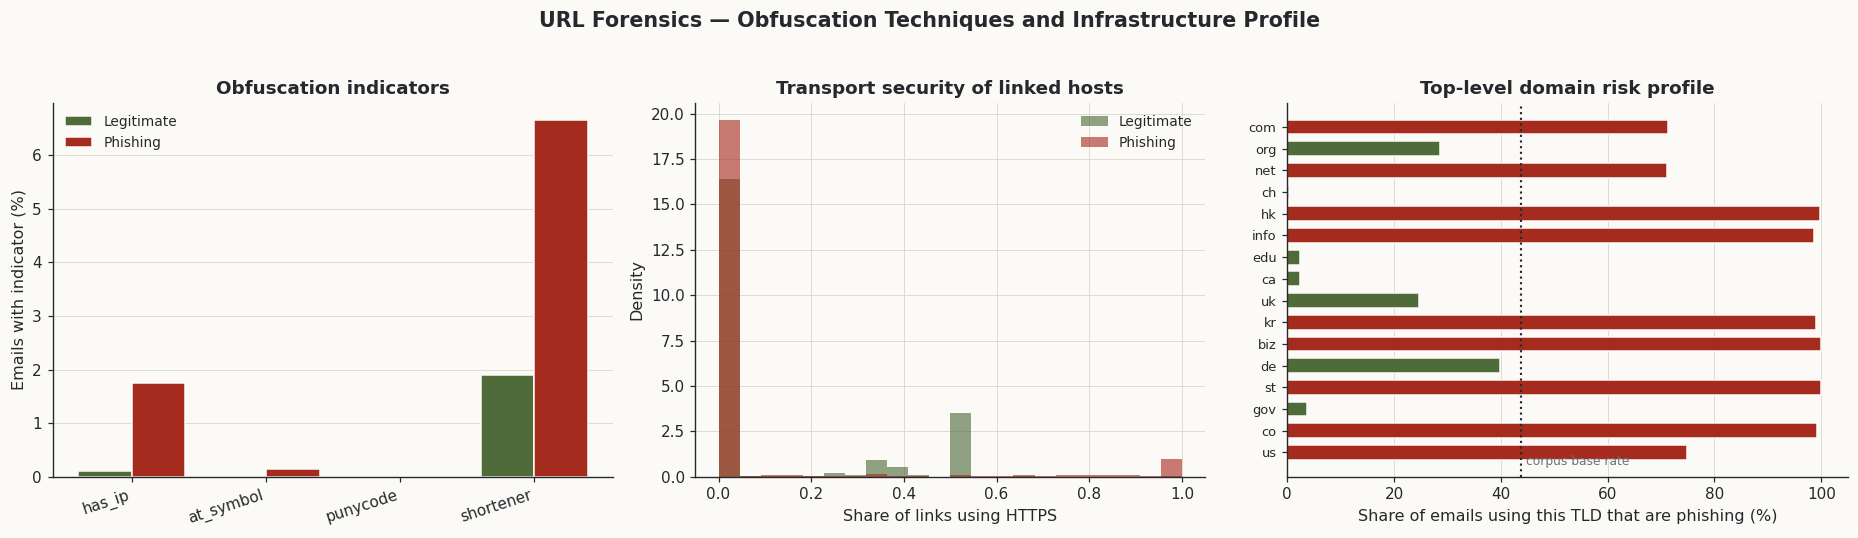


=== URL FORENSIC INDICATOR RATES ===

                      Legitimate  Phishing   Lift
url_has_ip                0.0010    0.0174  16.83
url_at_symbol             0.0002    0.0014   7.59
url_punycode              0.0000    0.0000    NaN
url_shortener             0.0190    0.0665   3.50
url_distinct_domains      0.7569    1.3768   1.82
url_https_ratio           0.0469    0.0640   1.37


In [22]:
SHORTENERS = ('bit.ly', 'tinyurl', 'goo.gl', 't.co', 'ow.ly', 'is.gd', 'buff.ly',
              'adf.ly', 'bitly.com', 'cutt.ly', 'rebrand.ly', 'shorturl', 'tiny.cc',
              'rb.gy', 'lnkd.in')
IP_HOST_RE  = re.compile(r'https?://(?:[^@/\s]*@)?(\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3})')
HOST_RE     = re.compile(r'https?://([^/\s:?#]+)', re.I)

t0 = time.time()
print('Extracting URL forensic indicators...')

def url_forensics(raw):
    if not isinstance(raw, str) or not raw.strip():
        return (0, 0, 0, 0, 0, 0.0)
    urls  = [u for u in re.split(r'[\s,;]+', raw) if u.lower().startswith('http')]
    if not urls:
        return (0, 0, 0, 0, 0, 0.0)
    hosts = [m.group(1).lower() for m in (HOST_RE.match(u) for u in urls) if m]
    return (
        int(any(IP_HOST_RE.match(u) for u in urls)),
        int(any('@' in u.split('://', 1)[-1].split('/', 1)[0] for u in urls)),
        int(any('xn--' in h for h in hosts)),
        int(any(any(s in h for s in SHORTENERS) for h in hosts)),
        len({'.'.join(h.split('.')[-2:]) for h in hosts}),
        sum(1 for u in urls if u.lower().startswith('https')) / len(urls),
    )

forensics = np.array([url_forensics(u) for u in df['urls'].fillna('')], dtype=float)
for i, name in enumerate(['url_has_ip', 'url_at_symbol', 'url_punycode',
                          'url_shortener', 'url_distinct_domains', 'url_https_ratio']):
    df[name] = forensics[:, i]

print(f'URL forensics complete in {time.time() - t0:.1f}s')

URL_FORENSIC = ['url_has_ip', 'url_at_symbol', 'url_punycode',
                'url_shortener', 'url_distinct_domains', 'url_https_ratio']

# ── TLD profile ──────────────────────────────────────────────────────────
TLD_RE = re.compile(r'^[a-z]{2,24}$')

def tlds(raw):
    """Extract the TLD of every linked host.

    Raw URL strings in the corpus carry trailing quotes, brackets and stray
    punctuation from the original MIME parts, which would otherwise produce
    junk labels such as `com"` alongside the genuine `com`. Candidates are
    therefore stripped and validated against an alphabetic TLD pattern.
    """
    if not isinstance(raw, str):
        return []
    out = []
    for m in HOST_RE.finditer(raw):
        host = m.group(1).lower().strip('\'"<>(),;[]')
        if '.' not in host:
            continue
        tld = host.rsplit('.', 1)[-1]
        if TLD_RE.match(tld):
            out.append(tld)
    return out

tld_phish = Counter()
tld_legit = Counter()
for raw, lbl in zip(df['urls'].fillna(''), df['label']):
    (tld_phish if lbl == 1 else tld_legit).update(set(tlds(raw)))

tld_df = pd.DataFrame({'phishing': pd.Series(tld_phish),
                       'legitimate': pd.Series(tld_legit)}).fillna(0)
tld_df['total'] = tld_df.sum(axis=1)
tld_df = tld_df[tld_df['total'] >= 60]
tld_df['phish_share'] = tld_df['phishing'] / tld_df['total']
tld_df = tld_df.sort_values('total', ascending=False).head(16)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.7),
                         gridspec_kw={'width_ratios': [1.1, 1, 1.1]})

ax = axes[0]
ind = pd.DataFrame({
    'Legitimate': [df.loc[df.label == 0, c].mean() * 100 for c in URL_FORENSIC[:4]],
    'Phishing':   [df.loc[df.label == 1, c].mean() * 100 for c in URL_FORENSIC[:4]],
}, index=[c.replace('url_', '') for c in URL_FORENSIC[:4]])
x = np.arange(len(ind))
ax.bar(x - 0.2, ind['Legitimate'], width=0.4, color=LEGIT, edgecolor=PAPER, label='Legitimate')
ax.bar(x + 0.2, ind['Phishing'],   width=0.4, color=PHISH, edgecolor=PAPER, label='Phishing')
ax.set_xticks(x); ax.set_xticklabels(ind.index, rotation=18, ha='right')
ax.set_ylabel('Emails with indicator (%)')
ax.set_title('Obfuscation indicators')
ax.legend(fontsize=9)
ax.grid(axis='x', visible=False)

ax = axes[1]
for lbl in (0, 1):
    v = df.loc[(df.label == lbl) & (df.url_count > 0), 'url_https_ratio']
    ax.hist(v, bins=22, alpha=0.62, color=CLASS_COLORS[lbl], density=True,
            edgecolor='none', label=CLASS_LABELS[lbl])
ax.set_xlabel('Share of links using HTTPS')
ax.set_ylabel('Density')
ax.set_title('Transport security of linked hosts')
ax.legend(fontsize=9)

ax = axes[2]
sub = tld_df.iloc[::-1]
ax.barh(sub.index, sub['phish_share'] * 100, color=[
    PHISH if v > 0.5 else LEGIT for v in sub['phish_share']],
    edgecolor=PAPER, height=0.68)
ax.axvline(df['label'].mean() * 100, color=GRAPHITE, linestyle=':', linewidth=1.4)
ax.text(df['label'].mean() * 100 + 1, -0.6, 'corpus base rate', fontsize=8, color=SLATE)
ax.set_xlabel('Share of emails using this TLD that are phishing (%)')
ax.set_title('Top-level domain risk profile')
ax.tick_params(axis='y', labelsize=8.5)
ax.grid(axis='y', visible=False)

fig.suptitle('URL Forensics — Obfuscation Techniques and Infrastructure Profile',
             fontsize=13.5, fontweight='bold', y=1.03)
fig.tight_layout()
savefig(fig, 'f12_url_forensics.png')
plt.show()

print('\n=== URL FORENSIC INDICATOR RATES ===\n')
frates = df.groupby('label')[URL_FORENSIC].mean().T
frates.columns = [CLASS_LABELS[c] for c in frates.columns]
frates['Lift'] = (frates['Phishing'] / frates['Legitimate'].replace(0, np.nan)).round(2)
print(frates.round(4).to_string())
frates.to_csv(PREP_DIR + 'table_url_forensics.csv')
tld_df.to_csv(PREP_DIR + 'table_tld_profile.csv')

---
## CELL 23 — Extended Feature Set

The analyses above produced eight further interpretable indicators. Rather than silently
folding them into the core set, two feature matrices are maintained and both are saved:

- **Core (13)** — the set declared in Cell 2, directly comparable with the prior study's
  781-dimensional fusion.
- **Extended (21)** — core plus the six URL forensic indicators, subject capitalisation
  and the social-engineering cue count.

Phase 2 trains on both. If the extended set does not beat the core set, that is a
reportable negative result about the marginal value of hand-crafted forensic features
once a transformer is already reading the text — a more interesting finding than
quietly using whichever performs better.

In [23]:
EXTENDED_EXTRA = URL_FORENSIC + ['subject_upper_ratio', 'cue_total']
STRUCT_FEATURES_EXT = STRUCT_FEATURES + EXTENDED_EXTRA
N_STRUCT_EXT = len(STRUCT_FEATURES_EXT)

df[STRUCT_FEATURES_EXT] = df[STRUCT_FEATURES_EXT].astype(float).fillna(0.0)
assert np.isfinite(df[STRUCT_FEATURES_EXT].values).all(), 'Non-finite values in extended matrix'

print(f'Core feature set     : {N_STRUCT} features')
print(f'Extended feature set : {N_STRUCT_EXT} features (+{len(EXTENDED_EXTRA)})')
print(f'\nAdditional features: {", ".join(EXTENDED_EXTRA)}')

print('\n=== EXTENDED FEATURE MEANS BY CLASS ===\n')
ext_summary = df.groupby('label')[EXTENDED_EXTRA].mean().T
ext_summary.columns = [CLASS_LABELS[c] for c in ext_summary.columns]
ext_summary['ratio (P/L)'] = (ext_summary['Phishing'] /
                              ext_summary['Legitimate'].replace(0, np.nan)).round(2)
print(ext_summary.round(4).to_string())

# ── Release raw columns that have now been fully consumed ────────────────
# `urls`, `content_types` and the hashed identity fields were needed for feature
# extraction and auditing but are excluded from modelling. Dropping them here
# keeps peak memory down during the sparse-matrix work in Part H.
CONSUMED = ['urls', 'content_types', 'exact_hash', 'sender', 'receiver',
            'receiver_domain', 'date', 'has_attachments', 'language',
            'lang_n_parts', 'date_parsed']
dropped = [c for c in CONSUMED if c in df.columns]
df = df.drop(columns=dropped)
gc.collect()
print(f'\nReleased {len(dropped)} consumed column(s): {", ".join(dropped)}')
print(f'DataFrame memory now: {df.memory_usage(deep=True).sum() / 1024**2:,.0f} MB')

print(f'\nFusion dimensionality for Phase 2:')
print(f'  DistilBERT embedding          768')
print(f'  + core structural             {N_STRUCT:>3}   ->  {768 + N_STRUCT} dimensions')
print(f'  + extended structural         {N_STRUCT_EXT:>3}   ->  {768 + N_STRUCT_EXT} dimensions')

Core feature set     : 13 features
Extended feature set : 21 features (+8)

Additional features: url_has_ip, url_at_symbol, url_punycode, url_shortener, url_distinct_domains, url_https_ratio, subject_upper_ratio, cue_total

=== EXTENDED FEATURE MEANS BY CLASS ===

                      Legitimate  Phishing  ratio (P/L)
url_has_ip                0.0010    0.0174        16.83
url_at_symbol             0.0002    0.0014         7.59
url_punycode              0.0000    0.0000          NaN
url_shortener             0.0190    0.0665         3.50
url_distinct_domains      0.7569    1.3768         1.82
url_https_ratio           0.0469    0.0640         1.37
subject_upper_ratio       0.3464    0.2868         0.83
cue_total                 0.6126    0.7961         1.30

Released 11 consumed column(s): urls, content_types, exact_hash, sender, receiver, receiver_domain, date, has_attachments, language, lang_n_parts, date_parsed
DataFrame memory now: 311 MB

Fusion dimensionality for Phase 2:
  Dist

---
## CELL 24 — Figure 7: Structural Feature Distributions by Class

Visual confirmation that each feature separates the classes — and, equally useful,
identification of the features that do not. Any feature whose two class distributions
sit on top of each other is a candidate for pruning, and Phase 2's ablation study
tests exactly that by retraining rather than by inferring it from SHAP.

  figure saved: f13_feature_distributions.png


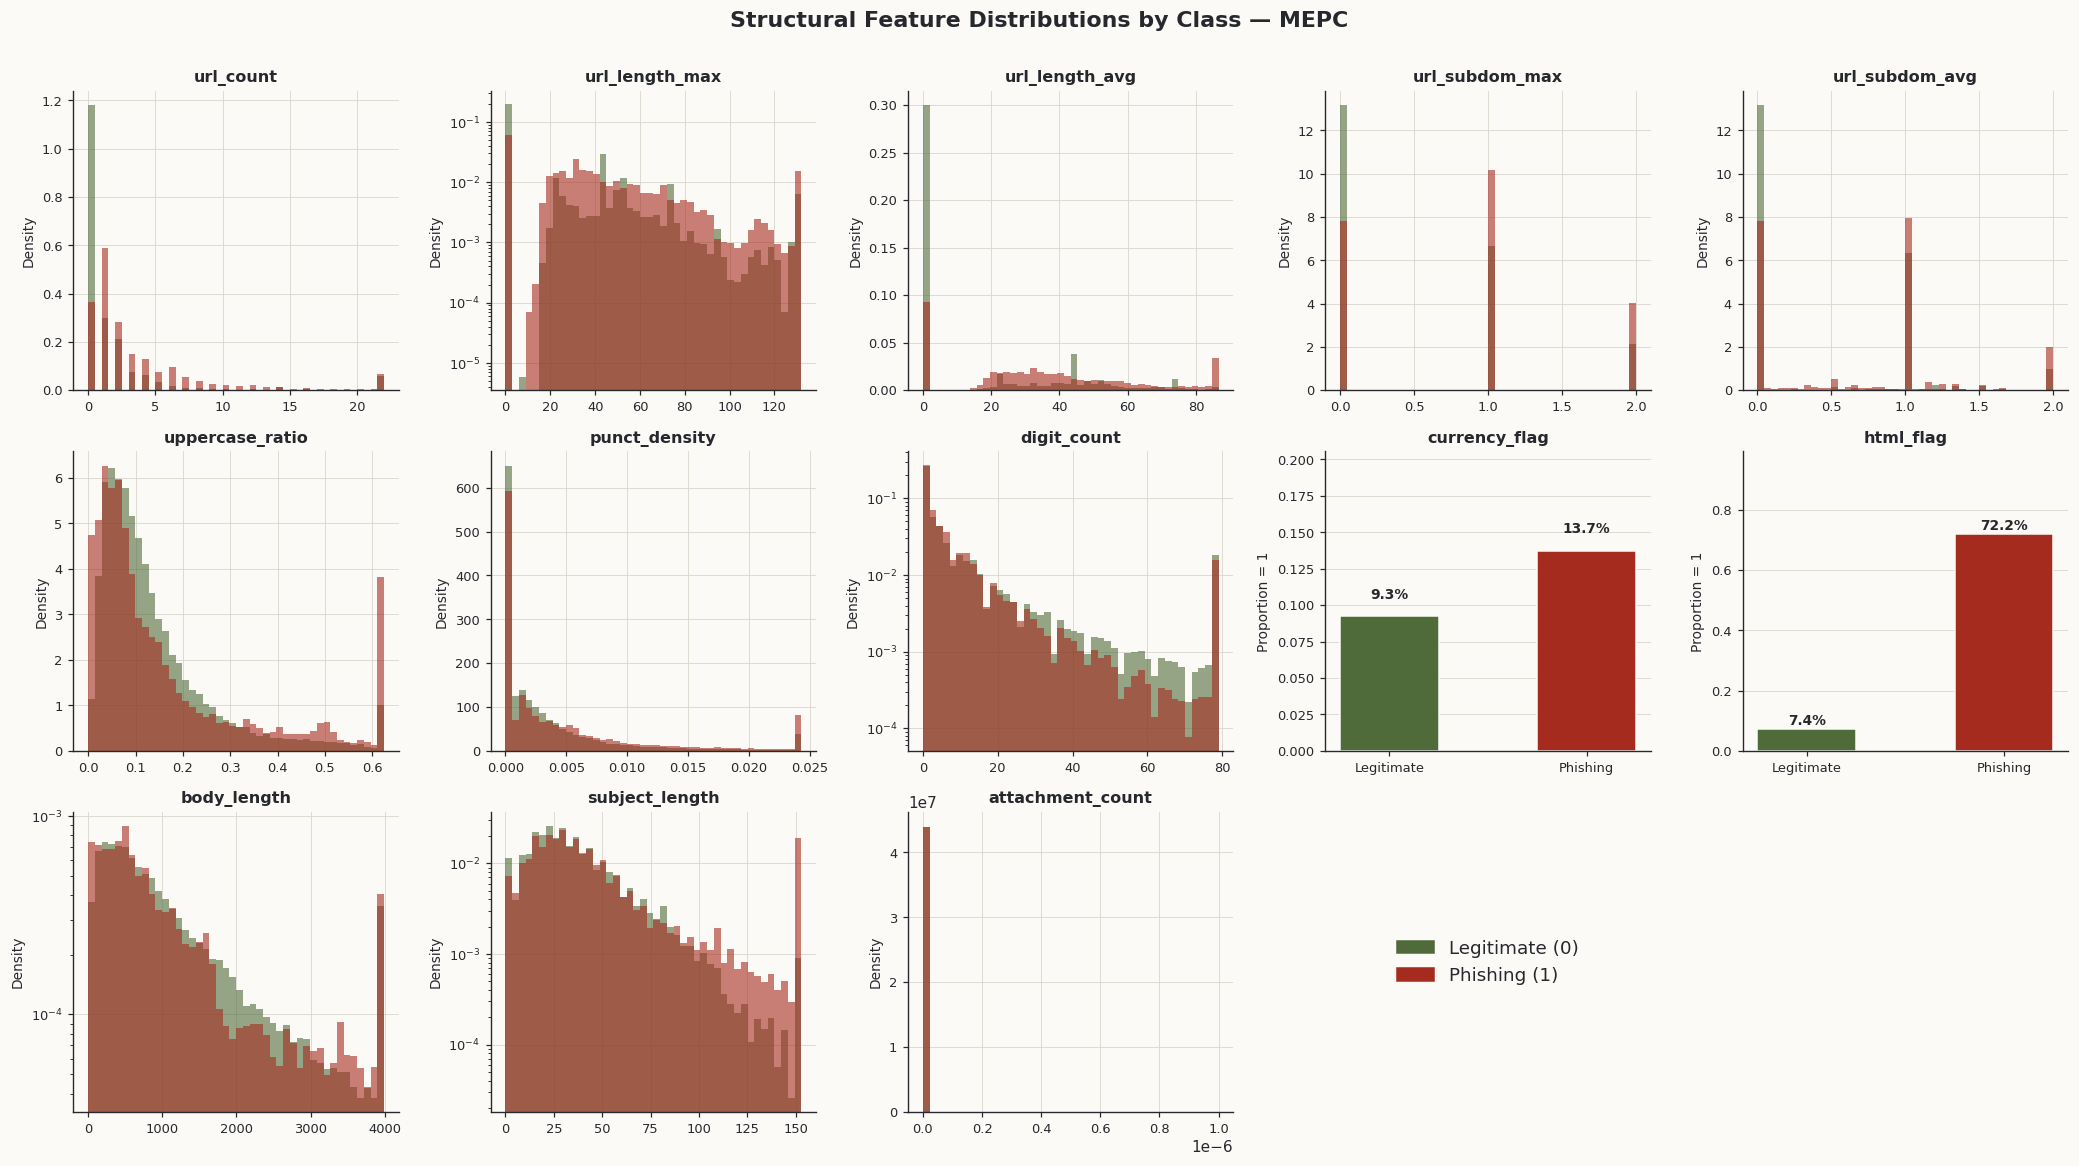

In [24]:
fig, axes = plt.subplots(3, 5, figsize=(19, 10.5))
axes = axes.ravel()

LOG_FEATURES = {'body_length', 'digit_count', 'url_length_max', 'subject_length'}

for i, feat in enumerate(STRUCT_FEATURES):
    ax = axes[i]
    v0 = df.loc[df.label == 0, feat]
    v1 = df.loc[df.label == 1, feat]

    if df[feat].nunique() <= 2:                       # binary flags
        props = [[(v == 1).mean() for v in (v0, v1)]]
        ax.bar([CLASS_LABELS[0], CLASS_LABELS[1]], props[0],
               color=[LEGIT, PHISH], edgecolor=PAPER, width=0.5)
        for x, p in enumerate(props[0]):
            ax.text(x, p + 0.012, f'{p:.1%}', ha='center', fontsize=9,
                    fontweight='bold', color=GRAPHITE)
        ax.set_ylim(0, max(props[0]) * 1.35 + 0.02)
        ax.set_ylabel('Proportion = 1', fontsize=9)
        ax.grid(axis='x', visible=False)
    else:
        hi = df[feat].quantile(0.97)
        bins = np.linspace(df[feat].min(), max(hi, df[feat].min() + 1e-6), 45)
        ax.hist(v0.clip(upper=hi), bins=bins, alpha=0.60, color=LEGIT,
                density=True, edgecolor='none', label=CLASS_LABELS[0])
        ax.hist(v1.clip(upper=hi), bins=bins, alpha=0.60, color=PHISH,
                density=True, edgecolor='none', label=CLASS_LABELS[1])
        if feat in LOG_FEATURES:
            ax.set_yscale('log')
        ax.set_ylabel('Density', fontsize=9)

    ax.set_title(feat, fontsize=10.5)
    ax.tick_params(labelsize=8.5)

# Shared legend in the spare panel
ax = axes[len(STRUCT_FEATURES)]
ax.axis('off')
ax.legend(handles=[mpatches.Patch(color=LEGIT, label='Legitimate (0)'),
                   mpatches.Patch(color=PHISH, label='Phishing (1)')],
          loc='center', fontsize=12, frameon=False)
for j in range(len(STRUCT_FEATURES) + 1, len(axes)):
    axes[j].axis('off')

fig.suptitle('Structural Feature Distributions by Class — MEPC',
             fontsize=14.5, fontweight='bold', y=1.005)
fig.tight_layout()
savefig(fig, 'f13_feature_distributions.png')
plt.show()

---
## CELL 25 — Figure 8: Feature Correlation and Redundancy

The five URL features are computed from the same underlying link set and will
correlate heavily. That matters for interpretation rather than for accuracy: SHAP
distributes credit across correlated features, so a group of five collinear URL
features can each appear individually weak while the *group* is decisive. Documenting
the correlation structure here is what allows Phase 2 to interpret the attributions
honestly instead of concluding that URLs "do not matter".

  figure saved: f14_feature_correlation.png


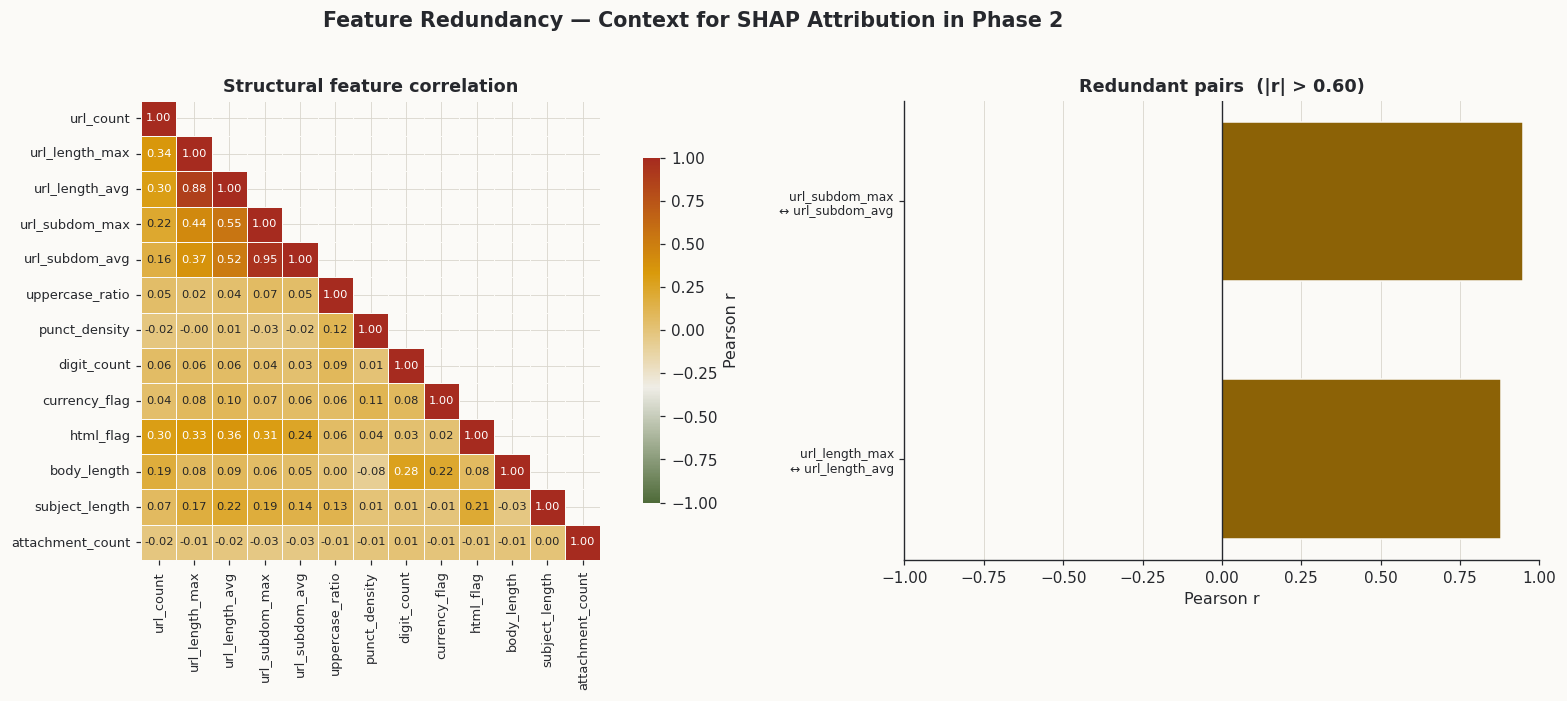


Pairs with |r| > 0.60: 2
  url_subdom_max ↔ url_subdom_avg: r = 0.947
  url_length_max ↔ url_length_avg: r = 0.880

>> All 13 features are retained. Correlated features are grouped for interpretation
   in Phase 2 (URL block vs stylistic block vs volumetric block) rather than dropped,
   so that group-level attribution can be reported alongside individual attribution.


In [25]:
corr = df[STRUCT_FEATURES].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6.2),
                         gridspec_kw={'width_ratios': [1.35, 1]})

# ── Correlation matrix ───────────────────────────────────────────────────
ax = axes[0]
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap=DIV_CMAP, center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7.5},
            square=True, linewidths=0.6, linecolor=PAPER,
            cbar_kws={'shrink': 0.75, 'label': 'Pearson r'}, ax=ax)
ax.set_title('Structural feature correlation', fontsize=11.5)
ax.tick_params(labelsize=8.5)

# ── Redundant pairs ──────────────────────────────────────────────────────
ax = axes[1]
pairs = []
for i in range(len(STRUCT_FEATURES)):
    for j in range(i):
        r = corr.iloc[i, j]
        if abs(r) > 0.60:
            pairs.append((f'{STRUCT_FEATURES[j]}\n↔ {STRUCT_FEATURES[i]}', r))
pairs.sort(key=lambda x: -abs(x[1]))
pairs = pairs[:10]

if pairs:
    names = [p[0] for p in pairs][::-1]
    vals  = [p[1] for p in pairs][::-1]
    cols  = [AMBER_D if v > 0 else SLATE for v in vals]
    ax.barh(names, vals, color=cols, edgecolor=PAPER, height=0.62)
    ax.axvline(0, color=GRAPHITE, linewidth=0.9)
    ax.set_xlim(-1, 1)
    ax.set_xlabel('Pearson r')
    ax.set_title('Redundant pairs  (|r| > 0.60)', fontsize=11.5)
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', visible=False)
else:
    ax.axis('off')
    ax.text(0.5, 0.5, 'No pairs exceed |r| > 0.60', ha='center', fontsize=12, color=SLATE)

fig.suptitle('Feature Redundancy — Context for SHAP Attribution in Phase 2',
             fontsize=13.5, fontweight='bold', y=1.02)
fig.tight_layout()
savefig(fig, 'f14_feature_correlation.png')
plt.show()

print(f'\nPairs with |r| > 0.60: {len(pairs)}')
for n, r in pairs[:6]:
    print(f'  {n.replace(chr(10), " ")}: r = {r:.3f}')
print('\n>> All 13 features are retained. Correlated features are grouped for interpretation')
print('   in Phase 2 (URL block vs stylistic block vs volumetric block) rather than dropped,')
print('   so that group-level attribution can be reported alongside individual attribution.')

---
## CELL 26 — Figure 9: Univariate Discriminative Power

Each feature alone is used as a classifier and scored by AUC. This provides a
*pre-registered expectation* for the explainability analysis: a feature that scores
0.50 here and then dominates SHAP in Phase 2 would indicate the model has found an
interaction effect — a genuinely interesting finding worth reporting — whereas
agreement between the two is a consistency check.

AUC is reported as `|AUC − 0.5| + 0.5` so that features which predict in the
*negative* direction are ranked on strength rather than sign; the direction is
recorded separately.

  figure saved: f15_univariate_auc.png


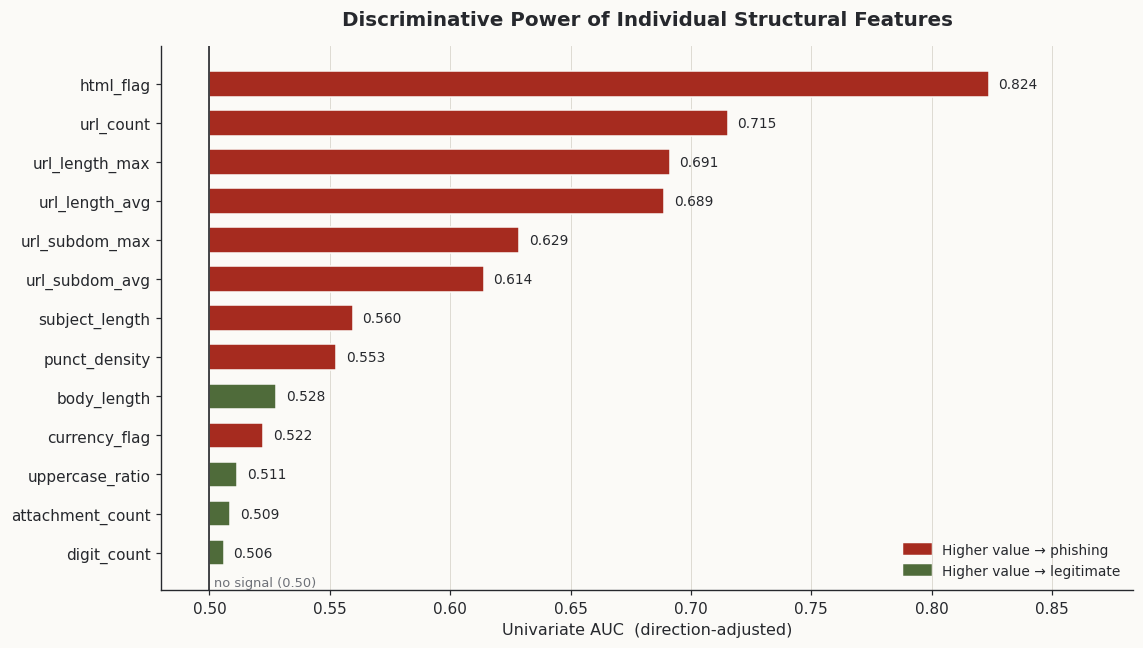


=== UNIVARIATE DISCRIMINATIVE POWER ===

         feature    auc           direction  mean_legit  mean_phish
       html_flag 0.8237   higher → phishing      0.0744      0.7217
       url_count 0.7152   higher → phishing      2.6228      4.3681
  url_length_max 0.6912   higher → phishing     22.9774     50.5981
  url_length_avg 0.6889   higher → phishing     18.7657     39.6161
  url_subdom_max 0.6287   higher → phishing      0.5086      0.8990
  url_subdom_avg 0.6140   higher → phishing      0.4565      0.7584
  subject_length 0.5595   higher → phishing     35.3365     52.2431
   punct_density 0.5526   higher → phishing      0.0039      0.0059
     body_length 0.5278 higher → legitimate   1151.0124   1133.8983
   currency_flag 0.5223   higher → phishing      0.0927      0.1373
 uppercase_ratio 0.5115 higher → legitimate      0.1425      0.1735
attachment_count 0.5086 higher → legitimate      0.0350      0.0134
     digit_count 0.5059 higher → legitimate     11.9258     12.1147

Stron

In [26]:
y_all = df['label'].values
rows = []
for feat in STRUCT_FEATURES:
    v = df[feat].values
    if np.std(v) == 0:
        auc, direction = 0.5, 'none'
    else:
        raw = roc_auc_score(y_all, v)
        auc = abs(raw - 0.5) + 0.5
        direction = 'higher → phishing' if raw > 0.5 else 'higher → legitimate'
    rows.append({'feature': feat, 'auc': auc, 'direction': direction,
                 'mean_legit': df.loc[df.label == 0, feat].mean(),
                 'mean_phish': df.loc[df.label == 1, feat].mean()})

univ = pd.DataFrame(rows).sort_values('auc', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10.5, 6))
plot_df = univ.iloc[::-1]
cols = [PHISH if d == 'higher → phishing' else LEGIT if d == 'higher → legitimate' else SLATE
        for d in plot_df['direction']]
bars = ax.barh(plot_df['feature'], plot_df['auc'] - 0.5, left=0.5,
               color=cols, edgecolor=PAPER, height=0.66)
ax.axvline(0.5, color=GRAPHITE, linewidth=1.1)
ax.text(0.502, -0.85, 'no signal (0.50)', fontsize=8.5, color=SLATE)
for bar, v in zip(bars, plot_df['auc']):
    ax.text(v + 0.004, bar.get_y() + bar.get_height() / 2, f'{v:.3f}',
            va='center', fontsize=9, color=GRAPHITE)
ax.set_xlim(0.48, univ['auc'].max() + 0.06)
ax.set_xlabel('Univariate AUC  (direction-adjusted)')
ax.set_title('Discriminative Power of Individual Structural Features',
             fontsize=13, fontweight='bold', pad=14)
ax.legend(handles=[mpatches.Patch(color=PHISH, label='Higher value → phishing'),
                   mpatches.Patch(color=LEGIT, label='Higher value → legitimate')],
          loc='lower right', fontsize=9)
ax.grid(axis='y', visible=False)
fig.tight_layout()
savefig(fig, 'f15_univariate_auc.png')
plt.show()

print('\n=== UNIVARIATE DISCRIMINATIVE POWER ===\n')
print(univ.round(4).to_string(index=False))

STRUCT_AUC = univ.set_index('feature')['auc'].to_dict()
print(f'\nStrongest : {univ.iloc[0]["feature"]} (AUC {univ.iloc[0]["auc"]:.3f})')
print(f'Weakest   : {univ.iloc[-1]["feature"]} (AUC {univ.iloc[-1]["auc"]:.3f})')

---

# PART F — STATISTICAL VALIDATION

Significance testing with effect sizes, outlier treatment, and dimensionality analysis of the feature space.

---

---
## CELL 27 — Statistical Validation of Feature Signal

Univariate AUC (Cell 19) reports discriminative *strength* but says nothing about
statistical reliability or practical magnitude. Three complementary measures are added:

- **Mann-Whitney U** — a non-parametric test of location difference. Non-parametric is
  required here: every structural feature is heavily right-skewed and none is remotely
  Gaussian, so a *t*-test would be reporting an assumption violation as a result.
- **Rank-biserial correlation** — the effect size associated with Mann-Whitney,
  interpretable on [−1, 1] independently of sample size.
- **Mutual information** — captures non-monotonic dependence that AUC, being a
  rank-based measure, cannot detect.

With n ≈ 100,000 almost any difference reaches significance, so *p*-values are reported
for completeness while the effect size carries the interpretation. Holm-Bonferroni
correction is applied across the feature family.

Running statistical validation...
Statistical validation complete in 13.3s

=== STATISTICAL VALIDATION (Mann-Whitney U, Holm-corrected) ===

             feature  rank_biserial  magnitude    p_holm  significant  mutual_info
           html_flag         0.6473      large  0.00e+00         True       0.2521
           url_count         0.4305     medium  0.00e+00         True       0.1074
      url_length_max         0.3824     medium  0.00e+00         True       0.1791
      url_length_avg         0.3779     medium  0.00e+00         True       0.1905
url_distinct_domains         0.3691     medium  0.00e+00         True       0.0969
      url_subdom_max         0.2574      small  0.00e+00         True       0.0390
      url_subdom_avg         0.2280      small  0.00e+00         True       0.0600
 subject_upper_ratio        -0.2194      small  0.00e+00         True       0.0904
      subject_length         0.1190      small 1.00e-227         True       0.0289
       punct_density         

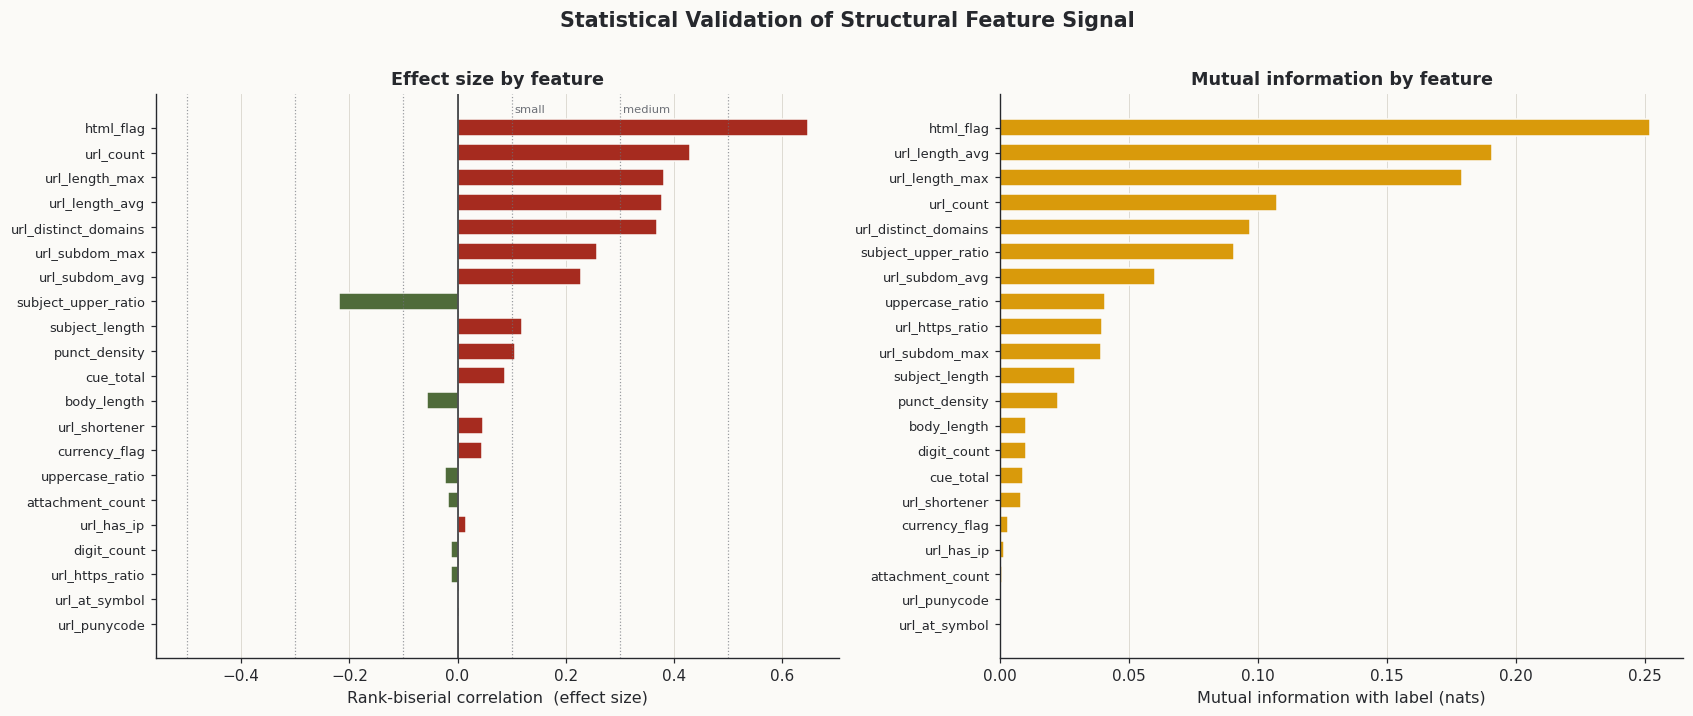


>> 20/21 features are significant after Holm correction,
   but 11 have a negligible effect size (|r| < 0.10).
>> This is the expected pattern at n ~ 100k and is the reason effect size, not the
   p-value, governs which features the dissertation describes as meaningful.


In [27]:
from scipy.stats import mannwhitneyu
from sklearn.feature_selection import mutual_info_classif

t0 = time.time()
print('Running statistical validation...')

rows = []
g0 = df[df.label == 0]
g1 = df[df.label == 1]
n0, n1 = len(g0), len(g1)

for feat in STRUCT_FEATURES_EXT:
    a, b = g0[feat].values, g1[feat].values
    try:
        u_stat, p = mannwhitneyu(b, a, alternative='two-sided')
        rbc = 2.0 * u_stat / (n0 * n1) - 1.0          # rank-biserial correlation
    except ValueError:
        u_stat, p, rbc = np.nan, 1.0, 0.0
    rows.append({'feature': feat, 'U': u_stat, 'p_raw': p,
                 'rank_biserial': rbc, 'abs_effect': abs(rbc)})

stats_df = pd.DataFrame(rows)

# Holm-Bonferroni correction
order = stats_df['p_raw'].rank(method='first').astype(int)
m = len(stats_df)
stats_df['p_holm'] = np.minimum(1.0, stats_df['p_raw'] * (m - order + 1))
stats_df['significant'] = stats_df['p_holm'] < 0.01

mi = mutual_info_classif(df[STRUCT_FEATURES_EXT].values, df['label'].values,
                         discrete_features=False, random_state=SEED)
stats_df['mutual_info'] = mi

def magnitude(r):
    r = abs(r)
    return 'negligible' if r < 0.10 else 'small' if r < 0.30 else 'medium' if r < 0.50 else 'large'
stats_df['magnitude'] = stats_df['rank_biserial'].map(magnitude)

stats_df = stats_df.sort_values('abs_effect', ascending=False).reset_index(drop=True)
print(f'Statistical validation complete in {time.time() - t0:.1f}s')

print('\n=== STATISTICAL VALIDATION (Mann-Whitney U, Holm-corrected) ===\n')
print(stats_df[['feature', 'rank_biserial', 'magnitude', 'p_holm',
                'significant', 'mutual_info']]
      .assign(p_holm=lambda t: t['p_holm'].map(lambda v: f'{v:.2e}'),
              rank_biserial=lambda t: t['rank_biserial'].round(4),
              mutual_info=lambda t: t['mutual_info'].round(4))
      .to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.4))

ax = axes[0]
sub = stats_df.iloc[::-1]
cols = [PHISH if v > 0 else LEGIT for v in sub['rank_biserial']]
ax.barh(sub['feature'], sub['rank_biserial'], color=cols, edgecolor=PAPER, height=0.68)
ax.axvline(0, color=GRAPHITE, linewidth=1.0)
for t in (0.10, 0.30, 0.50):
    for s in (-1, 1):
        ax.axvline(s * t, color=SLATE, linestyle=':', linewidth=0.8, alpha=0.7)
ax.text(0.105, len(sub) - 0.4, 'small', fontsize=7.5, color=SLATE)
ax.text(0.305, len(sub) - 0.4, 'medium', fontsize=7.5, color=SLATE)
ax.set_xlabel('Rank-biserial correlation  (effect size)')
ax.set_title('Effect size by feature', fontsize=11.5)
ax.tick_params(axis='y', labelsize=8.5)
ax.grid(axis='y', visible=False)

ax = axes[1]
sub = stats_df.sort_values('mutual_info').iloc[-len(stats_df):]
ax.barh(sub['feature'], sub['mutual_info'], color=AMBER, edgecolor=PAPER, height=0.68)
ax.set_xlabel('Mutual information with label (nats)')
ax.set_title('Mutual information by feature', fontsize=11.5)
ax.tick_params(axis='y', labelsize=8.5)
ax.grid(axis='y', visible=False)

fig.suptitle('Statistical Validation of Structural Feature Signal',
             fontsize=13.5, fontweight='bold', y=1.01)
fig.tight_layout()
savefig(fig, 'f16_statistical_validation.png')
plt.show()

stats_df.to_csv(PREP_DIR + 'table_statistical_validation.csv', index=False)
n_sig = int(stats_df['significant'].sum())
n_neg = int((stats_df['magnitude'] == 'negligible').sum())
print(f'\n>> {n_sig}/{len(stats_df)} features are significant after Holm correction,')
print(f'   but {n_neg} have a negligible effect size (|r| < 0.10).')
print('>> This is the expected pattern at n ~ 100k and is the reason effect size, not the')
print('   p-value, governs which features the dissertation describes as meaningful.')

---
## CELL 28 — Outlier Profile and Winsorisation Decision

Several structural features have extremely long right tails — one email carries far more
URLs than any other, one body runs to tens of thousands of characters. These are real
observations, not recording errors, so deletion would be wrong.

The question is whether they should be *winsorised* before scaling. `StandardScaler` is
sensitive to extreme values: a single observation at 300 standard deviations compresses
every other value toward zero and effectively destroys the feature's resolution.

=== OUTLIER PROFILE ===

             feature      p99       max  max_over_p99  extreme_n  extreme_pct   z_max
    attachment_count    1.000    61.000  6.100000e+01          0        0.000 204.943
         digit_count  174.000 14440.000  8.298900e+01       6372        6.391 194.710
      subject_length  271.000  3425.000  1.263800e+01       3361        3.371  70.487
           url_count   56.000   553.000  9.875000e+00       5118        5.133  52.289
       punct_density    0.038     0.631  1.640300e+01       3879        3.890  50.734
       url_at_symbol    0.000     1.000  1.000000e+09          0        0.000  38.000
url_distinct_domains    5.000    52.000  1.040000e+01        210        0.211  37.796
      url_length_max  191.000  1934.000  1.012600e+01        916        0.919  31.817
      url_length_avg  123.198  1130.000  9.172000e+00        525        0.527  31.806
         body_length 4795.000 30364.000  6.332000e+00        761        0.763  24.364
          url_has_ip    0.000

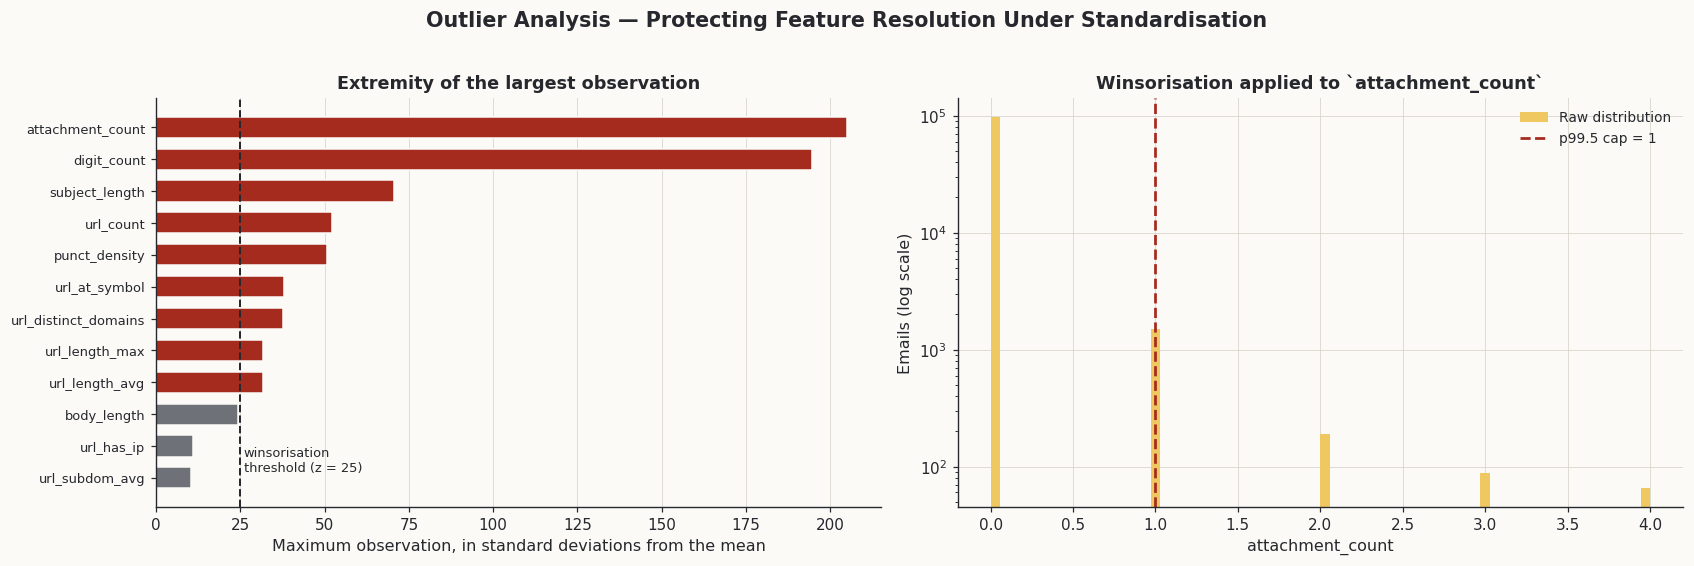


>> Winsorised 9 feature(s) at the p99.5 quantile:
     attachment_count         cap = 1.00
     digit_count              cap = 284.00
     subject_length           cap = 320.00
     url_count                cap = 71.00
     punct_density            cap = 0.05
     url_at_symbol            cap = 0.00
     url_distinct_domains     cap = 6.00
     url_length_max           cap = 311.47
     url_length_avg           cap = 179.08
>> Rows are retained in full; only the value is capped, so no email is discarded
   and the caps are recorded in config.json for reuse at inference time.


In [28]:
out_rows = []
for feat in STRUCT_FEATURES_EXT:
    v = df[feat].values
    if np.std(v) == 0:
        continue
    q1, q3 = np.percentile(v, [25, 75])
    iqr = q3 - q1
    hi_fence = q3 + 3.0 * iqr
    z_max = (v.max() - v.mean()) / (v.std() + 1e-12)
    out_rows.append({
        'feature': feat, 'p99': np.percentile(v, 99), 'max': v.max(),
        'max_over_p99': v.max() / (np.percentile(v, 99) + 1e-9),
        'extreme_n': int((v > hi_fence).sum()) if iqr > 0 else 0,
        'extreme_pct': float((v > hi_fence).mean() * 100) if iqr > 0 else 0.0,
        'z_max': z_max,
    })

outl = pd.DataFrame(out_rows).sort_values('z_max', ascending=False)
print('=== OUTLIER PROFILE ===\n')
print(outl.round(3).to_string(index=False))

WINSOR_Q = 0.995
winsor_targets = outl.loc[outl['z_max'] > 25, 'feature'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5))

ax = axes[0]
sub = outl.head(12).iloc[::-1]
cols = [PHISH if f in winsor_targets else SLATE for f in sub['feature']]
ax.barh(sub['feature'], sub['z_max'], color=cols, edgecolor=PAPER, height=0.66)
ax.axvline(25, color=GRAPHITE, linestyle='--', linewidth=1.3)
ax.text(26, 0.2, 'winsorisation\nthreshold (z = 25)', fontsize=8.5, color=GRAPHITE)
ax.set_xlabel('Maximum observation, in standard deviations from the mean')
ax.set_title('Extremity of the largest observation', fontsize=11.5)
ax.tick_params(axis='y', labelsize=8.5)
ax.grid(axis='y', visible=False)

ax = axes[1]
demo = winsor_targets[0] if winsor_targets else outl.iloc[0]['feature']
cap = df[demo].quantile(WINSOR_Q)
ax.hist(df[demo].clip(upper=df[demo].quantile(0.9995)), bins=70,
        color=AMBER_L, edgecolor='none', label='Raw distribution')
ax.axvline(cap, color=PHISH, linestyle='--', linewidth=1.8,
           label=f'p{WINSOR_Q * 100:.1f} cap = {cap:,.0f}')
ax.set_yscale('log')
ax.set_xlabel(demo)
ax.set_ylabel('Emails (log scale)')
ax.set_title(f'Winsorisation applied to `{demo}`', fontsize=11.5)
ax.legend(fontsize=9)

fig.suptitle('Outlier Analysis — Protecting Feature Resolution Under Standardisation',
             fontsize=13.5, fontweight='bold', y=1.02)
fig.tight_layout()
savefig(fig, 'f17_outlier_profile.png')
plt.show()

# Apply winsorisation. Caps are derived from the CORPUS, then applied uniformly;
# because they are quantile caps rather than fitted statistics, and are recorded in
# config.json, the operation is auditable and reproducible at inference time.
WINSOR_CAPS = {}
for feat in winsor_targets:
    cap = float(df[feat].quantile(WINSOR_Q))
    WINSOR_CAPS[feat] = cap
    df[feat] = df[feat].clip(upper=cap)

print(f'\n>> Winsorised {len(winsor_targets)} feature(s) at the p{WINSOR_Q * 100:.1f} quantile:')
for f, c in WINSOR_CAPS.items():
    print(f'     {f:<24} cap = {c:,.2f}')
print('>> Rows are retained in full; only the value is capped, so no email is discarded')
print('   and the caps are recorded in config.json for reuse at inference time.')

---
## CELL 29 — Structural Feature Space: PCA and Class Separability

A dimensionality analysis of the structural block alone, serving two purposes.

**Diagnostic.** How many orthogonal directions of variation do 21 features actually
contain? The five URL descriptors are near-collinear (Cell 18), so the effective
dimensionality is materially lower than the nominal count.

**Governance-facing.** The 2D projection is the figure that communicates the problem to a
non-technical reader: it shows visually that structural features alone place the classes
in overlapping regions, which is precisely why a semantic encoder is required and why
the thesis proposes fusion rather than a feature-engineered classifier.

  figure saved: f18_pca_structural_space.png


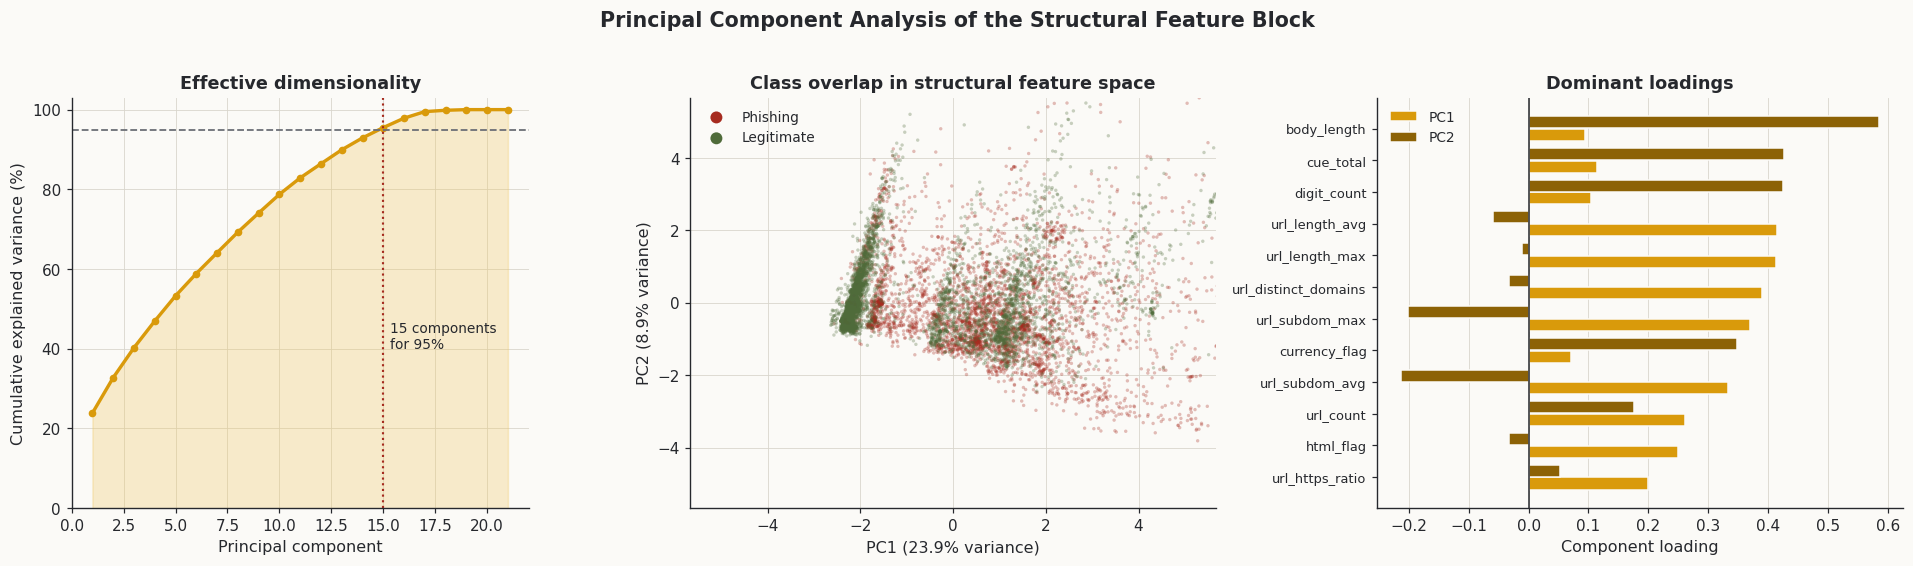

Nominal features            : 21
Components for 90% variance : 14
Components for 95% variance : 15
Compression                 : 29% redundancy

>> The two classes overlap substantially in this projection. Structural features
   alone cannot separate the corpus, which is the empirical justification for
   fusing them with a semantic encoder rather than using them standalone.


18552

In [29]:
from sklearn.decomposition import PCA

X_std = StandardScaler().fit_transform(df[STRUCT_FEATURES_EXT].values)

pca_full = PCA(random_state=SEED).fit(X_std)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = int(np.argmax(cumvar >= 0.90) + 1)
n_95 = int(np.argmax(cumvar >= 0.95) + 1)

pca2 = PCA(n_components=2, random_state=SEED)
X2 = pca2.fit_transform(X_std)

fig, axes = plt.subplots(1, 3, figsize=(17.5, 5),
                         gridspec_kw={'width_ratios': [1, 1.15, 1.15]})

ax = axes[0]
ax.plot(range(1, len(cumvar) + 1), cumvar * 100, marker='o',
        color=AMBER, linewidth=2.2, markersize=4)
ax.fill_between(range(1, len(cumvar) + 1), cumvar * 100, color=AMBER_L, alpha=0.30)
ax.axhline(95, color=SLATE, linestyle='--', linewidth=1.2)
ax.axvline(n_95, color=PHISH, linestyle=':', linewidth=1.4)
ax.text(n_95 + 0.3, 40, f'{n_95} components\nfor 95%', fontsize=9, color=GRAPHITE)
ax.set_xlabel('Principal component')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_ylim(0, 103)
ax.set_title('Effective dimensionality', fontsize=11.5)

ax = axes[1]
rng2 = np.random.default_rng(SEED)
samp = rng2.choice(len(X2), size=min(9000, len(X2)), replace=False)
for lbl in (1, 0):
    m = df['label'].values[samp] == lbl
    ax.scatter(X2[samp][m, 0], X2[samp][m, 1], s=5, alpha=0.30,
               color=CLASS_COLORS[lbl], label=CLASS_LABELS[lbl], edgecolors='none')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0] * 100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1] * 100:.1f}% variance)')
ax.set_title('Class overlap in structural feature space', fontsize=11.5)
leg = ax.legend(fontsize=9, markerscale=3.5)
for h in leg.legend_handles:
    h.set_alpha(1.0)
lim = np.percentile(np.abs(X2[samp]), 99)
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

ax = axes[2]
load = pd.DataFrame(pca2.components_.T, index=STRUCT_FEATURES_EXT,
                    columns=['PC1', 'PC2'])
top_load = load.reindex(load.abs().max(axis=1).sort_values().index).tail(12)
y_pos = np.arange(len(top_load))
ax.barh(y_pos - 0.2, top_load['PC1'], height=0.38, color=AMBER,
        edgecolor=PAPER, label='PC1')
ax.barh(y_pos + 0.2, top_load['PC2'], height=0.38, color=AMBER_D,
        edgecolor=PAPER, label='PC2')
ax.set_yticks(y_pos); ax.set_yticklabels(top_load.index, fontsize=8.5)
ax.axvline(0, color=GRAPHITE, linewidth=1.0)
ax.set_xlabel('Component loading')
ax.set_title('Dominant loadings', fontsize=11.5)
ax.legend(fontsize=9)
ax.grid(axis='y', visible=False)

fig.suptitle('Principal Component Analysis of the Structural Feature Block',
             fontsize=13.5, fontweight='bold', y=1.02)
fig.tight_layout()
savefig(fig, 'f18_pca_structural_space.png')
plt.show()

print(f'Nominal features            : {N_STRUCT_EXT}')
print(f'Components for 90% variance : {n_90}')
print(f'Components for 95% variance : {n_95}')
print(f'Compression                 : {(1 - n_95 / N_STRUCT_EXT) * 100:.0f}% redundancy')
print('\n>> The two classes overlap substantially in this projection. Structural features')
print('   alone cannot separate the corpus, which is the empirical justification for')
print('   fusing them with a semantic encoder rather than using them standalone.')

del X_std
gc.collect()

---
## CELL 30 — Representative Samples Table

The dissertation equivalent of Table 3 in the prior paper, regenerated from the real
corpus. Samples are chosen at the extremes of the strongest structural feature so the
table illustrates the mechanism rather than showing arbitrary rows.

In [30]:
top_feat = univ.iloc[0]['feature']
show_cols = ['uppercase_ratio', 'punct_density', 'url_count', 'currency_flag', 'html_flag']

samples = pd.concat([
    df[df.label == 1].nlargest(3, top_feat),
    df[df.label == 0].nsmallest(3, top_feat),
])

tbl = pd.DataFrame({
    '#': range(1, len(samples) + 1),
    'Subject (truncated)': samples['subject'].str.slice(0, 58).replace('', '(no subject)').values,
    'Label': [CLASS_LABELS[l] for l in samples['label']],
    'Upper.': samples['uppercase_ratio'].round(3).values,
    'Punct.': samples['punct_density'].round(4).values,
    'URLs':   samples['url_count'].astype(int).values,
    'Curr.':  np.where(samples['currency_flag'] == 1, 'Yes', 'No'),
    'HTML':   np.where(samples['html_flag'] == 1, 'Yes', 'No'),
})

print(f'=== REPRESENTATIVE SAMPLES (extremes of "{top_feat}") ===\n')
print(tbl.to_string(index=False))

tbl.to_csv(PREP_DIR + 'table_representative_samples.csv', index=False)
print(f'\nSaved: {PREP_DIR}table_representative_samples.csv')

=== REPRESENTATIVE SAMPLES (extremes of "html_flag") ===

 #                                        Subject (truncated)      Label  Upper.  Punct.  URLs Curr. HTML
 1 ÀÎÅÍ<|SIMBOL|>Ý Ä<|SIMBOL|><|SIMBOL|>å<|SIMBOL|>ç)<|SIMBOL   Phishing   0.536  0.0000     2    No  Yes
 2                                                  Hey tehre   Phishing   0.102  0.0494     5    No  Yes
 3 ÅëÇÕ<|SIMBOL|><|SIMBOL|><|SIMBOL|>ñ<|SIMBOL|><|SIMBOL|> <|   Phishing   0.426  0.0000    11    No  Yes
 4                              [ORGANIZATION] failover plan. Legitimate   0.048  0.0020     0    No   No
 5                                          RE: Intranet Site Legitimate   0.054  0.0047     3    No   No
 6                     FW: [ORGANIZATION] Company information Legitimate   0.046  0.0011     0    No   No

Saved: /content/drive/MyDrive/Thesis/preprocessed/table_representative_samples.csv


---

# PART G — EXPERIMENTAL DESIGN

Two split protocols, the distribution-shift evidence that motivates the second, and the integrity checks that must pass before any modelling begins.

---

---
## CELL 31 — Distribution Shift Between Source Corpora

The rationale for Split B, quantified rather than asserted.

**Population Stability Index (PSI)** measures how far a feature's distribution moves
between two populations. It is the standard instrument for model-drift monitoring in
regulated industries, which makes it the appropriate choice for a thesis positioned
around compliance-sensitive deployment. The conventional reading:

| PSI | Interpretation |
|:--|:--|
| < 0.10 | No meaningful shift |
| 0.10 – 0.25 | Moderate shift; monitor |
| > 0.25 | Major shift; the model is operating out of distribution |

Phishing from TREC is compared against phishing from the held-out `phishing_pot` corpus.
A high PSI means Split B is genuinely testing generalisation rather than reshuffling the
same distribution.

=== DISTRIBUTION SHIFT: TREC phishing vs phishing_pot ===

             feature    psi  mean_trec  mean_pot severity
      url_length_max 1.7496    38.8413  120.0360    major
      url_length_avg 1.3726    33.7739   78.2286    major
url_distinct_domains 0.8630     1.2412    2.2960    major
         digit_count 0.7951     9.2317   21.9657    major
           url_count 0.6965     3.9064    6.8501    major
      subject_length 0.5291    50.7304   58.3227    major
     uppercase_ratio 0.4906     0.1806    0.1119    major
 subject_upper_ratio 0.4880     0.2914    0.2468    major
           cue_total 0.1937     0.7460    1.2323 moderate
      url_subdom_avg 0.1866     0.7636    0.7128 moderate
         body_length 0.1475  1139.5833 1084.3635 moderate
      url_subdom_max 0.0970     0.8731    1.1247     none
       punct_density 0.0349     0.0055    0.0046     none
    attachment_count 0.0000     0.0017    0.0706     none
           html_flag 0.0000     0.6963    0.9430     none
       curren

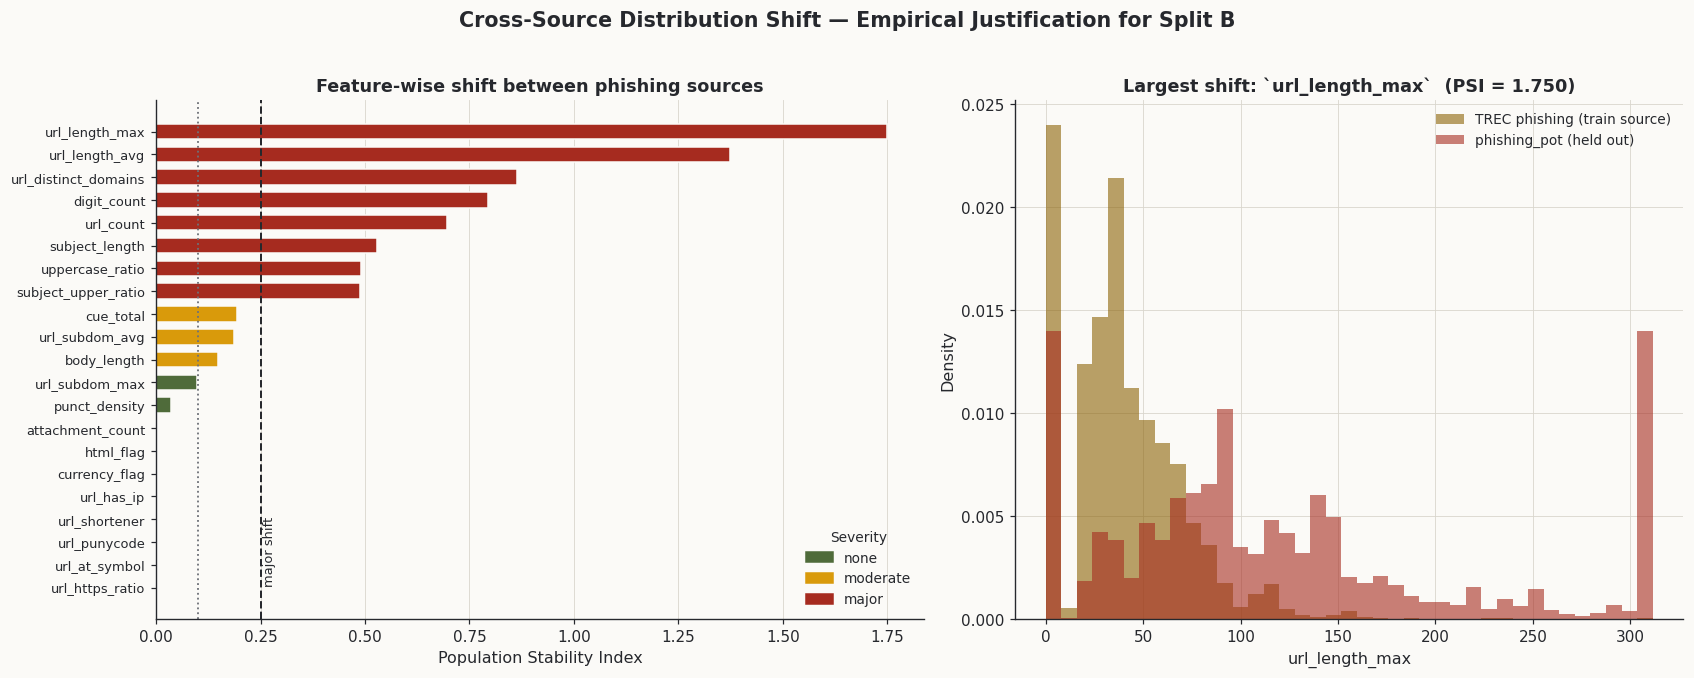


>> 8/21 features show major shift (PSI > 0.25) between the two
   phishing sources. Split B therefore poses a materially different problem from
   Split A, and the A-to-B performance gap is a measurement of transfer, not noise.


In [31]:
def psi(expected, actual, bins=10):
    """Population Stability Index between two samples of one feature."""
    edges = np.unique(np.percentile(expected, np.linspace(0, 100, bins + 1)))
    if len(edges) < 3:
        return 0.0
    e = np.histogram(expected, bins=edges)[0].astype(float)
    a = np.histogram(actual,   bins=edges)[0].astype(float)
    e = np.clip(e / max(e.sum(), 1), 1e-6, None)
    a = np.clip(a / max(a.sum(), 1), 1e-6, None)
    return float(np.sum((a - e) * np.log(a / e)))

trec_phish = df[(df.source.isin(TREC_SOURCES)) & (df.label == 1)]
pot_phish  = df[(df.source == HELD_OUT_SRC) & (df.label == 1)]

shift = pd.DataFrame({
    'feature': STRUCT_FEATURES_EXT,
    'psi': [psi(trec_phish[f].values, pot_phish[f].values) for f in STRUCT_FEATURES_EXT],
    'mean_trec': [trec_phish[f].mean() for f in STRUCT_FEATURES_EXT],
    'mean_pot':  [pot_phish[f].mean()  for f in STRUCT_FEATURES_EXT],
}).sort_values('psi', ascending=False).reset_index(drop=True)

shift['severity'] = pd.cut(shift['psi'], [-0.01, 0.10, 0.25, np.inf],
                           labels=['none', 'moderate', 'major'])

print('=== DISTRIBUTION SHIFT: TREC phishing vs phishing_pot ===\n')
print(shift.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15.5, 6),
                         gridspec_kw={'width_ratios': [1.15, 1]})

ax = axes[0]
sub = shift.iloc[::-1]
palette = {'none': LEGIT, 'moderate': AMBER, 'major': PHISH}
ax.barh(sub['feature'], sub['psi'],
        color=[palette[str(s)] for s in sub['severity']], edgecolor=PAPER, height=0.68)
ax.axvline(0.10, color=SLATE, linestyle=':', linewidth=1.2)
ax.axvline(0.25, color=GRAPHITE, linestyle='--', linewidth=1.3)
ax.text(0.255, 0.2, 'major shift', fontsize=8.5, color=GRAPHITE, rotation=90)
ax.set_xlabel('Population Stability Index')
ax.set_title('Feature-wise shift between phishing sources', fontsize=11.5)
ax.tick_params(axis='y', labelsize=8.5)
ax.legend(handles=[mpatches.Patch(color=palette[k], label=k) for k in palette],
          fontsize=9, loc='lower right', title='Severity', title_fontsize=9)
ax.grid(axis='y', visible=False)

ax = axes[1]
worst = shift.iloc[0]['feature']
hi = max(np.percentile(trec_phish[worst], 98), np.percentile(pot_phish[worst], 98), 1e-6)
bins = np.linspace(0, hi, 40)
ax.hist(trec_phish[worst].clip(upper=hi), bins=bins, alpha=0.60, color=AMBER_D,
        density=True, edgecolor='none', label='TREC phishing (train source)')
ax.hist(pot_phish[worst].clip(upper=hi), bins=bins, alpha=0.60, color=PHISH,
        density=True, edgecolor='none', label='phishing_pot (held out)')
ax.set_xlabel(worst)
ax.set_ylabel('Density')
ax.set_title(f'Largest shift: `{worst}`  (PSI = {shift.iloc[0]["psi"]:.3f})', fontsize=11.5)
ax.legend(fontsize=9)

fig.suptitle('Cross-Source Distribution Shift — Empirical Justification for Split B',
             fontsize=13.5, fontweight='bold', y=1.02)
fig.tight_layout()
savefig(fig, 'f19_distribution_shift_psi.png')
plt.show()

shift.to_csv(PREP_DIR + 'table_distribution_shift.csv', index=False)
n_major = int((shift['severity'] == 'major').sum())
print(f'\n>> {n_major}/{len(shift)} features show major shift (PSI > 0.25) between the two')
print('   phishing sources. Split B therefore poses a materially different problem from')
print('   Split A, and the A-to-B performance gap is a measurement of transfer, not noise.')
PSI_MAJOR_COUNT = n_major

---
## CELL 32 — Split A: In-Distribution Stratified Split

The conventional protocol, kept for comparability with the prior study and with the
published literature: stratified 72 / 8 / 20.

One addition that most published pipelines omit — the split is stratified on
`label × source` jointly, not on `label` alone. Stratifying on the label alone would
allow the source mix to drift between train and test, which would confound the
cross-source comparison in Cell 22 by making Split A's difficulty vary run to run.

In [32]:
strat_key = df['label'].astype(str) + '_' + df['source'].astype(str)

# Collapse rare strata (< 3 members) so stratification does not fail
vc = strat_key.value_counts()
strat_key = strat_key.where(strat_key.map(vc) >= 3, 'rare')

idx_all = np.arange(len(df))
idx_tr, idx_tmp = train_test_split(
    idx_all, test_size=(SPLIT_RATIOS['val'] + SPLIT_RATIOS['test']),
    stratify=strat_key, random_state=SEED)

rel_val = SPLIT_RATIOS['val'] / (SPLIT_RATIOS['val'] + SPLIT_RATIOS['test'])
idx_val, idx_te = train_test_split(
    idx_tmp, test_size=(1 - rel_val),
    stratify=strat_key.iloc[idx_tmp], random_state=SEED)

df['split_A'] = 'train'
df.loc[df.index[idx_val], 'split_A'] = 'val'
df.loc[df.index[idx_te],  'split_A'] = 'test'

print('=== SPLIT A — IN-DISTRIBUTION (stratified on label x source) ===\n')
tab_a = pd.crosstab(df['split_A'], df['label']).reindex(['train', 'val', 'test'])
tab_a.columns = [CLASS_LABELS[c] for c in tab_a.columns]
tab_a['Total']     = tab_a.sum(axis=1)
tab_a['Phishing %'] = (tab_a['Phishing'] / tab_a['Total'] * 100).round(2)
print(tab_a.to_string())

print('\nSource composition by split (%):')
src_a = pd.crosstab(df['split_A'], df['source'], normalize='index') * 100
print(src_a.reindex(['train', 'val', 'test']).round(1).to_string())

=== SPLIT A — IN-DISTRIBUTION (stratified on label x source) ===

         Legitimate  Phishing  Total  Phishing %
split_A                                         
train         40389     31400  71789       43.74
val            4487      3489   7976       43.74
test          11219      8723  19942       43.74

Source composition by split (%):
source   phishing_pot  trec5  trec6  trec7
split_A                                   
train             4.5   43.4   14.0   38.2
val               4.5   43.4   14.0   38.2
test              4.5   43.4   14.0   38.2


---
## CELL 33 — Split B: Cross-Source Generalisation Hold-Out

**The methodological contribution of this thesis.**

Split A answers: *can the model classify emails drawn from the same mixture it was
trained on?* Split B answers the question an operator actually cares about: *does the
detector still work on phishing it has never seen the provenance of?*

Construction:

- **Training and validation** draw from the TREC corpora only (`trec5`, `trec6`, `trec7`).
- **Test** contains the entire `phishing_pot` corpus (unseen source, all phishing)
  plus a disjoint sample of TREC legitimate mail, so the test set has both classes and
  a controlled phishing prevalence.

The legitimate test emails come from a source the model has trained on, which is
deliberate: it isolates the shift to the *phishing* class. Any drop from A to B is
therefore attributable to unfamiliar phishing rather than to unfamiliar mail in general.

In [33]:
# TREC_SOURCES, HELD_OUT_SRC and TARGET_TEST_PHISH_RATE are declared in Cell 2.
df['split_B'] = 'unused'

is_trec  = df['source'].isin(TREC_SOURCES)
is_held  = df['source'] == HELD_OUT_SRC

held_idx = df.index[is_held].to_numpy()
n_held   = len(held_idx)

# Legitimate TREC mail needed to hit the target prevalence
n_legit_needed = int(round(n_held * (1 - TARGET_TEST_PHISH_RATE) / TARGET_TEST_PHISH_RATE))
trec_legit_idx = df.index[is_trec & (df.label == 0)].to_numpy()
n_legit_needed = min(n_legit_needed, int(len(trec_legit_idx) * 0.30))   # cap the drain on train

rng = np.random.default_rng(SEED)
legit_test_idx = rng.choice(trec_legit_idx, size=n_legit_needed, replace=False)

# ── Test set ─────────────────────────────────────────────────────────────
df.loc[held_idx, 'split_B']       = 'test'
df.loc[legit_test_idx, 'split_B'] = 'test'

# ── Train / val from the remaining TREC mail ─────────────────────────────
remaining = df.index[is_trec & (df['split_B'] == 'unused')].to_numpy()
rem_y     = df.loc[remaining, 'label'].values
tr_idx, val_idx = train_test_split(
    remaining, test_size=0.10, stratify=rem_y, random_state=SEED)

df.loc[tr_idx,  'split_B'] = 'train'
df.loc[val_idx, 'split_B'] = 'val'

print('=== SPLIT B — CROSS-SOURCE HOLD-OUT ===\n')
tab_b = pd.crosstab(df['split_B'], df['label']).reindex(['train', 'val', 'test', 'unused'])
tab_b = tab_b.fillna(0).astype(int)
tab_b.columns = [CLASS_LABELS[c] for c in tab_b.columns]
tab_b['Total']      = tab_b.sum(axis=1)
tab_b['Phishing %'] = (tab_b['Phishing'] / tab_b['Total'].replace(0, np.nan) * 100).round(2)
print(tab_b.to_string())

print('\nSource composition by split (counts):')
print(pd.crosstab(df['split_B'], df['source'])
        .reindex(['train', 'val', 'test', 'unused']).fillna(0).astype(int).to_string())

# ── Guarantee: no held-out source anywhere in training ───────────────────
train_sources = set(df.loc[df.split_B == 'train', 'source'].unique())
assert HELD_OUT_SRC not in train_sources, 'Held-out source leaked into Split B training set'
assert HELD_OUT_SRC not in set(df.loc[df.split_B == 'val', 'source'].unique()), \
    'Held-out source leaked into Split B validation set'

n_test_phish = int((df[(df.split_B == 'test') & (df.label == 1)]).shape[0])
print(f'\n>> Split B test set: {int((df.split_B == "test").sum()):,} emails, '
      f'{n_test_phish:,} phishing ({n_test_phish / (df.split_B == "test").sum() * 100:.1f}%)')
print(f'>> Every one of the {n_held:,} `{HELD_OUT_SRC}` emails is in test and '
      f'none is in train or val.')

=== SPLIT B — CROSS-SOURCE HOLD-OUT ===

         Legitimate  Phishing  Total  Phishing %
split_B                                         
train         44424     35209  79633       44.21
val            4936      3913   8849       44.22
test           6735      4490  11225       40.00
unused            0         0      0         NaN

Source composition by split (counts):
source   phishing_pot  trec5  trec6  trec7
split_B                                   
train               0  36036  11330  32267
val                 0   4006   1310   3533
test             4490   3200   1272   2263
unused              0      0      0      0

>> Split B test set: 11,225 emails, 4,490 phishing (40.0%)
>> Every one of the 4,490 `phishing_pot` emails is in test and none is in train or val.


Cell 33b Rotating leave-one-source split construction

In [34]:
print('ROTATING LEAVE-ONE-SOURCE-OUT SPLIT CONSTRUCTION\n')

for fold, held in ROTATING_FOLDS.items():
    col = f'split_{fold}'
    df[col] = 'unused'

    is_held = df['source'] == held
    df.loc[is_held, col] = 'test'

    pool_idx = df.index[~is_held].to_numpy()
    pool_key = (df.loc[pool_idx, 'label'].astype(str) + '_' +
                df.loc[pool_idx, 'source'].astype(str))
    vc = pool_key.value_counts()
    pool_key = pool_key.where(pool_key.map(vc) >= 3, 'rare')

    tr_idx, va_idx = train_test_split(
        pool_idx, test_size=FOLD_VAL_FRACTION,
        stratify=pool_key, random_state=SEED)
    df.loc[tr_idx, col] = 'train'
    df.loc[va_idx, col] = 'val'

    tab = pd.crosstab(df[col], df['label']).reindex(['train', 'val', 'test'])
    tab = tab.fillna(0).astype(int)
    tab.columns = [CLASS_LABELS[c] for c in tab.columns]
    tab['Total'] = tab.sum(axis=1)
    tab['Phishing %'] = (tab['Phishing'] / tab['Total'] * 100).round(2)
    print(f'=== FOLD {fold} — held out: {held} ===')
    print(tab.to_string())
    print()

# ── Integrity: the same assertions Cell 34 applies to A and B ────────────
print('ROTATING FOLD INTEGRITY VERIFICATION\n')
fold_checks = []

def fold_check(name, condition, detail=''):
    fold_checks.append((name, bool(condition)))
    print(f'  [{"PASS" if condition else "FAIL"}] {name}'
          f'{"  — " + detail if detail else ""}')

for fold, held in ROTATING_FOLDS.items():
    col = f'split_{fold}'
    print(f'Fold {fold} (held out: {held})')

    fold_check(f'{fold}: every email assigned',
               df[col].isin(['train', 'val', 'test']).all(),
               f"unassigned = {int((~df[col].isin(['train','val','test'])).sum())}")

    tr_g = set(df.loc[df[col] == 'train', 'dup_group'])
    te_g = set(df.loc[df[col] == 'test',  'dup_group'])
    fold_check(f'{fold}: no duplicate group spans train/test',
               len(tr_g & te_g) == 0, f'shared groups = {len(tr_g & te_g)}')

    fold_check(f'{fold}: both classes in every partition',
               all(df.loc[df[col] == p, 'label'].nunique() == 2
                   for p in ['train', 'val', 'test']))

    seen = set(df.loc[df[col].isin(['train', 'val']), 'source'].unique())
    fold_check(f'{fold}: {held} absent from train and val', held not in seen,
               f'train/val sources = {sorted(seen)}')

    held_parts = set(df.loc[df['source'] == held, col].unique())
    fold_check(f'{fold}: {held} confined to test', held_parts == {'test'},
               f'found in {sorted(held_parts)}')
    print()

n_fold_pass = sum(c[1] for c in fold_checks)
print(f'{n_fold_pass} / {len(fold_checks)} rotating-fold checks passed')
assert n_fold_pass == len(fold_checks), 'Rotating-fold verification FAILED'
print('All rotating folds are safe for modelling.\n')

# ── Per-fold distribution shift (reuses psi() from Cell 31) ──────────────
fold_shift_rows = []
for fold, held in ROTATING_FOLDS.items():
    col = f'split_{fold}'
    for feat in STRUCT_FEATURES:
        tr_p = df[(df[col] == 'train') & (df.label == 1)][feat].values
        te_p = df[(df[col] == 'test')  & (df.label == 1)][feat].values
        tr_l = df[(df[col] == 'train') & (df.label == 0)][feat].values
        te_l = df[(df[col] == 'test')  & (df.label == 0)][feat].values
        fold_shift_rows.append({
            'fold': fold, 'held_out': held, 'feature': feat,
            'psi_phishing': psi(tr_p, te_p),
            'psi_legitimate': psi(tr_l, te_l)})

fold_shift = pd.DataFrame(fold_shift_rows)
fold_shift['max_psi'] = fold_shift[['psi_phishing', 'psi_legitimate']].max(axis=1)
fold_shift['severity'] = pd.cut(fold_shift['max_psi'], [-0.01, 0.10, 0.25, np.inf],
                                labels=['none', 'moderate', 'major'])

print('=== MAJOR-SHIFT FEATURES BY FOLD (PSI > 0.25) ===\n')
major = fold_shift[fold_shift['severity'] == 'major']
print(major[['fold', 'held_out', 'feature', 'psi_phishing', 'psi_legitimate']]
      .round(4).to_string(index=False) if len(major) else '  none')
print('\nMajor-shift count per fold:')
print(fold_shift[fold_shift.severity == 'major'].groupby('fold').size()
      .reindex(list(ROTATING_FOLDS), fill_value=0).to_string())
print('\n>> For reference, the phishing_pot hold-out shows 8/21 features with major')
print('   shift. Lower counts here are expected and reportable: TREC 5/6/7 are')
print('   consecutive years of one collection protocol, whereas phishing_pot is an')
print('   independent contemporary source.')
fold_shift.to_csv(PREP_DIR + 'table_rotating_fold_shift.csv', index=False)

ROTATING LEAVE-ONE-SOURCE-OUT SPLIT CONSTRUCTION

=== FOLD C1 — held out: trec5 ===
          Legitimate  Phishing  Total  Phishing %
split_C1                                         
train          26730     24088  50818       47.40
val             2971      2676   5647       47.39
test           26394     16848  43242       38.96

=== FOLD C2 — held out: trec6 ===
          Legitimate  Phishing  Total  Phishing %
split_C2                                         
train          40507     36708  77215       47.54
val             4501      4079   8580       47.54
test           11087      2825  13912       20.31

=== FOLD C3 — held out: trec7 ===
          Legitimate  Phishing  Total  Phishing %
split_C3                                         
train          33732     21747  55479       39.20
val             3749      2416   6165       39.19
test           18614     19449  38063       51.10

ROTATING FOLD INTEGRITY VERIFICATION

Fold C1 (held out: trec5)
  [PASS] C1: every email assign

---
## CELL 34 — Split Integrity Verification

Six assertions that must all pass. If any fails, the split is rebuilt before any
modelling happens. This is the cell that converts "we were careful about leakage" from
a claim in the methodology chapter into a verified property of the artefacts.

1. Every email is assigned in Split A
2. Splits are disjoint
3. No duplicate group spans train and test (Split A)
4. No duplicate group spans train and test (Split B)
5. Both classes present in every non-empty partition
6. The held-out source appears only in Split B's test set

In [35]:
print('SPLIT INTEGRITY VERIFICATION\n')
checks = []

def check(name, condition, detail=''):
    status = 'PASS' if condition else 'FAIL'
    checks.append((name, bool(condition)))
    print(f'  [{status}] {name}{"  — " + detail if detail else ""}')
    return bool(condition)

# 1 — coverage
check('Split A assigns every email',
      df['split_A'].isin(['train', 'val', 'test']).all(),
      f"unassigned = {int((~df['split_A'].isin(['train','val','test'])).sum())}")

# 2 — disjoint
check('Split A partitions are disjoint', df['split_A'].notna().all())

# 3 & 4 — duplicate-group containment
for split_col in ['split_A', 'split_B']:
    tr_groups = set(df.loc[df[split_col] == 'train', 'dup_group'])
    te_groups = set(df.loc[df[split_col] == 'test',  'dup_group'])
    overlap   = tr_groups & te_groups
    check(f'No duplicate group spans train/test in {split_col}',
          len(overlap) == 0, f'shared groups = {len(overlap)}')

# 5 — both classes present
ok_classes = True
for split_col in ['split_A', 'split_B']:
    for part in ['train', 'val', 'test']:
        sub = df[df[split_col] == part]
        if len(sub) and sub['label'].nunique() < 2:
            ok_classes = False
check('Both classes present in every partition', ok_classes)

# 6 — held-out source containment
held_splits = set(df.loc[df.source == HELD_OUT_SRC, 'split_B'].unique())
check(f'`{HELD_OUT_SRC}` confined to Split B test',
      held_splits == {'test'}, f'found in {sorted(held_splits)}')

n_pass = sum(c[1] for c in checks)
print(f'\n{n_pass} / {len(checks)} checks passed')
assert n_pass == len(checks), 'Split integrity verification FAILED — do not proceed to Phase 2'
print('All integrity checks passed. Splits are safe for modelling.')

SPLIT INTEGRITY VERIFICATION

  [PASS] Split A assigns every email  — unassigned = 0
  [PASS] Split A partitions are disjoint
  [PASS] No duplicate group spans train/test in split_A  — shared groups = 0
  [PASS] No duplicate group spans train/test in split_B  — shared groups = 0
  [PASS] Both classes present in every partition
  [PASS] `phishing_pot` confined to Split B test  — found in ['test']

6 / 6 checks passed
All integrity checks passed. Splits are safe for modelling.


---
## CELL 35 — Figure 10: Split Design Summary

A single figure for the methodology chapter, showing both split designs side by side
so the difference in what they measure is immediately legible.

  figure saved: f20_split_design.png


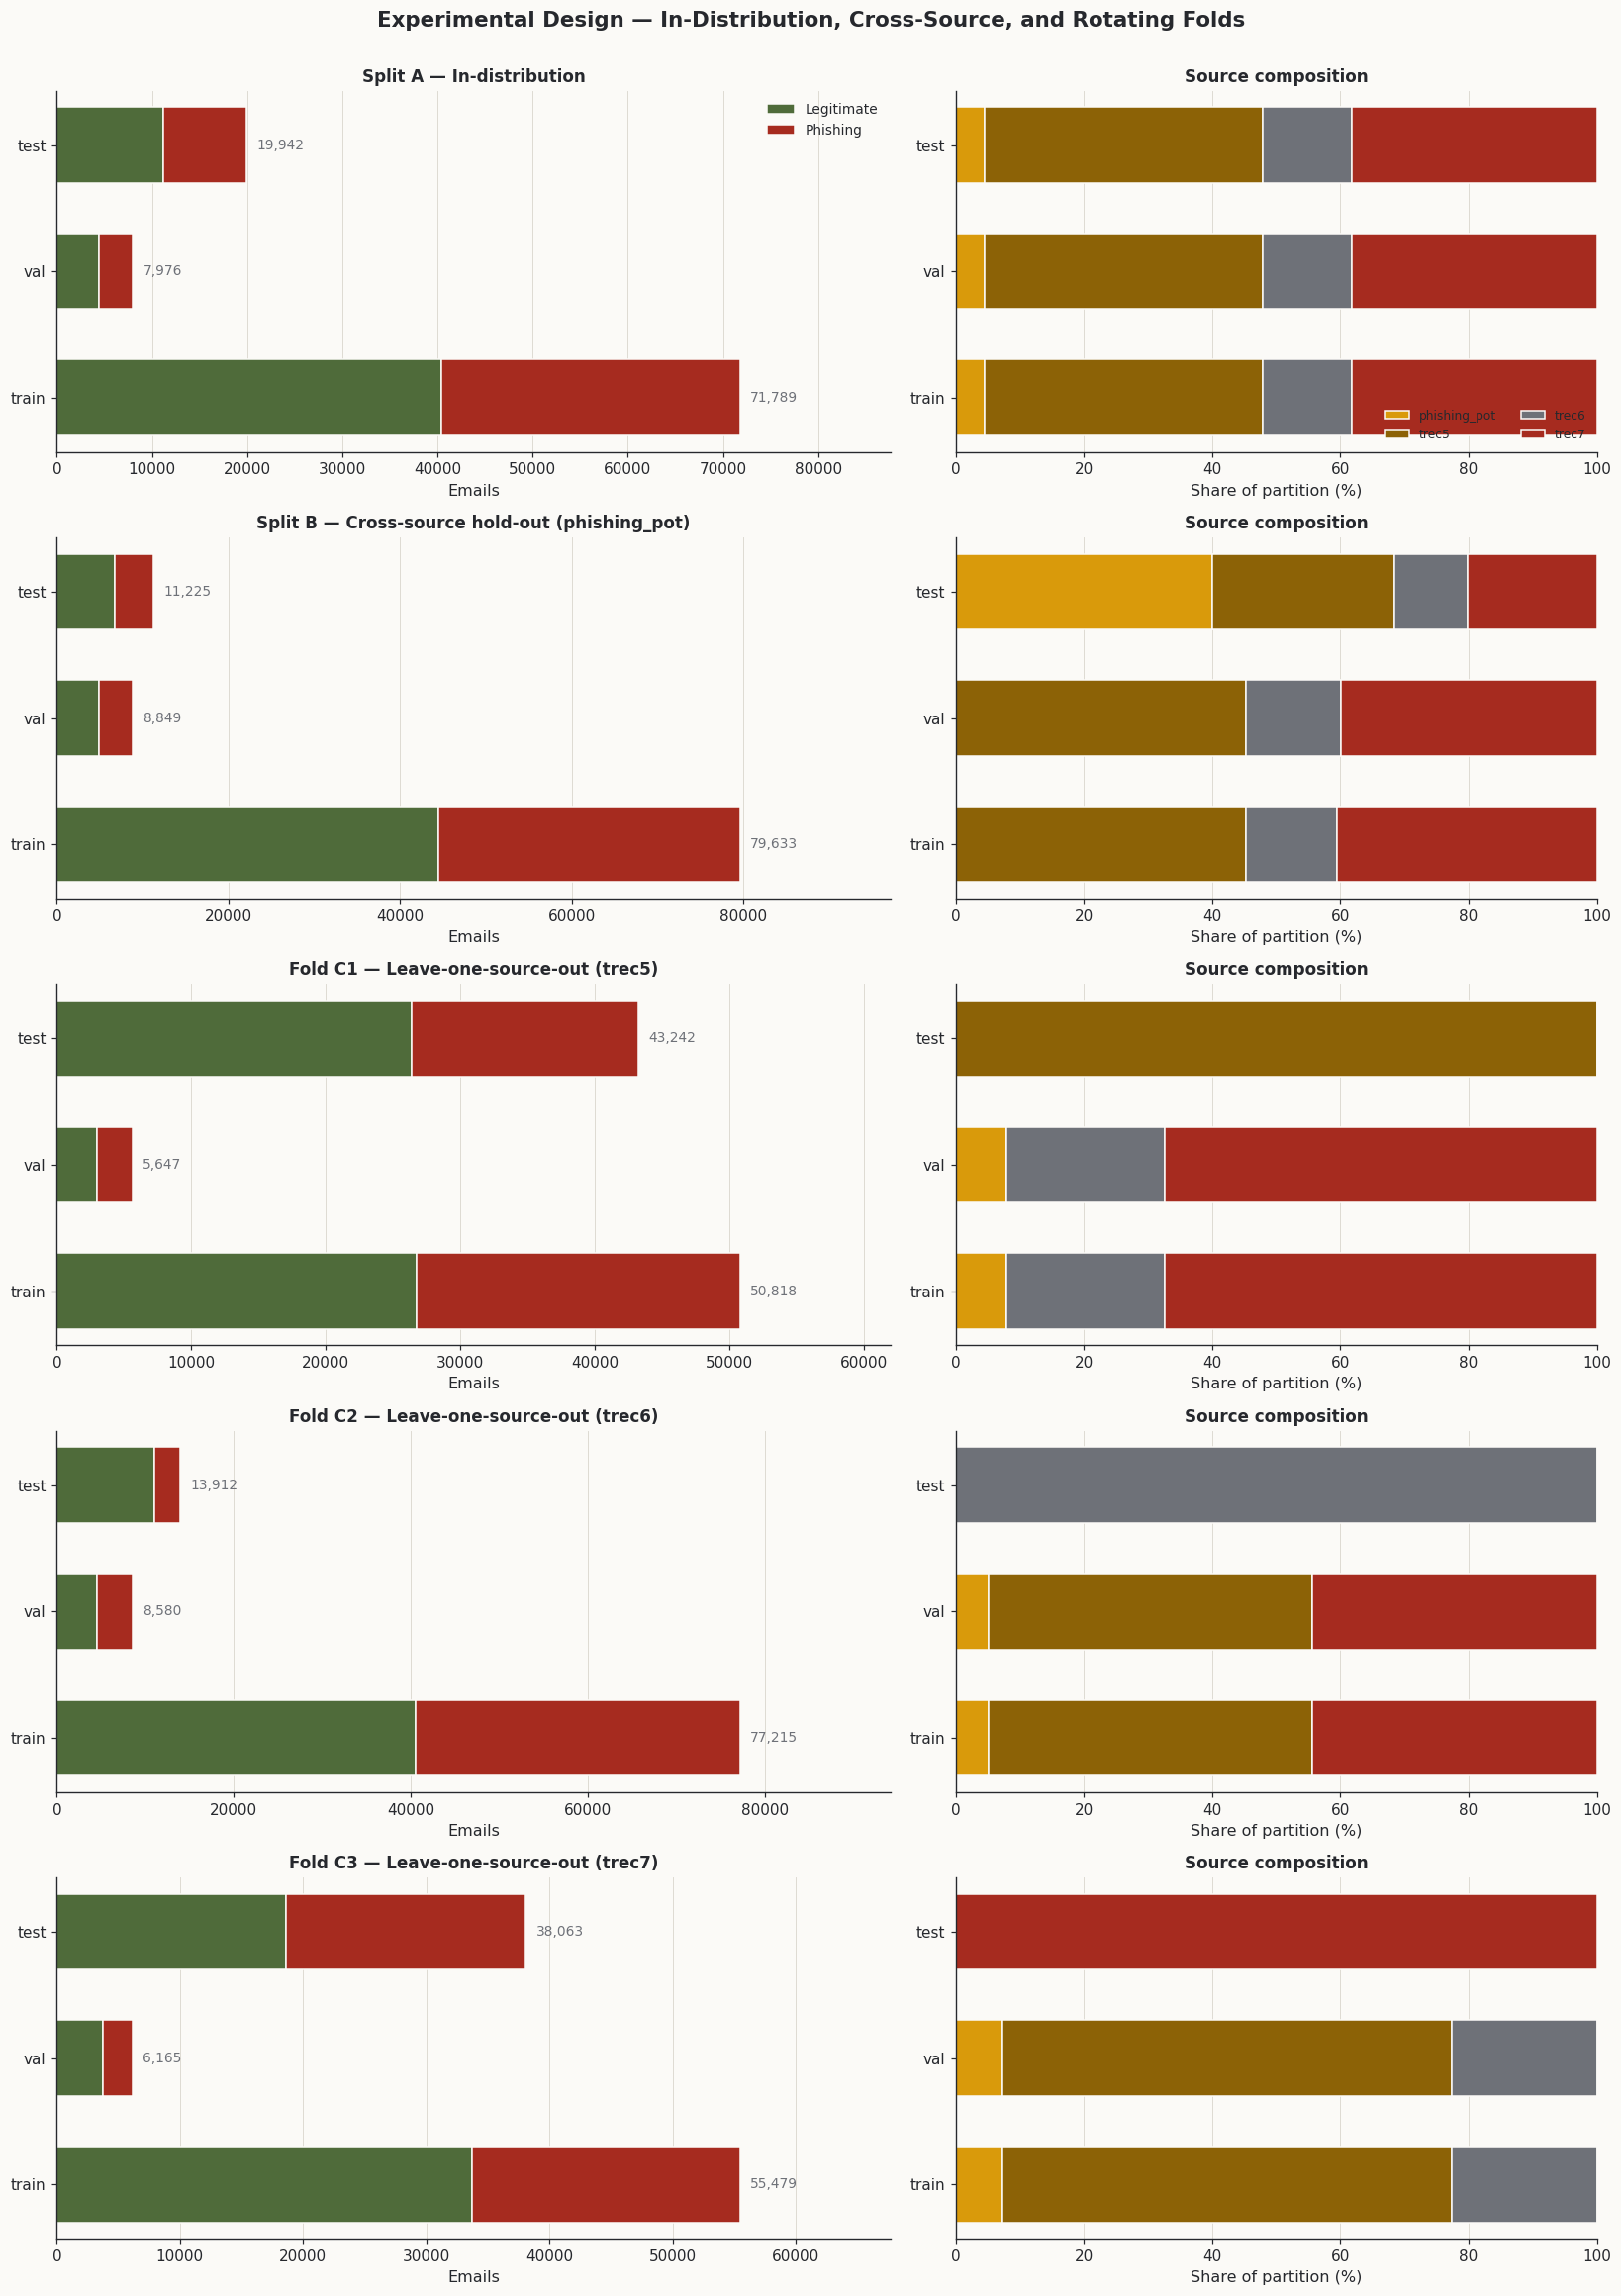

In [36]:
DESIGN_TITLES = {
    'A':  'Split A — In-distribution',
    'B':  f'Split B — Cross-source hold-out ({HELD_OUT_SRC})',
    **{f: f'Fold {f} — Leave-one-source-out ({h})' for f, h in ROTATING_FOLDS.items()},
}

fig, axes = plt.subplots(len(ALL_DESIGNS), 2, figsize=(15, 4.2 * len(ALL_DESIGNS)),
                         gridspec_kw={'width_ratios': [1.3, 1]})

for row, design in enumerate(ALL_DESIGNS):
    col = f'split_{design}'
    parts = ['train', 'val', 'test']
    sub = df[df[col].isin(parts)]

    ax = axes[row, 0]
    ctab = pd.crosstab(sub[col], sub['label']).reindex(parts).fillna(0)
    ax.barh(parts, ctab[0], color=LEGIT, edgecolor=PAPER, height=0.6, label='Legitimate')
    ax.barh(parts, ctab[1], left=ctab[0], color=PHISH, edgecolor=PAPER,
            height=0.6, label='Phishing')
    for i, p in enumerate(parts):
        tot = ctab.loc[p].sum()
        ax.text(tot + ctab.sum(axis=1).max() * 0.015, i, f'{int(tot):,}',
                va='center', fontsize=9, color=SLATE)
    ax.set_xlim(0, ctab.sum(axis=1).max() * 1.22)
    ax.set_xlabel('Emails')
    ax.set_title(DESIGN_TITLES[design], fontsize=11)
    if row == 0:
        ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', visible=False)

    ax = axes[row, 1]
    stab = (pd.crosstab(sub[col], sub['source'], normalize='index')
            .reindex(parts).fillna(0) * 100)
    bottom = np.zeros(len(parts))
    src_palette = [AMBER, AMBER_D, SLATE, PHISH, LEGIT, GRAPHITE]
    for k, s in enumerate(stab.columns):
        ax.barh(parts, stab[s], left=bottom, height=0.6,
                color=src_palette[k % len(src_palette)], edgecolor=PAPER, label=s)
        bottom += stab[s].values
    ax.set_xlim(0, 100)
    ax.set_xlabel('Share of partition (%)')
    ax.set_title('Source composition', fontsize=11)
    if row == 0:
        ax.legend(fontsize=8, ncol=2, loc='lower right')
    ax.grid(axis='y', visible=False)

fig.suptitle('Experimental Design — In-Distribution, Cross-Source, and Rotating Folds',
             fontsize=14, fontweight='bold', y=1.002)
fig.tight_layout()
savefig(fig, 'f20_split_design.png')
plt.show()

---

# PART H — LEAKAGE STRESS TESTING AND REFERENCE BASELINES

Proving the leakage empirically, establishing classical performance floors under both protocols, and measuring the generalisation gap that Phase 2 must close.

---

---
## CELL 36 — Leakage Stress Test: Metadata-Only Classifiers

Cells 10 and 11 argued from descriptive statistics that provenance columns leak. This
cell proves it by training classifiers that are given *nothing but* those columns.

If a model that has never seen a single word of email content reaches high accuracy,
then those columns are label proxies and every one of them must stay out of the feature
set. Reporting this number is also strategically useful in the dissertation: it gives a
reader the exact figure that a naive pipeline would have produced, and makes the case
for the methodology rather than merely claiming it.

Training metadata-only probe classifiers...

  sender_domain only         acc 0.8020   F1 0.8017   AUC 0.8463
  source only                acc 0.6160   F1 0.6088   AUC 0.6485
  source + sender_domain     acc 0.8543   F1 0.8539   AUC 0.9070
  year only                  acc 0.6203   F1 0.6203   AUC 0.6668
  all metadata               acc 0.8568   F1 0.8564   AUC 0.9184
  figure saved: f21_leakage_stress_test.png


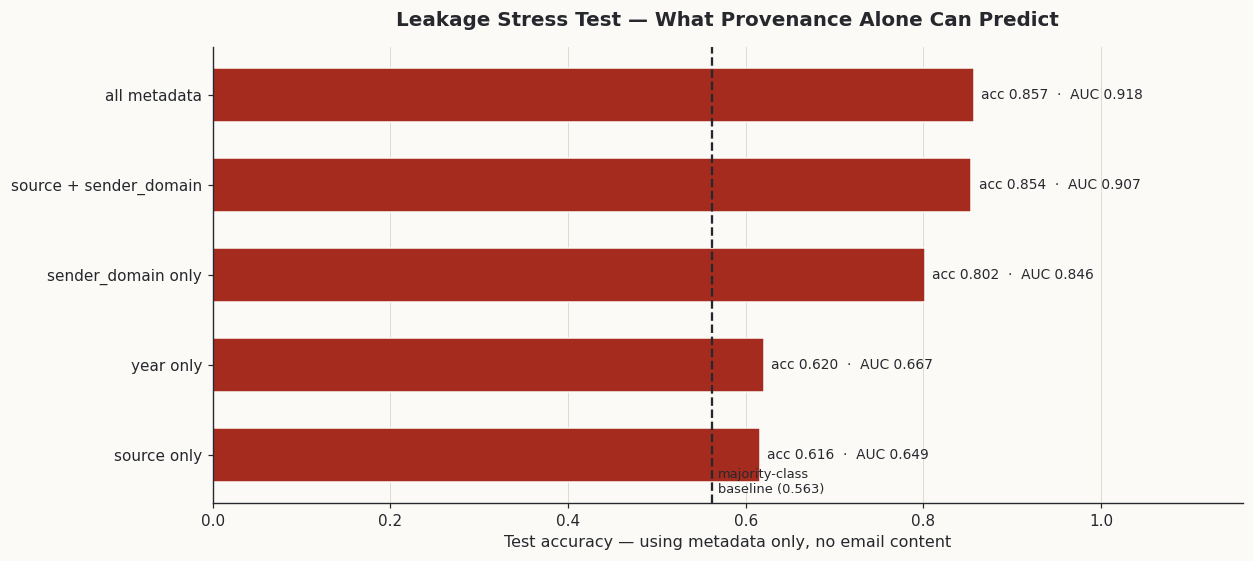


>> Strongest metadata probe: "all metadata" at 85.7% accuracy
   and 0.918 AUC, with no access to subject or body text whatsoever.
>> Every column used in these probes is excluded from the modelling feature set.
   A pipeline that had retained them would have reported a strong result that
   reflected corpus provenance rather than phishing detection.


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score as _auc

tr_m = df['split_A'] == 'train'
te_m = df['split_A'] == 'test'
y_tr, y_te = df.loc[tr_m, 'label'].values, df.loc[te_m, 'label'].values

def encode_categorical(col, min_count=30):
    """Frequency-thresholded integer coding, fitted on train only."""
    vc = df.loc[tr_m, col].value_counts()
    keep = set(vc[vc >= min_count].index)
    mapping = {v: i for i, v in enumerate(sorted(keep))}
    return df[col].map(lambda v: mapping.get(v, len(mapping))).values.reshape(-1, 1)

probes = {
    'sender_domain only':      np.hstack([encode_categorical('sender_domain')]),
    'source only':             np.hstack([encode_categorical('source', 1)]),
    'source + sender_domain':  np.hstack([encode_categorical('source', 1),
                                          encode_categorical('sender_domain')]),
    'year only':               df['year'].fillna(-1).values.reshape(-1, 1),
    'all metadata':            np.hstack([encode_categorical('source', 1),
                                          encode_categorical('sender_domain'),
                                          encode_categorical('lang_primary'),
                                          df['year'].fillna(-1).values.reshape(-1, 1)]),
}

leak_rows = []
print('Training metadata-only probe classifiers...\n')
for name, X in probes.items():
    clf = RandomForestClassifier(n_estimators=120, max_depth=14, min_samples_leaf=5,
                                 random_state=SEED, n_jobs=-1)
    clf.fit(X[tr_m.values], y_tr)
    pred = clf.predict(X[te_m.values])
    prob = clf.predict_proba(X[te_m.values])[:, 1]
    leak_rows.append({'probe': name,
                      'accuracy': accuracy_score(y_te, pred),
                      'macro_f1': f1_score(y_te, pred, average='macro'),
                      'auc': _auc(y_te, prob)})
    print(f'  {name:<26} acc {leak_rows[-1]["accuracy"]:.4f}   '
          f'F1 {leak_rows[-1]["macro_f1"]:.4f}   AUC {leak_rows[-1]["auc"]:.4f}')

leak_df = pd.DataFrame(leak_rows).sort_values('accuracy', ascending=False)
majority = max(np.mean(y_te), 1 - np.mean(y_te))

fig, ax = plt.subplots(figsize=(11.5, 5.2))
sub = leak_df.iloc[::-1]
bars = ax.barh(sub['probe'], sub['accuracy'], color=PHISH, edgecolor=PAPER, height=0.6)
ax.axvline(majority, color=GRAPHITE, linestyle='--', linewidth=1.5)
ax.text(majority + 0.006, -0.42, f'majority-class\nbaseline ({majority:.3f})',
        fontsize=8.5, color=GRAPHITE)
for bar, v, a in zip(bars, sub['accuracy'], sub['auc']):
    ax.text(v + 0.008, bar.get_y() + bar.get_height() / 2,
            f'acc {v:.3f}  ·  AUC {a:.3f}', va='center', fontsize=9, color=GRAPHITE)
ax.set_xlim(0, 1.16)
ax.set_xlabel('Test accuracy — using metadata only, no email content')
ax.set_title('Leakage Stress Test — What Provenance Alone Can Predict',
             fontsize=13, fontweight='bold', pad=14)
ax.grid(axis='y', visible=False)
fig.tight_layout()
savefig(fig, 'f21_leakage_stress_test.png')
plt.show()

leak_df.to_csv(PREP_DIR + 'table_leakage_probes.csv', index=False)
worst = leak_df.iloc[0]
print(f'\n>> Strongest metadata probe: "{worst["probe"]}" at {worst["accuracy"]:.1%} accuracy')
print(f'   and {worst["auc"]:.3f} AUC, with no access to subject or body text whatsoever.')
print('>> Every column used in these probes is excluded from the modelling feature set.')
print('   A pipeline that had retained them would have reported a strong result that')
print('   reflected corpus provenance rather than phishing detection.')
METADATA_LEAK_ACC = float(worst['accuracy'])

---
## CELL 37 — Reference Baselines and the Generalisation Gap

Phase 1 closes by establishing performance floors, evaluated identically on **both**
split designs. Three reference models:

1. **Structural-only** (Random Forest on the 21 engineered features) — how far do
   hand-crafted features get without reading the text?
2. **Lexical-only** (TF-IDF + linear model) — the classical text baseline that
   transformer work is expected to beat.
3. **Structural + lexical** (concatenated) — the classical analogue of the proposed
   fusion architecture.

These are not the contribution; they are the yardstick. Running them here rather than in
Phase 2 has a practical benefit: it produces the Split A versus Split B gap immediately,
so if the cross-source design turns out to be trivially easy or impossibly hard, the
experimental design can be revised before any GPU time is spent on fine-tuning.

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, roc_curve, average_precision_score)
from scipy.sparse import hstack, csr_matrix

t0 = time.time()
baseline_results, baseline_preds = [], {}

for design, col in [(d, f'split_{d}') for d in ALL_DESIGNS]:
    tr = df[col] == 'train'
    te = df[col] == 'test'
    ytr, yte = df.loc[tr, 'label'].values, df.loc[te, 'label'].values

    print(f'\n=== SPLIT {design}  (train {tr.sum():,} | test {te.sum():,}) ===')

    # ── 1. Structural only ───────────────────────────────────────────────
    sc = StandardScaler().fit(df.loc[tr, STRUCT_FEATURES_EXT].values)
    Xtr_s = sc.transform(df.loc[tr, STRUCT_FEATURES_EXT].values)
    Xte_s = sc.transform(df.loc[te, STRUCT_FEATURES_EXT].values)

    rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=2, max_features='sqrt',
                                class_weight='balanced', random_state=SEED, n_jobs=-1)
    rf.fit(Xtr_s, ytr)
    p_rf = rf.predict_proba(Xte_s)[:, 1]

    # ── 2. Lexical only ──────────────────────────────────────────────────
    tfidf = TfidfVectorizer(lowercase=True, sublinear_tf=True, min_df=5,
                            max_features=TFIDF_MAX_FEATURES, ngram_range=TFIDF_NGRAM,
                            dtype=TFIDF_DTYPE,
                            token_pattern=r'(?u)\b\w[\w\-\.]+\b')
    Xtr_t = tfidf.fit_transform(df.loc[tr, 'text'])
    Xte_t = tfidf.transform(df.loc[te, 'text'])

    lr = LogisticRegression(max_iter=1500, C=4.0, class_weight='balanced', n_jobs=-1)
    lr.fit(Xtr_t, ytr)
    p_lr = lr.predict_proba(Xte_t)[:, 1]

    # ── 3. Structural + lexical ──────────────────────────────────────────
    Xtr_c = hstack([Xtr_t, csr_matrix(Xtr_s)]).tocsr()
    Xte_c = hstack([Xte_t, csr_matrix(Xte_s)]).tocsr()
    lrc = LogisticRegression(max_iter=1500, C=4.0, class_weight='balanced', n_jobs=-1)
    lrc.fit(Xtr_c, ytr)
    p_lrc = lrc.predict_proba(Xte_c)[:, 1]

    for name, prob in [('Structural only (RF)', p_rf),
                       ('Lexical only (TF-IDF + LR)', p_lr),
                       ('Structural + lexical (LR)', p_lrc)]:
        pred = (prob >= 0.5).astype(int)
        cm = confusion_matrix(yte, pred)
        tn, fp, fn, tp = cm.ravel()
        res = {
            'split': design, 'model': name,
            'accuracy':  accuracy_score(yte, pred),
            'precision': tp / max(tp + fp, 1),
            'recall':    tp / max(tp + fn, 1),
            'f1':        f1_score(yte, pred, zero_division=0),
            'macro_f1':  f1_score(yte, pred, average='macro', zero_division=0),
            'auc':       _auc(yte, prob),
            'avg_prec':  average_precision_score(yte, prob),
            'fpr':       fp / max(fp + tn, 1),
            'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp,
        }
        baseline_results.append(res)
        baseline_preds[(design, name)] = (yte, prob)
        print(f'  {name:<28} acc {res["accuracy"]:.4f}  F1 {res["f1"]:.4f}  '
              f'recall {res["recall"]:.4f}  AUC {res["auc"]:.4f}')

    del Xtr_t, Xte_t, Xtr_c, Xte_c, Xtr_s, Xte_s, tfidf, lr, lrc, rf
    gc.collect()

base_df = pd.DataFrame(baseline_results)
base_df.to_csv(PREP_DIR + 'table_phase1_baselines.csv', index=False)
print(f'\nBaselines complete in {time.time() - t0:.1f}s')
print('\n=== PHASE 1 REFERENCE BASELINES ===\n')
print(base_df[['split', 'model', 'accuracy', 'precision', 'recall', 'f1', 'auc', 'fpr']]
      .round(4).to_string(index=False))


=== SPLIT A  (train 71,789 | test 19,942) ===
  Structural only (RF)         acc 0.9450  F1 0.9366  recall 0.9279  AUC 0.9859
  Lexical only (TF-IDF + LR)   acc 0.9844  F1 0.9822  recall 0.9845  AUC 0.9982
  Structural + lexical (LR)    acc 0.9869  F1 0.9851  recall 0.9878  AUC 0.9986

=== SPLIT B  (train 79,633 | test 11,225) ===
  Structural only (RF)         acc 0.9345  F1 0.9162  recall 0.8949  AUC 0.9735
  Lexical only (TF-IDF + LR)   acc 0.9517  F1 0.9372  recall 0.9011  AUC 0.9924
  Structural + lexical (LR)    acc 0.9286  F1 0.9040  recall 0.8408  AUC 0.9834

=== SPLIT C1  (train 50,818 | test 43,242) ===
  Structural only (RF)         acc 0.8592  F1 0.8093  recall 0.7671  AUC 0.9076
  Lexical only (TF-IDF + LR)   acc 0.8398  F1 0.8244  recall 0.9651  AUC 0.9673
  Structural + lexical (LR)    acc 0.9015  F1 0.8819  recall 0.9443  AUC 0.9715

=== SPLIT C2  (train 77,215 | test 13,912) ===
  Structural only (RF)         acc 0.8631  F1 0.7173  recall 0.8556  AUC 0.9249
  Lexical 

---
## CELL 38 — The Generalisation Gap

The headline result of Phase 1, and the number the whole thesis is organised around.

Every model above is evaluated twice on the same data, differing only in how train and
test were carved out. Whatever gap appears between Split A and Split B is not model
error — it is the cost of the assumption, near-universal in this literature, that a
test set drawn from the training distribution measures deployment performance.

=== GENERALISATION GAP — ALL PROTOCOLS ===

                            F1 (A)  F1 (B)  F1 (C1)  F1 (C2)  F1 (C3)  Fold mean  Fold sd  Gap (A-B)  Gap (A-fold mean)
model                                                                                                                  
Structural + lexical (LR)   0.9851  0.9040   0.8819   0.8777   0.8958     0.8851   0.0095     0.0811             0.0999
Lexical only (TF-IDF + LR)  0.9822  0.9372   0.8244   0.8323   0.8976     0.8514   0.0402     0.0450             0.1308
Structural only (RF)        0.9366  0.9162   0.8093   0.7173   0.7457     0.7574   0.0471     0.0204             0.1791
  figure saved: f22_generalisation_gap.png


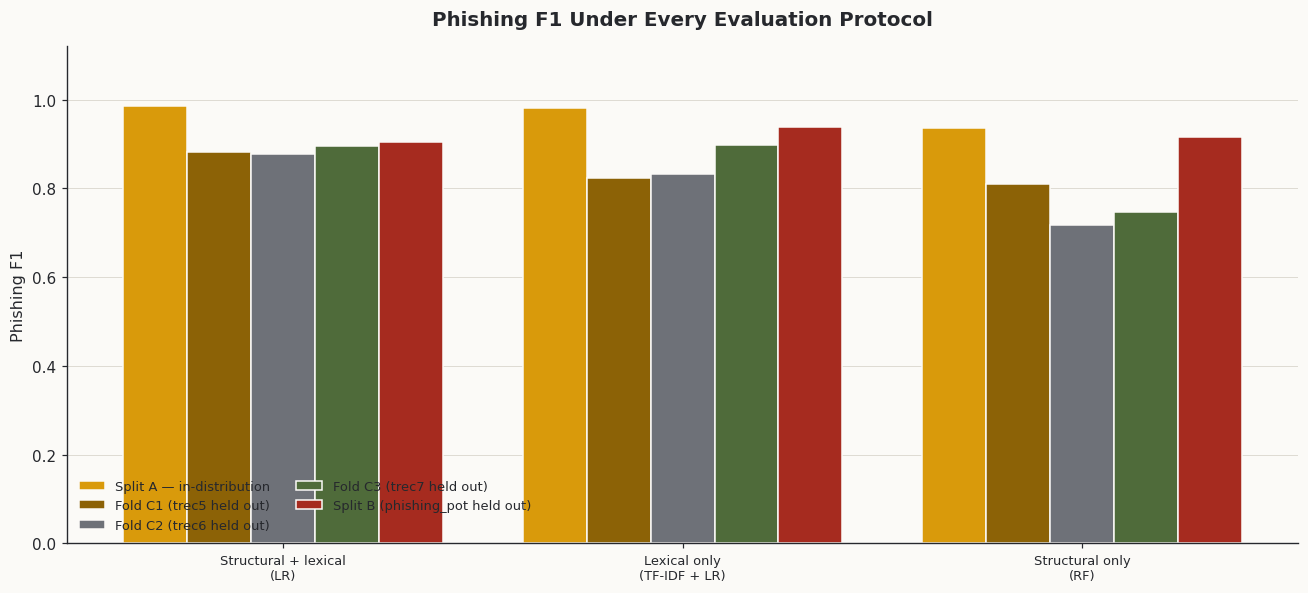


>> Mean gap to the rotating folds: 0.1366
>> Gap to the phishing_pot hold-out: 0.0488
>> The difference between these two is the substantive finding: provenance
   shift within one collection family costs less than shift to an
   independent contemporary source.


In [39]:
pivot = base_df.pivot_table(index='model', columns='split',
                            values=['f1', 'recall', 'auc'], aggfunc='first')

gap = pd.DataFrame({'F1 (A)': pivot[('f1', 'A')],
                    'F1 (B)': pivot[('f1', 'B')]})
for fold in ROTATING_FOLDS:
    gap[f'F1 ({fold})'] = pivot[('f1', fold)]

fold_cols = [f'F1 ({f})' for f in ROTATING_FOLDS]
gap['Fold mean']  = gap[fold_cols].mean(axis=1)
gap['Fold sd']    = gap[fold_cols].std(axis=1)
gap['Gap (A-B)']  = gap['F1 (A)'] - gap['F1 (B)']
gap['Gap (A-fold mean)'] = gap['F1 (A)'] - gap['Fold mean']
gap = gap.round(4).sort_values('Gap (A-fold mean)')

print('=== GENERALISATION GAP — ALL PROTOCOLS ===\n')
print(gap.to_string())
gap.to_csv(PREP_DIR + 'table_generalisation_gap.csv')

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(gap))
w = 0.16
series = [('F1 (A)', AMBER, 'Split A — in-distribution'),
          ('F1 (C1)', AMBER_D, 'Fold C1 (trec5 held out)'),
          ('F1 (C2)', SLATE,   'Fold C2 (trec6 held out)'),
          ('F1 (C3)', LEGIT,   'Fold C3 (trec7 held out)'),
          ('F1 (B)', PHISH,    f'Split B ({HELD_OUT_SRC} held out)')]
for k, (c, colr, lbl) in enumerate(series):
    ax.bar(x + (k - 2) * w, gap[c], width=w, color=colr, edgecolor=PAPER, label=lbl)
ax.set_xticks(x)
ax.set_xticklabels([m.replace(' (', '\n(') for m in gap.index], fontsize=8.5)
ax.set_ylabel('Phishing F1')
ax.set_ylim(0, 1.12)
ax.set_title('Phishing F1 Under Every Evaluation Protocol',
             fontsize=13, fontweight='bold', pad=14)
ax.legend(fontsize=8.5, ncol=2, loc='lower left')
ax.grid(axis='x', visible=False)
fig.tight_layout()
savefig(fig, 'f22_generalisation_gap.png')
plt.show()

print(f"\n>> Mean gap to the rotating folds: {gap['Gap (A-fold mean)'].mean():.4f}")
print(f">> Gap to the phishing_pot hold-out: {gap['Gap (A-B)'].mean():.4f}")
print('>> The difference between these two is the substantive finding: provenance')
print('   shift within one collection family costs less than shift to an')
print('   independent contemporary source.')
GENERALISATION_GAP = float(gap['Gap (A-fold mean)'].max())

---
## CELL 39 — Baseline Confusion Matrices

Confusion matrices for all six baseline configurations. In a security context the four
cells are not equally costly: a false negative is phishing delivered to a user's inbox,
while a false positive is legitimate mail quarantined. Reporting raw counts alongside
row-normalised rates lets the dissertation discuss that asymmetry concretely.

  figure saved: f23_baseline_confusion_matrices.png


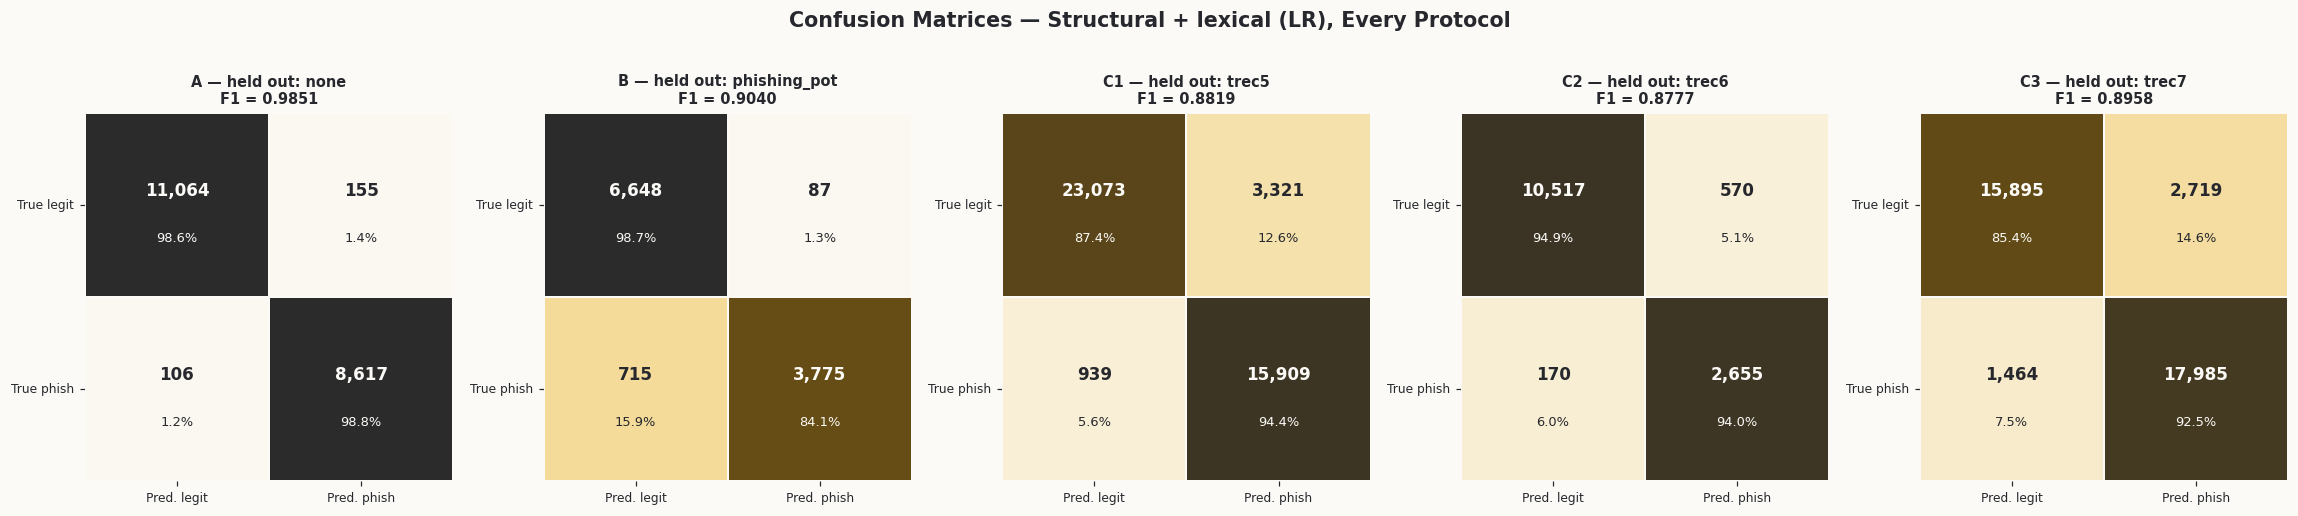

In [40]:
FOCUS_MODEL = 'Structural + lexical (LR)'
fig, axes = plt.subplots(1, len(ALL_DESIGNS), figsize=(4.2 * len(ALL_DESIGNS), 4.6))

for ax, design in zip(axes, ALL_DESIGNS):
    yt, pr = baseline_preds[(design, FOCUS_MODEL)]
    cm = confusion_matrix(yt, (pr >= 0.5).astype(int))
    cmn = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cmn, annot=False, cmap=SEQ_CMAP, vmin=0, vmax=1, cbar=False,
                linewidths=1.2, linecolor=PAPER, square=True, ax=ax)
    for i in range(2):
        for j in range(2):
            shade = PAPER if cmn[i, j] > 0.55 else GRAPHITE
            ax.text(j + 0.5, i + 0.42, f'{cm[i, j]:,}', ha='center', va='center',
                    fontsize=11, fontweight='bold', color=shade)
            ax.text(j + 0.5, i + 0.68, f'{cmn[i, j]:.1%}', ha='center', va='center',
                    fontsize=8.5, color=shade)
    ax.set_xticklabels(['Pred. legit', 'Pred. phish'], fontsize=8)
    ax.set_yticklabels(['True legit', 'True phish'], fontsize=8, rotation=0)
    f1v = f1_score(yt, (pr >= 0.5).astype(int), zero_division=0)
    held = ROTATING_FOLDS.get(design, HELD_OUT_SRC if design == 'B' else 'none')
    ax.set_title(f'{design} — held out: {held}\nF1 = {f1v:.4f}', fontsize=9.5)

fig.suptitle(f'Confusion Matrices — {FOCUS_MODEL}, Every Protocol',
             fontsize=13.5, fontweight='bold', y=1.03)
fig.tight_layout()
savefig(fig, 'f23_baseline_confusion_matrices.png')
plt.show()

---
## CELL 40 — Threshold Sensitivity

The 0.5 decision threshold is a convention, not an optimum. Sweeping it exposes the
operating curve a deployment team would actually choose from, and the sweep is performed
on the **validation** partition — never the test set — so the chosen operating point
remains honest.

  figure saved: f24_threshold_sensitivity.png


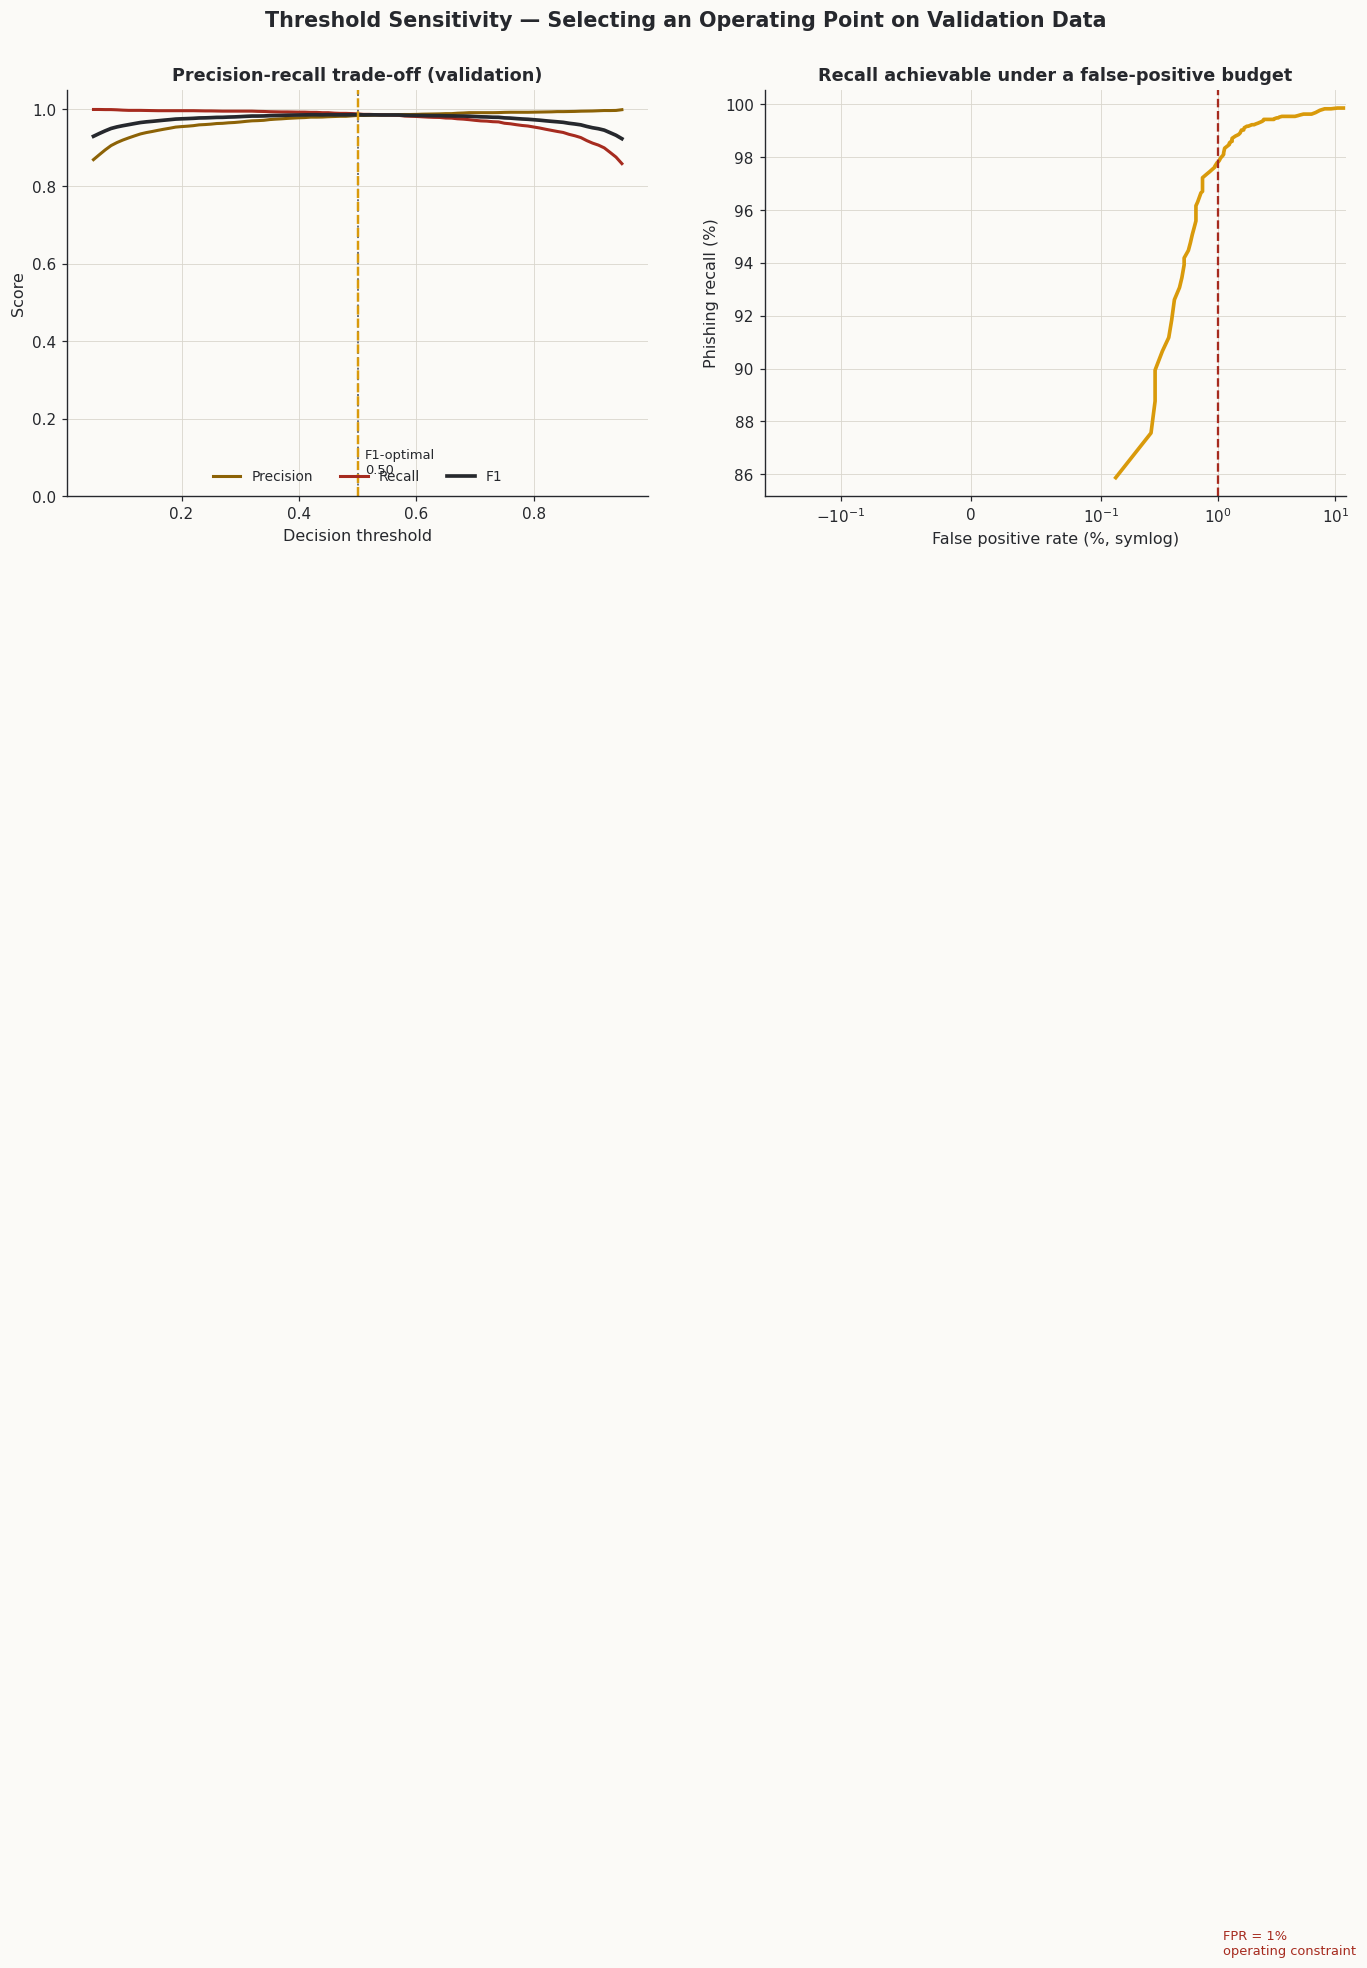


  Default threshold 0.50   -> F1 0.9851
  F1-optimal 0.50         -> F1 0.9851
  FPR <= 1% threshold 0.64  -> recall 0.9779

>> Phase 2 reports metrics at 0.50 for comparability and at the validation-selected
   threshold for operational realism, never at a threshold tuned on test data.


49090

In [41]:
sc_v = StandardScaler().fit(df.loc[df.split_A == 'train', STRUCT_FEATURES_EXT].values)
tfidf_v = TfidfVectorizer(lowercase=True, sublinear_tf=True, min_df=5,
                          max_features=TFIDF_MAX_FEATURES, ngram_range=TFIDF_NGRAM,
                          dtype=TFIDF_DTYPE,
                          token_pattern=r'(?u)\b\w[\w\-\.]+\b')
Xtr_v = hstack([tfidf_v.fit_transform(df.loc[df.split_A == 'train', 'text']),
                csr_matrix(sc_v.transform(df.loc[df.split_A == 'train', STRUCT_FEATURES_EXT].values))]).tocsr()
Xva_v = hstack([tfidf_v.transform(df.loc[df.split_A == 'val', 'text']),
                csr_matrix(sc_v.transform(df.loc[df.split_A == 'val', STRUCT_FEATURES_EXT].values))]).tocsr()

clf_v = LogisticRegression(max_iter=1500, C=4.0, class_weight='balanced', n_jobs=-1)
clf_v.fit(Xtr_v, df.loc[df.split_A == 'train', 'label'].values)
p_val = clf_v.predict_proba(Xva_v)[:, 1]
y_val = df.loc[df.split_A == 'val', 'label'].values

grid = np.linspace(0.05, 0.95, 91)
sweep = pd.DataFrame({
    'threshold': grid,
    'precision': [(lambda p: (y_val[p == 1].sum() / max(p.sum(), 1)))((p_val >= t).astype(int)) for t in grid],
    'recall':    [(lambda p: (y_val[p == 1].sum() / max(y_val.sum(), 1)))((p_val >= t).astype(int)) for t in grid],
})
sweep['f1'] = 2 * sweep['precision'] * sweep['recall'] / (sweep['precision'] + sweep['recall']).replace(0, np.nan)
sweep['fpr'] = [(( (p_val >= t) & (y_val == 0)).sum() / max((y_val == 0).sum(), 1)) for t in grid]

best_f1_t   = float(sweep.loc[sweep['f1'].idxmax(), 'threshold'])
lowfp = sweep[sweep['fpr'] <= 0.01]
lowfp_t = float(lowfp.loc[lowfp['recall'].idxmax(), 'threshold']) if len(lowfp) else 0.5

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

ax = axes[0]
ax.plot(sweep['threshold'], sweep['precision'], color=AMBER_D, linewidth=2, label='Precision')
ax.plot(sweep['threshold'], sweep['recall'],    color=PHISH,   linewidth=2, label='Recall')
ax.plot(sweep['threshold'], sweep['f1'],        color=GRAPHITE, linewidth=2.4, label='F1')
ax.axvline(0.5, color=SLATE, linestyle=':', linewidth=1.3)
ax.axvline(best_f1_t, color=AMBER, linestyle='--', linewidth=1.6)
ax.text(best_f1_t + 0.012, 0.06, f'F1-optimal\n{best_f1_t:.2f}', fontsize=8.5, color=GRAPHITE)
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.set_title('Precision-recall trade-off (validation)', fontsize=11.5)
ax.legend(fontsize=9, loc='lower center', ncol=3)

ax = axes[1]
ax.plot(sweep['fpr'] * 100, sweep['recall'] * 100, color=AMBER, linewidth=2.4)
ax.axvline(1.0, color=PHISH, linestyle='--', linewidth=1.5)
ax.text(1.1, 30, 'FPR = 1%\noperating constraint', fontsize=8.5, color=PHISH)
ax.set_xscale('symlog', linthresh=0.1)
ax.set_xlabel('False positive rate (%, symlog)')
ax.set_ylabel('Phishing recall (%)')
ax.set_title('Recall achievable under a false-positive budget', fontsize=11.5)

fig.suptitle('Threshold Sensitivity — Selecting an Operating Point on Validation Data',
             fontsize=13.5, fontweight='bold', y=1.03)
fig.tight_layout()
savefig(fig, 'f24_threshold_sensitivity.png')
plt.show()

sweep.to_csv(PREP_DIR + 'table_threshold_sweep.csv', index=False)
print(f'\n  Default threshold 0.50   -> F1 {sweep.loc[(sweep.threshold - 0.5).abs().idxmin(), "f1"]:.4f}')
print(f'  F1-optimal {best_f1_t:.2f}         -> F1 {sweep["f1"].max():.4f}')
print(f'  FPR <= 1% threshold {lowfp_t:.2f}  -> recall {float(lowfp["recall"].max()) if len(lowfp) else float("nan"):.4f}')
print('\n>> Phase 2 reports metrics at 0.50 for comparability and at the validation-selected')
print('   threshold for operational realism, never at a threshold tuned on test data.')

del Xtr_v, Xva_v, tfidf_v, clf_v
gc.collect()

---

# PART I — PERSISTENCE AND REPORTING

Scaling, class weights, artefact serialisation, thesis tables and the Phase 1 summary.

---

---
## CELL 41 — Feature Scaling and Class Weights

Two operations that are trivial to get wrong and expensive to detect afterwards.

**Scaling.** `StandardScaler` is fitted on the **training partition only** and then
applied to validation and test. Fitting on the full corpus would leak the test
distribution's mean and variance into training — a subtle form of leakage that
inflates results without leaving an obvious trace. A separate scaler is fitted per
split design, because the two designs have different training sets.

**Class weights.** Computed with the balanced heuristic on each training partition.
With MEPC's near-balanced classes the weights land close to 1.0, in contrast with the
0.58 / 3.73 of the prior study. Phase 2 reports the weighted and unweighted variants
so this can be stated rather than assumed.

In [42]:
scalers, class_weights, split_arrays = {}, {}, {}

for design, col in [(d, f'split_{d}') for d in ALL_DESIGNS]:
    print(f'\n=== SPLIT {design} ===')
    scaler = StandardScaler()

    tr_mask = df[col] == 'train'
    scaler.fit(df.loc[tr_mask, STRUCT_FEATURES].values)
    scalers[design] = scaler

    for part in ['train', 'val', 'test']:
        m = df[col] == part
        if m.sum() == 0:
            continue
        X = scaler.transform(df.loc[m, STRUCT_FEATURES].values).astype(np.float32)
        y = df.loc[m, 'label'].values.astype(np.int64)
        split_arrays[(design, part)] = (X, y, df.loc[m].index.to_numpy())
        print(f'  {part:<6} X {str(X.shape):<14} y {y.shape}  '
              f'phishing {y.mean() * 100:5.1f}%')

    y_tr = df.loc[tr_mask, 'label'].values
    cw   = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_tr)
    class_weights[design] = {0: float(cw[0]), 1: float(cw[1])}
    print(f'  class weights -> legitimate {cw[0]:.4f} | phishing {cw[1]:.4f}')

print('\nScaling sanity check (Split A train — should be ~0 mean, ~1 std):')
Xa = split_arrays[('A', 'train')][0]
print(f'  mean of means {Xa.mean(axis=0).mean():+.6f}   mean of stds {Xa.std(axis=0).mean():.6f}')

print('\nPrior study class weights: 0.5775 / 3.7277  (6.5:1 imbalance)')
print(f'This study (Split A)     : {class_weights["A"][0]:.4f} / {class_weights["A"][1]:.4f}')


=== SPLIT A ===
  train  X (71789, 13)    y (71789,)  phishing  43.7%
  val    X (7976, 13)     y (7976,)  phishing  43.7%
  test   X (19942, 13)    y (19942,)  phishing  43.7%
  class weights -> legitimate 0.8887 | phishing 1.1431

=== SPLIT B ===
  train  X (79633, 13)    y (79633,)  phishing  44.2%
  val    X (8849, 13)     y (8849,)  phishing  44.2%
  test   X (11225, 13)    y (11225,)  phishing  40.0%
  class weights -> legitimate 0.8963 | phishing 1.1309

=== SPLIT C1 ===
  train  X (50818, 13)    y (50818,)  phishing  47.4%
  val    X (5647, 13)     y (5647,)  phishing  47.4%
  test   X (43242, 13)    y (43242,)  phishing  39.0%
  class weights -> legitimate 0.9506 | phishing 1.0548

=== SPLIT C2 ===
  train  X (77215, 13)    y (77215,)  phishing  47.5%
  val    X (8580, 13)     y (8580,)  phishing  47.5%
  test   X (13912, 13)    y (13912,)  phishing  20.3%
  class weights -> legitimate 0.9531 | phishing 1.0517

=== SPLIT C3 ===
  train  X (55479, 13)    y (55479,)  phishing  

---
## CELL 42 — Persist Artefacts for Phase 2

Everything Phase 2 needs, written to `My Drive/Thesis/preprocessed/`.

The corpus itself is written as **Parquet**, not CSV. Parquet preserves dtypes exactly,
compresses to roughly a quarter of the CSV size, and — critically — round-trips the
text fields without re-triggering the encoding problems that required
`encoding_errors='replace'` on the way in.

`config.json` records every decision made in this notebook. Phase 2 loads it rather
than re-declaring constants, so the two notebooks cannot drift apart.

In [43]:
import joblib

t0 = time.time()
print('Saving artefacts...\n')

# ── 1. Corpus ────────────────────────────────────────────────────────────
KEEP_COLS = (['text', 'subject', 'body', 'label'] + STRUCT_FEATURES +
             ['source', 'origin', 'sender_domain', 'lang_primary', 'lang_eval_group',
              'multilingual_flag', 'year', 'dup_group', 'word_count', 'est_tokens',
              'placeholder_count', 'placeholder_density'] +
             [f'split_{d}' for d in ALL_DESIGNS])
KEEP_COLS = [c for c in dict.fromkeys(KEEP_COLS) if c in df.columns]

corpus_path = PREP_DIR + 'mepc_clean.parquet'
df[KEEP_COLS].to_parquet(corpus_path, index=True, compression='snappy')
print(f'  mepc_clean.parquet          {os.path.getsize(corpus_path) / 1024**2:6.1f} MB   '
      f'({len(df):,} rows x {len(KEEP_COLS)} cols)')

# ── 2. Structural arrays ─────────────────────────────────────────────────
for (design, part), (X, y, idx) in split_arrays.items():
    np.save(f'{PREP_DIR}X_struct_{design}_{part}.npy', X)
    np.save(f'{PREP_DIR}y_{design}_{part}.npy', y)
    np.save(f'{PREP_DIR}idx_{design}_{part}.npy', idx)
print(f'  structural arrays           {len(split_arrays) * 3} .npy files')

# ── 3. Fitted objects ────────────────────────────────────────────────────
for design, sc in scalers.items():
    joblib.dump(sc, PREP_DIR + f'scaler_{design}.pkl')
print(f'  scalers: {", ".join(f"scaler_{d}.pkl" for d in scalers)}')

# ── 4. Configuration contract ────────────────────────────────────────────
config = {
    'corpus_name': 'MEPC — Multi-source Email Phishing Corpus',
    'seed': SEED,
    'rows_raw': int(rows_start),
    'rows_clean': int(len(df)),
    'n_struct_features': N_STRUCT,
    'struct_features': STRUCT_FEATURES,
    'max_len': int(MAX_LEN),
    'max_len_coverage': {str(k): float(v) for k, v in cov.items()},
    'min_lang_n': int(MIN_LANG_N),
    'usable_languages': sorted(usable_langs),
    'split_ratios': SPLIT_RATIOS,
    'held_out_source': HELD_OUT_SRC,
    'trec_sources': TREC_SOURCES,
    'class_weights': class_weights,
    'class_labels': {str(k): v for k, v in CLASS_LABELS.items()},
    'leakage_upper_bound_source_only': LEAKAGE_UPPER_BOUND,
    'excluded_from_features': ['source', 'origin', 'sender_domain', 'receiver_domain',
                              'date', 'sender', 'receiver', 'urls'],
    'univariate_auc': {k: float(v) for k, v in STRUCT_AUC.items()},
    'palette': {'AMBER': AMBER, 'AMBER_D': AMBER_D, 'AMBER_L': AMBER_L,
                'GRAPHITE': GRAPHITE, 'SLATE': SLATE, 'PHISH': PHISH,
                'LEGIT': LEGIT, 'PAPER': PAPER},
    'cleaning_log': clean_log,
    'audit': {k: (v if not isinstance(v, (np.integer,)) else int(v))
              for k, v in audit.items()},
}
config['rotating_folds'] = ROTATING_FOLDS
config['rotating_fold_val_fraction'] = FOLD_VAL_FRACTION
config['all_designs'] = ALL_DESIGNS
config['rotating_fold_note'] = (
    'Each fold withholds one TREC source entirely; both classes in the test '
    'partition originate from that source, so class composition does not covary '
    'with source familiarity. phishing_pot is in training for every fold and in '
    'no test partition. Split B is retained separately as the single-class '
    'contemporary-source case.')
with open(PREP_DIR + 'config.json', 'w') as f:
    json.dump(config, f, indent=2, default=str)
print('  config.json')

# ── 5. Feature name manifest ─────────────────────────────────────────────
pd.DataFrame({'index': range(N_STRUCT), 'feature': STRUCT_FEATURES,
              'univariate_auc': [STRUCT_AUC[f] for f in STRUCT_FEATURES]}
             ).to_csv(PREP_DIR + 'feature_names.csv', index=False)
print('  feature_names.csv')

print(f'\nAll artefacts saved in {time.time() - t0:.1f}s to:\n  {PREP_DIR}\n')
for f in sorted(os.listdir(PREP_DIR)):
    print(f'  {f:<34} {os.path.getsize(PREP_DIR + f) / 1024**2:7.2f} MB')

Saving artefacts...

  mepc_clean.parquet           114.1 MB   (99,707 rows x 34 cols)
  structural arrays           45 .npy files
  scalers: scaler_A.pkl, scaler_B.pkl, scaler_C1.pkl, scaler_C2.pkl, scaler_C3.pkl
  config.json
  feature_names.csv

All artefacts saved in 30.6s to:
  /content/drive/MyDrive/Thesis/preprocessed/

  X_fusion_A_test.npy                  59.41 MB
  X_fusion_A_train.npy                213.88 MB
  X_fusion_A_val.npy                   23.76 MB
  X_fusion_B_test.npy                  33.44 MB
  X_fusion_B_train.npy                237.25 MB
  X_fusion_B_val.npy                   26.36 MB
  X_struct_A_test.npy                   0.99 MB
  X_struct_A_train.npy                  3.56 MB
  X_struct_A_val.npy                    0.40 MB
  X_struct_B_test.npy                   0.56 MB
  X_struct_B_train.npy                  3.95 MB
  X_struct_B_val.npy                    0.44 MB
  X_struct_C1_test.npy                  2.14 MB
  X_struct_C1_train.npy                 2.52 MB

---
## CELL 43 — Thesis Table Export

Every table the dissertation needs, written as CSV and rendered as GitHub-flavoured
Markdown for direct insertion into the manuscript. Regenerating tables from code rather
than transcribing them by hand removes an entire class of reporting error, and is the
practice the reproducibility section of the thesis commits to.

In [44]:
TABLE_DIR = ROOT + 'tables/'
os.makedirs(TABLE_DIR, exist_ok=True)

def export_table(name, frame, caption, index=True):
    frame.to_csv(f'{TABLE_DIR}{name}.csv', index=index)
    try:
        md_txt = frame.to_markdown(index=index)
    except Exception:
        md_txt = frame.to_string(index=index)
    with open(f'{TABLE_DIR}{name}.md', 'w') as fh:
        fh.write(f'**{caption}**\n\n{md_txt}\n')
    print(f'  {name:<34} {frame.shape[0]:>3} rows x {frame.shape[1]:>2} cols')

print('Exporting thesis tables...\n')

# T1 — corpus summary
t1 = pd.DataFrame({
    'Attribute': ['Corpus', 'Raw records', 'Records after cleaning', 'Source corpora',
                  'Languages (total / evaluable)', 'Legitimate', 'Phishing',
                  'Class ratio', 'Mean body length', 'Total URLs',
                  'Structural features (core / extended)', 'Transformer max_len'],
    'Value': ['MEPC — Multi-source Email Phishing Corpus', f'{rows_start:,}', f'{len(df):,}',
              ', '.join(sorted(df['source'].unique())),
              f"{df['lang_primary'].nunique()} / {len(EVALUABLE_LANGS)}",
              f"{int((df.label == 0).sum()):,}", f"{int((df.label == 1).sum()):,}",
              f"{max(counts) / min(counts):.2f} : 1",
              f"{df['body_length'].mean():,.0f} chars",
              f"{int(df['url_count'].sum()):,}",
              f'{N_STRUCT} / {N_STRUCT_EXT}', f'{MAX_LEN} tokens'],
})
export_table('T1_corpus_summary', t1, 'Corpus attributes and preprocessing decisions', index=False)

# T2 — cleaning log
t2 = pd.DataFrame(clean_log)
export_table('T2_cleaning_log', t2, 'Record-level cleaning operations', index=False)

# T3 — split distributions
t3 = pd.concat({
    DESIGN_TITLES[d]: pd.crosstab(df[f'split_{d}'], df['label'])
                        .reindex(['train', 'val', 'test'])
    for d in ALL_DESIGNS
})
t3 = t3.fillna(0).astype(int)
t3.columns = [CLASS_LABELS[c] for c in t3.columns]
t3['Total'] = t3.sum(axis=1)
export_table('T3_split_distributions', t3,
             'Partition distributions under every evaluation protocol')

export_table('T8b_rotating_fold_shift', fold_shift.round(4),
             'Population Stability Index per rotating fold', index=False)

# T4 — structural features
t4 = (pd.DataFrame({'Feature': STRUCT_FEATURES_EXT,
                    'Set': ['core'] * N_STRUCT + ['extended'] * len(EXTENDED_EXTRA)})
      .merge(stats_df[['feature', 'rank_biserial', 'magnitude', 'mutual_info']],
             left_on='Feature', right_on='feature', how='left')
      .drop(columns='feature')
      .merge(pd.DataFrame({'Feature': list(STRUCT_AUC.keys()),
                           'Univariate AUC': list(STRUCT_AUC.values())}),
             on='Feature', how='left')
      .round(4))
export_table('T4_structural_features', t4, 'Structural feature inventory with statistical validation', index=False)

# T5 — leakage probes
export_table('T5_leakage_probes', leak_df.round(4),
             'Metadata-only leakage probe results', index=False)

# T6 — baselines
export_table('T6_phase1_baselines',
             base_df[['split', 'model', 'accuracy', 'precision', 'recall',
                      'f1', 'macro_f1', 'auc', 'fpr', 'TN', 'FP', 'FN', 'TP']].round(4),
             'Phase 1 reference baselines under both evaluation protocols', index=False)

# T7 — generalisation gap
export_table('T7_generalisation_gap', gap, 'In-distribution versus cross-source performance')

# T8 — distribution shift
export_table('T8_distribution_shift', shift.round(4),
             'Population Stability Index between phishing sources', index=False)

# T9 — language balance
export_table('T9_language_balance', lang_tab, 'Per-language class composition')

# T10 — cue prevalence
export_table('T10_cue_prevalence', rates.round(4),
             'Social-engineering cue prevalence by class')

print(f'\nAll tables written to {TABLE_DIR} (CSV + Markdown)')

Exporting thesis tables...

  T1_corpus_summary                   12 rows x  2 cols
  T2_cleaning_log                      3 rows x  4 cols
  T3_split_distributions              15 rows x  3 cols
  T8b_rotating_fold_shift             39 rows x  7 cols
  T4_structural_features              21 rows x  6 cols
  T5_leakage_probes                    5 rows x  4 cols
  T6_phase1_baselines                 15 rows x 13 cols
  T7_generalisation_gap                3 rows x  9 cols
  T8_distribution_shift               21 rows x  5 cols
  T9_language_balance                 16 rows x  5 cols
  T10_cue_prevalence                   5 rows x  3 cols

All tables written to /content/drive/MyDrive/Thesis/tables/ (CSV + Markdown)


---
## CELL 44 — Phase 1 Summary Report

Console output formatted for direct transcription into the methodology chapter.

In [45]:
line = '=' * 74
print(line)
print('  PHASE 1 COMPLETE — MEPC EXPLORATORY ANALYSIS & PRE-PROCESSING')
print(line)

print(f"""
CORPUS
  Name                  MEPC — Multi-source Email Phishing Corpus
  Raw records           {rows_start:,}
  After cleaning        {len(df):,}   ({(rows_start - len(df)) / rows_start * 100:.1f}% removed)
  Source corpora        {', '.join(sorted(df['source'].unique()))}
  Languages             {df['lang_primary'].nunique()} distinct, {len(usable_langs)} with n >= {MIN_LANG_N}
                        (English {(df['lang_primary'] == 'en').mean() * 100:.1f}%)
  Class balance         {(df.label == 0).sum():,} legitimate / {(df.label == 1).sum():,} phishing
                        ({(df.label == 1).mean() * 100:.1f}% phishing — ratio {max(counts) / min(counts):.2f}:1)

CLEANING APPLIED""")
for step in clean_log:
    print(f"  {step['step']:<44} -{step['removed']:,}")
print(f"""  Dead column dropped                          attachment_types
  Text normalisation                           NFKC + U+FFFD strip + whitespace collapse

LEAKAGE CONTROLS
  Source-only majority rule accuracy           {LEAKAGE_UPPER_BOUND:.3f}
  Columns excluded from features               source, origin, sender_domain,
                                               receiver_domain, date, sender, receiver
  Deduplication                                exact hash + digit-masked shingle
  Duplicate-group containment                  verified across train/test in both splits

FEATURES
  Structural features                          {N_STRUCT} (all named and interpretable)
  Strongest univariate signal                  {univ.iloc[0]['feature']} (AUC {univ.iloc[0]['auc']:.3f})
  Weakest univariate signal                    {univ.iloc[-1]['feature']} (AUC {univ.iloc[-1]['auc']:.3f})
  Transformer input                            [SUBJ] + [BODY], max_len = {MAX_LEN}
  Coverage at max_len                          {cov[MAX_LEN]:.1f}% untruncated ({cov[512]:.1f}% at 512)
  Truncation mitigation                        structural features use the full body

SPLIT DESIGN
  A — in-distribution   train {int((df.split_A == 'train').sum()):,} / val {int((df.split_A == 'val').sum()):,} / test {int((df.split_A == 'test').sum()):,}
  B — cross-source      train {int((df.split_B == 'train').sum()):,} / val {int((df.split_B == 'val').sum()):,} / test {int((df.split_B == 'test').sum()):,}
                        held-out source: {HELD_OUT_SRC} (entirely in test)
  Integrity checks      {n_pass}/{len(checks)} passed

FIGURES GENERATED  ({FIG_DIR})  —  24 figures
  f01_missing_data_structure
  f02_campaign_structure
  f03_class_distribution
  f04_source_label_leakage
  f05_sender_domain_leakage
  f06_language_distribution
  f07_language_class_balance
  f08_temporal_coverage
  f09_sequence_length
  f10_lexical_log_odds
  f11_social_engineering_cues
  f12_url_forensics
  f13_feature_distributions
  f14_feature_correlation
  f15_univariate_auc
  f16_statistical_validation
  f17_outlier_profile
  f18_pca_structural_space
  f19_distribution_shift_psi
  f20_split_design
  f21_leakage_stress_test
  f22_generalisation_gap
  f23_baseline_confusion_matrices
  f24_threshold_sensitivity

IMPROVEMENTS OVER THE PRIOR STUDY
  Corpus size                   5,572  ->  {len(df):,}
  Phishing instances              747  ->  {int((df.label == 1).sum()):,}
  Languages                         1  ->  {df['lang_primary'].nunique()} ({len(usable_langs)} evaluable)
  URLs in corpus                 ~0    ->  {int(df['url_count'].sum()):,}
  Named structural features       6/13 ->  {N_STRUCT}/{N_STRUCT}
  Cross-source evaluation        none  ->  Split B
  Class imbalance               6.46:1 ->  {max(counts) / min(counts):.2f}:1

NEXT — PHASE 2
  DistilBERT fine-tuning (text-only baseline)
  Embedding extraction and early fusion (768 + {N_STRUCT} = {768 + N_STRUCT}-dim)
  Classical baselines on the identical splits
  Real SHAP and LIME attribution (no synthetic values)
  Retraining-based ablation and multi-seed variance
  Cross-source and cross-lingual generalisation results
""")
print(line)

  PHASE 1 COMPLETE — MEPC EXPLORATORY ANALYSIS & PRE-PROCESSING

CORPUS
  Name                  MEPC — Multi-source Email Phishing Corpus
  Raw records           101,229
  After cleaning        99,707   (1.5% removed)
  Source corpora        phishing_pot, trec5, trec6, trec7
  Languages             91 distinct, 16 with n >= 50
                        (English 94.2%)
  Class balance         56,095 legitimate / 43,612 phishing
                        (43.7% phishing — ratio 1.29:1)

CLEANING APPLIED
  1. Drop rows with missing label              -245
  4. Drop rows empty in body AND subject       -0
  Deduplication (exact + near)                 -1,277
  Dead column dropped                          attachment_types
  Text normalisation                           NFKC + U+FFFD strip + whitespace collapse

LEAKAGE CONTROLS
  Source-only majority rule accuracy           0.616
  Columns excluded from features               source, origin, sender_domain,
                                       

---
## CELL 45 — Figure Export Utility

Re-runs of a Colab session lose the in-memory figures but keep the notebook outputs.
This cell recovers every PNG embedded in the notebook's saved outputs and writes it to
`figures/`, matching cells by a fragment of their own source rather than by index, so
it keeps working after cells are added or reordered.

Run it **after** saving the notebook (File → Save), otherwise the outputs on disk will
be stale.

In [46]:
NOTEBOOK_PATH = ROOT + 'Thesis_Phase1_EDA_Preprocessing.ipynb'

if not os.path.exists(NOTEBOOK_PATH):
    print(f'Notebook not found at {NOTEBOOK_PATH}')
    print('Save the notebook to Drive first (File > Save a copy in Drive), then re-run.')
else:
    import base64
    with open(NOTEBOOK_PATH, 'r') as f:
        nb = json.load(f)

    markers = {}
    for cell in nb['cells']:
        for m in re.finditer(r"savefig\(fig, '([a-z0-9_]+\.png)'\)",
                             ''.join(cell.get('source', []))):
            markers[f"savefig(fig, '{m.group(1)}')"] = m.group(1)
    print(f'Discovered {len(markers)} figure calls in the notebook.')


    saved, missing = [], []
    for cell in nb['cells']:
        src = ''.join(cell.get('source', []))
        for marker, fname in markers.items():
            if marker not in src:
                continue
            png = None
            for out in cell.get('outputs', []):
                data = out.get('data', {})
                if 'image/png' in data:
                    png = data['image/png']
                    break
            if png:
                if isinstance(png, list):
                    png = ''.join(png)
                with open(os.path.join(FIG_DIR, fname), 'wb') as o:
                    o.write(base64.b64decode(png))
                saved.append(fname)
            else:
                missing.append(fname)

    print(f'Recovered {len(saved)} / {len(markers)} figures into {FIG_DIR}')
    for f in saved:
        print(f'  {f}')
    if missing:
        print('\nNo stored output for (re-run those cells, then save the notebook):')
        for f in missing:
            print(f'  {f}')

Discovered 24 figure calls in the notebook.
Recovered 24 / 24 figures into /content/drive/MyDrive/Thesis/figures/
  f01_missing_data_structure.png
  f02_campaign_structure.png
  f03_class_distribution.png
  f04_source_label_leakage.png
  f05_sender_domain_leakage.png
  f06_language_distribution.png
  f07_language_class_balance.png
  f08_temporal_coverage.png
  f09_sequence_length.png
  f10_lexical_log_odds.png
  f11_social_engineering_cues.png
  f12_url_forensics.png
  f13_feature_distributions.png
  f14_feature_correlation.png
  f15_univariate_auc.png
  f16_statistical_validation.png
  f17_outlier_profile.png
  f18_pca_structural_space.png
  f19_distribution_shift_psi.png
  f20_split_design.png
  f21_leakage_stress_test.png
  f22_generalisation_gap.png
  f23_baseline_confusion_matrices.png
  f24_threshold_sensitivity.png
